# Pipeline de Análise — DeepLabCut vs. TopScan
**Versão reorganizada com fluxo linear, QC antecipado, persistência de ROIs e exportação centralizada de figuras**

Este notebook mantém a lógica funcional do pipeline original, mas reorganiza a execução para evitar que processamento, estatística, figuras e vídeos fiquem misturados.

## Fluxo recomendado

1. **Bloco 1 — Carregamento e sincronização em centímetros**  
   Detecta arquivos, converte/sincroniza TopScan e DeepLabCut, aplica filtros e gera uma tabela de controle de qualidade logo no início.

2. **Bloco 2 — ROIs e classificação comportamental frame a frame**  
   Carrega ROIs salvas em `.json` ou usa o dicionário interno como fallback. Depois classifica Familiar/Novo/Chão e calcula tempos de exploração.

3. **Bloco 3 — Estatística e tabelas**  
   Concentra RMSE, MAE, Fréchet, DTW, Pearson, correlação cruzada, lag, Shapiro-Wilk, teste pareado/Wilcoxon quando aplicável, ANOVA por estado/zona e Bland-Altman.

4. **Bloco 4 — Figuras do artigo**  
   As figuras são registradas no dicionário `FIGURAS_ARTIGO` e exportadas juntas em `.svg`, `.pdf` e `.png`.

5. **Bloco 5 — Vídeos anotados**  
   A exportação de vídeos fica isolada no final, pois é a etapa mais demorada.

## Aviso metodológico

A validação não depende de uma única métrica. O objetivo é verificar se o DeepLabCut reproduz o TopScan em três níveis: posição, dinâmica temporal e conclusão cognitiva da TRON. Por isso, as métricas de erro espacial (RMSE/MAE), similaridade de curva (Fréchet/DTW/Pearson), sincronia temporal (cross-correlação/lag) e desfecho comportamental (Índice de Discriminação e Bland-Altman) são complementares.

# Bloco 0 — Conexão ao Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


## Imports e dependências

In [ ]:
# Instalação de bibliotecas ausentes
!pip install pingouin similaritymeasures -q

import os
import json
import re
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
import ipywidgets as widgets
import unicodedata
from IPython.display import display, clear_output, SVG

# Estatística e Análise de Dados
import pingouin as pg
import similaritymeasures
from scipy.signal import correlate, savgol_filter
from scipy.signal.windows import hann
from scipy.stats import ks_2samp, pearsonr, shapiro, ttest_rel
from scipy.stats import pearsonr

# Machine Learning e Processamento
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 1.4 MB/s eta 0:00:00


## Configurações gerais

In [ ]:
# --- Diretórios ---
DIRETORIO_TOPSCAN_TXT    = '/content/drive/MyDrive/DLC_VS_TOPSCAN_2026/TOPSCAN/TXT_NOVO/'
DIRETORIO_DLC_TXT        = '/content/drive/MyDrive/DLC_VS_TOPSCAN_2026/DLC/TXT/'
DIRETORIO_VIDEOS         = '/content/drive/MyDrive/DLC_VS_TOPSCAN_2026/VIDEOS/'
DIRETORIO_OUTPUT_VIDEOS  = '/content/drive/MyDrive/DLC_VS_TOPSCAN_2026/RESULTADOS/VIDEOS/'
DIRETORIO_OUTPUT_DADOS    = '/content/drive/MyDrive/DLC_VS_TOPSCAN_2026/RESULTADOS/EXPORTACAO_CSV/'
DIRETORIO_ROIS           = '/content/drive/MyDrive/DLC_VS_TOPSCAN_2026/RESULTADOS/ROIS/'
CAMINHO_ROI_TEMPLATES_JSON = os.path.join(DIRETORIO_ROIS, 'roi_templates_dinamico.json')

# Execução opcional
EXECUTAR_CALIBRACAO_MANUAL = False  # True apenas quando quiser abrir o widget de calibração
VERIFICAR_ROIS_VISUALMENTE = True
GERAR_VIDEOS_ANOTADOS = False       # deixe True somente no Bloco 5, pois é demorado


FPS_VIDEO        = 30
ARENA_LARGURA_CM = 60.0
ARENA_ALTURA_CM  = 60.0

# Parâmetros de análise e filtragem
PARAMS_SUAVIZACAO      = {'window_length': 11, 'polyorder': 3}
PARAMS_FILTRO_DBSCAN   = {'eps': 0.2, 'min_samples': 10}
LIMITE_SALTO_DISTANCIA = 100.0
IGNORAR_FRAMES_INICIAIS = 150
BODYPART_REFERENCIA = 'body'   # usado para trajetória, erro, mapas, RMSE, MAE, Fréchet, DTW
BODYPART_LEGENDA    = 'nose'   # usado para classificar exploração nas ROIs
BODYPARTS_ANALISE   = ['body', 'nose']
RATOS_MODO_CONSERVADOR  = {'PP', 'II'} #Utilize para ratos que possuem trajetória pobre e não estão plotando corretamente
NORMALIZAR_VISUAL_60X60 = True

# Geração de vídeo
SISTEMAS_PARA_GERAR_VIDEO = ['topscan', 'dlc']  # quais sistemas geram vídeo anotado
RATOS_PARA_GERAR_VIDEO    = ['AA']                  # [] = todos os ratos comuns

# Nomes das áreas no arquivo TopScan (coluna 'Areas') usados para classificar exploração
NOMES_OBJETOS_FAMILIARES = ['Familiar', 'familiar', 'FAM', 'fam', 'F']
NOMES_OBJETOS_NOVOS      = ['Novo', 'novo', 'NOV', 'nov', 'N', 'New', 'new']

# Mapeamento de área TopScan para label no vídeo (ajuste conforme seus dados)
TOPSCAN_AREA_MAP_VIDEO = {
    'Familiar': 'objeto_Familiar', 'familiar': 'objeto_Familiar',
    'FAM': 'objeto_Familiar', 'fam': 'objeto_Familiar', 'F': 'objeto_Familiar',
    'Novo': 'objeto_Novo', 'novo': 'objeto_Novo',
    'NOV': 'objeto_Novo', 'nov': 'objeto_Novo', 'N': 'objeto_Novo',
}

def _normalizar_texto_token(txt):
    if txt is None or (isinstance(txt, float) and np.isnan(txt)):
        return ""
    s = str(txt).strip().lower()
    s = unicodedata.normalize('NFKD', s)
    s = ''.join(ch for ch in s if not unicodedata.combining(ch))
    s = re.sub(r'[^a-z0-9]+', ' ', s).strip()
    return s


def _eh_chao_topscan(area_raw):
    s = _normalizar_texto_token(area_raw)
    if not s:
        return True
    if s in {'floor', 'chao', 'none', 'nan', 'na', 'n a'}:
        return True
    return ('floor' in s) or ('chao' in s)


def _raiz_objeto_area(area_raw):
    s = _normalizar_texto_token(area_raw)
    if not s:
        return ""
    # Remove dígitos finais para agrupar pares do tipo OBJ e OBJ1.
    return re.sub(r'\d+$', '', s).strip()


def _montar_mapa_areas_topscan(df_topscan):
    """
    Monta mapeamento de cada label de 'Areas' para:
    objeto_Familiar / objeto_Novo / chao.
    Regras:
    1) Floor/vazio -> chao
    2) Match explícito por palavras-chave
    3) Par com mesmo nome e sufixo 1 -> o com '1' vira Novo, o outro Familiar
    4) Fallback espacial: menor X mediana = Familiar, maior X mediana = Novo
    """
    mapa = {}
    if df_topscan is None or df_topscan.empty or 'Areas' not in df_topscan.columns:
        return mapa

    areas_raw = [a for a in df_topscan['Areas'].dropna().astype(str).tolist()]
    unicos = list(dict.fromkeys(areas_raw))

    fam_base = list(NOMES_OBJETOS_FAMILIARES) + [k for k, v in TOPSCAN_AREA_MAP_VIDEO.items() if v == 'objeto_Familiar']
    nov_base = list(NOMES_OBJETOS_NOVOS) + [k for k, v in TOPSCAN_AREA_MAP_VIDEO.items() if v == 'objeto_Novo']
    fam_keys = sorted({_normalizar_texto_token(k) for k in fam_base if _normalizar_texto_token(k)}, key=len, reverse=True)
    nov_keys = sorted({_normalizar_texto_token(k) for k in nov_base if _normalizar_texto_token(k)}, key=len, reverse=True)

    # 1-2) Chão + palavras-chave explícitas.
    for a in unicos:
        s = _normalizar_texto_token(a)
        if _eh_chao_topscan(a):
            mapa[a] = 'chao'
            continue
        if s in fam_keys or any(len(k) >= 2 and k in s for k in fam_keys):
            mapa[a] = 'objeto_Familiar'
            continue
        if s in nov_keys or any(len(k) >= 2 and k in s for k in nov_keys):
            mapa[a] = 'objeto_Novo'
            continue

    # 3) Regra do sufixo 1 (Novo) vs sem 1 (Familiar).
    pendentes = [a for a in unicos if a not in mapa]
    grupos = {}
    for a in pendentes:
        grupos.setdefault(_raiz_objeto_area(a), []).append(a)
    for _, itens in grupos.items():
        if len(itens) < 2:
            continue
        norm_itens = {_normalizar_texto_token(a): a for a in itens}
        com_1 = [orig for nrm, orig in norm_itens.items() if re.search(r'1$', nrm)]
        sem_1 = [orig for nrm, orig in norm_itens.items() if not re.search(r'1$', nrm)]
        if com_1 and sem_1:
            for a in com_1:
                mapa[a] = 'objeto_Novo'
            for a in sem_1:
                mapa[a] = 'objeto_Familiar'

    # 4) Fallback espacial (esquerda familiar, direita novo).
    pendentes = [a for a in unicos if a not in mapa and not _eh_chao_topscan(a)]
    if pendentes and 'CenterX(mm)' in df_topscan.columns:
        med_x = {}
        for a in pendentes:
            sub = df_topscan.loc[df_topscan['Areas'].astype(str) == str(a), 'CenterX(mm)']
            sub = pd.to_numeric(sub, errors='coerce').dropna()
            if not sub.empty:
                med_x[a] = float(sub.median())
        if len(med_x) >= 2:
            ordenados = sorted(med_x.items(), key=lambda kv: kv[1])  # esquerda -> direita
            metade = max(1, len(ordenados) // 2)
            for a, _ in ordenados[:metade]:
                mapa[a] = 'objeto_Familiar'
            for a, _ in ordenados[metade:]:
                mapa[a] = 'objeto_Novo'

    # Restante não classificado vira chão.
    for a in unicos:
        if a not in mapa:
            mapa[a] = 'chao'

    return mapa


def _classificar_area_topscan(area_raw, mapa_areas=None):
    if mapa_areas is not None:
        chave = str(area_raw)
        if chave in mapa_areas:
            return mapa_areas[chave]
    if _eh_chao_topscan(area_raw):
        return 'chao'
    return 'chao'


def _resolver_ratos_para_video(ratos_comuns):
    """
    Aceita RATOS_PARA_GERAR_VIDEO como lista/set/tupla ou string ('II,PP').
    Retorna lista final de IDs em ordem.
    """
    if not RATOS_PARA_GERAR_VIDEO:
        return sorted(ratos_comuns)

    if isinstance(RATOS_PARA_GERAR_VIDEO, str):
        candidatos = [p.strip().upper() for p in re.split(r'[,\s;]+', RATOS_PARA_GERAR_VIDEO) if p.strip()]
    else:
        candidatos = [str(p).strip().upper() for p in RATOS_PARA_GERAR_VIDEO if str(p).strip()]

    vistos = set()
    ratos = []
    for rid in candidatos:
        if rid not in vistos:
            vistos.add(rid)
            ratos.append(rid)
    return ratos


# Dimensões dos vídeos por rato (preenchido automaticamente em carregar_dados)
DIMENSOES_VIDEOS = {}

# Variável que guardará as configurações de cada vídeo após a calibração
# Estrutura: {'NOME_VIDEO': {'Familiar': {...}, 'Novo': {...}}}
ROI_TEMPLATES_DINAMICO = {}

# Obter lista de vídeos disponíveis na pasta
LISTA_VIDEOS_DISPONIVEIS = sorted([f for f in os.listdir(DIRETORIO_VIDEOS) if f.lower().endswith('.mp4')])

# Normalização
norm_tempo_color = mcolors.Normalize(vmin=0, vmax=300)

In [ ]:
# ============================================================
# Utilitários de persistência das ROIs e controle de qualidade
# ============================================================

def salvar_roi_templates_json(roi_templates=None, caminho=CAMINHO_ROI_TEMPLATES_JSON):
    """Salva as ROIs atuais em JSON no Drive para evitar perda após desconexão do Colab."""
    if roi_templates is None:
        roi_templates = globals().get('ROI_TEMPLATES_DINAMICO', {})
    os.makedirs(os.path.dirname(caminho), exist_ok=True)
    with open(caminho, 'w', encoding='utf-8') as f:
        json.dump(roi_templates, f, ensure_ascii=False, indent=2)
    print(f"✅ ROIs salvas em: {caminho}")
    return caminho


def carregar_roi_templates_json(caminho=CAMINHO_ROI_TEMPLATES_JSON, fallback=None, salvar_fallback=True):
    """Carrega ROIs de JSON; se não existir, usa fallback e opcionalmente salva o fallback."""
    if fallback is None:
        fallback = {}
    if os.path.exists(caminho):
        with open(caminho, 'r', encoding='utf-8') as f:
            dados = json.load(f)
        print(f"✅ ROIs carregadas do JSON: {caminho} ({len(dados)} vídeos)")
        return dados
    print("ℹ️ JSON de ROIs ainda não encontrado. Usando ROI_TEMPLATES_DINAMICO definido no notebook.")
    if salvar_fallback and fallback:
        salvar_roi_templates_json(fallback, caminho)
    return fallback


def resumir_controle_qualidade(resultados_cm, bodypart=BODYPART_REFERENCIA):
    """Mostra uma tabela antecipada de QC logo após o processamento em cm."""
    linhas = []
    for rato_id in sorted(resultados_cm.keys()):
        try:
            df_ts = resultados_cm[rato_id][bodypart]['topscan']
            df_dlc = resultados_cm[rato_id][bodypart]['dlc']
        except Exception:
            continue

        qc = 'ok'
        try:
            serie_qc = df_ts.get('qc_flag')
            if isinstance(serie_qc, pd.Series) and not serie_qc.empty:
                qc = str(serie_qc.iloc[0])
        except Exception:
            pass

        n_ts = len(df_ts) if isinstance(df_ts, pd.DataFrame) else 0
        n_dlc = len(df_dlc) if isinstance(df_dlc, pd.DataFrame) else 0
        linhas.append({
            'Animal_ID': rato_id,
            'Bodypart': bodypart,
            'Frames_TopScan': n_ts,
            'Frames_DLC': n_dlc,
            'QC': qc,
            'Requer_atencao': qc != 'ok',
            'Modo_conservador': rato_id in RATOS_MODO_CONSERVADOR,
        })

    df_qc = pd.DataFrame(linhas)
    if df_qc.empty:
        print("⚠️ Nenhum resultado disponível para resumo de QC.")
        return df_qc

    print("\n=== Resumo antecipado de Controle de Qualidade (QC) ===")
    display(df_qc)

    problemas = df_qc[df_qc['Requer_atencao']]
    if problemas.empty:
        print("✅ Nenhum animal marcado com QC problemático.")
    else:
        print("⚠️ Animais que exigem conferência antes da estatística:")
        display(problemas)
    return df_qc

In [ ]:
class CalibradorSerial:
    def __init__(self, lista_videos):
        self.lista = lista_videos
        self.index = 0
        self.frame_atual = None
        self.nome_atual = ""
        self.setup_widgets()
        self.carregar_video_atual()

    def setup_widgets(self):
        self.style = {'description_width': 'initial'}
        # Sliders Familiar
        self.fam_x = widgets.IntSlider(value=118, min=0, max=400, description='Fam X:', style=self.style)
        self.fam_y = widgets.IntSlider(value=112, min=0, max=400, description='Fam Y:', style=self.style)
        self.fam_r = widgets.IntSlider(value=17, min=5, max=50, description='Raio Fam:', style=self.style)
        # Sliders Novo
        self.nov_x = widgets.IntSlider(value=208, min=0, max=400, description='Novo X:', style=self.style)
        self.nov_y = widgets.IntSlider(value=110, min=0, max=400, description='Novo Y:', style=self.style)
        self.nov_r = widgets.IntSlider(value=17, min=5, max=50, description='Raio Novo:', style=self.style)

        self.btn_proximo = widgets.Button(description="Salvar e Próximo", button_style='success', icon='arrow-right')
        self.btn_proximo.on_click(self.proximo_video)

        self.output_plot = widgets.Output()
        self.txt_status = widgets.HTML(value="<b>Iniciando calibração...</b>")

    def carregar_video_atual(self):
        if self.index < len(self.lista):
            self.nome_atual = self.lista[self.index]
            path = os.path.join(DIRETORIO_VIDEOS, self.nome_atual)
            cap = cv2.VideoCapture(path)
            ret, frame = cap.read()
            cap.release()

            if ret:
                self.frame_atual = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                h, w, _ = self.frame_atual.shape
                # Atualiza limites dos sliders conforme resolução do vídeo
                self.fam_x.max, self.nov_x.max = w, w
                self.fam_y.max, self.nov_y.max = h, h
                self.txt_status.value = f"<b>Vídeo ({self.index+1}/{len(self.lista)}):</b> {self.nome_atual} | Res: {w}x{h}"
                self.render()
        else:
            self.finalizar()

    def render(self, *args):
        with self.output_plot:
            clear_output(wait=True)
            img = self.frame_atual.copy()
            # Desenha ROIs
            cv2.circle(img, (self.fam_x.value, self.fam_y.value), self.fam_r.value, (0, 255, 0), 2)
            cv2.circle(img, (self.nov_x.value, self.nov_y.value), self.nov_r.value, (255, 0, 0), 2)

            plt.figure(figsize=(8, 5))
            plt.imshow(img)
            plt.axis('off')
            plt.show()

    def proximo_video(self, b):
        # Salva na variável global
        ROI_TEMPLATES_DINAMICO[self.nome_atual] = {
            "Familiar": {'x': self.fam_x.value, 'y': self.fam_y.value, 'raio': self.fam_r.value},
            "Novo": {'x': self.nov_x.value, 'y': self.nov_y.value, 'raio': self.nov_r.value}
        }
        print(f"✅ Salvo {self.nome_atual}: {ROI_TEMPLATES_DINAMICO[self.nome_atual]}")
        salvar_roi_templates_json(ROI_TEMPLATES_DINAMICO)

        self.index += 1
        self.carregar_video_atual()

    def finalizar(self):
        clear_output()
        print("\n" + "="*40)
        print("🎉 CALIBRAÇÃO FINALIZADA!")
        print(f"Total de vídeos processados: {len(ROI_TEMPLATES_DINAMICO)}")
        salvar_roi_templates_json(ROI_TEMPLATES_DINAMICO)
        print("A variável 'ROI_TEMPLATES_DINAMICO' está pronta para o pipeline e foi salva em JSON.")
        print("="*40)

    def iniciar(self):
        # Layout
        ui = widgets.VBox([
            self.txt_status,
            widgets.HBox([self.fam_x, self.fam_y, self.fam_r]),
            widgets.HBox([self.nov_x, self.nov_y, self.nov_r]),
            self.btn_proximo,
            self.output_plot
        ])
        # Linkar sliders à renderização
        for w in [self.fam_x, self.fam_y, self.fam_r, self.nov_x, self.nov_y, self.nov_r]:
            w.observe(self.render, names='value')

        display(ui)


def iniciar_calibracao_manual(lista_videos=None):
    """Abre o widget de calibração manual das ROIs apenas quando solicitado."""
    if lista_videos is None:
        lista_videos = LISTA_VIDEOS_DISPONIVEIS
    calib = CalibradorSerial(lista_videos)
    calib.iniciar()
    return calib

if EXECUTAR_CALIBRACAO_MANUAL:
    calib = iniciar_calibracao_manual()
else:
    print("Calibração manual não iniciada. Para calibrar, defina EXECUTAR_CALIBRACAO_MANUAL=True ou execute iniciar_calibracao_manual().")


Calibração manual não iniciada. Para calibrar, defina EXECUTAR_CALIBRACAO_MANUAL=True ou execute iniciar_calibracao_manual().


In [ ]:
# =================================================================
# [OPCIONAL] CARREGAMENTO RÁPIDO DE COORDENADAS (BYPASS DO WIDGET)
# =================================================================
# Rode esta célula se você já tem as coordenadas salvas e quer
# pular a etapa de calibração manual frame a frame.

ROI_TEMPLATES_DINAMICO = {
    'AA.mp4': {
        'Familiar': {'x': 125, 'y': 107, 'raio': 19},
        'Novo':     {'x': 217, 'y': 108, 'raio': 19}
    },
    'AG.mp4': {
        'Familiar': {'x': 123, 'y': 109, 'raio': 19},
        'Novo':     {'x': 217, 'y': 106, 'raio': 24}
    },
    'BB.mp4': {
        'Familiar': {'x': 118, 'y': 108, 'raio': 20},
        'Novo':     {'x': 214, 'y': 112, 'raio': 20}
    },
    'BG.mp4': {
        'Familiar': {'x': 118, 'y': 110, 'raio': 20},
        'Novo':     {'x': 214, 'y': 112, 'raio': 23}
    },
    'CC.mp4': {
        'Familiar': {'x': 115, 'y': 111, 'raio': 20},
        'Novo':     {'x': 208, 'y': 111, 'raio': 20}
    },
    'CG.mp4': {
        'Familiar': {'x': 118, 'y': 110, 'raio': 20},
        'Novo':     {'x': 210, 'y': 113, 'raio': 23}
    },
    'DD.mp4': {
        'Familiar': {'x': 121, 'y': 114, 'raio': 18},
        'Novo':     {'x': 219, 'y': 113, 'raio': 18}
    },
    'DF.mp4': {
        'Familiar': {'x': 121, 'y': 114, 'raio': 18},
        'Novo':     {'x': 218, 'y': 114, 'raio': 17}
    },
    'FF.mp4': {
        'Familiar': {'x': 128, 'y': 109, 'raio': 17},
        'Novo':     {'x': 214, 'y': 108, 'raio': 17}
    },
    'FJ.mp4': {
        'Familiar': {'x': 119, 'y': 109, 'raio': 17},
        'Novo':     {'x': 210, 'y': 108, 'raio': 17}
    },
    'IE.mp4': {
        'Familiar': {'x': 122, 'y': 112, 'raio': 24},
        'Novo':     {'x': 217, 'y': 113, 'raio': 19}
    },
    'II.mp4': {
        'Familiar': {'x': 120, 'y': 116, 'raio': 24},
        'Novo':     {'x': 219, 'y': 119, 'raio': 24}
    },
    'NF.mp4': {
        'Familiar': {'x': 120, 'y': 105, 'raio': 19},
        'Novo':     {'x': 207, 'y': 108, 'raio': 17}
    },
    'NN.mp4': {
        'Familiar': {'x': 120, 'y': 107, 'raio': 18},
        'Novo':     {'x': 208, 'y': 109, 'raio': 18}
    },
    'PE.mp4': {
        'Familiar': {'x': 120, 'y': 106, 'raio': 21},
        'Novo':     {'x': 208, 'y': 110, 'raio': 20}
    },
    'PP.mp4': {
        'Familiar': {'x': 120, 'y': 110, 'raio': 21},
        'Novo':     {'x': 216, 'y': 111, 'raio': 21}
    },
    'RE.mp4': {
        'Familiar': {'x': 118, 'y': 107, 'raio': 16},
        'Novo':     {'x': 206, 'y': 109, 'raio': 21}
    },
    'RR.mp4': {
        'Familiar': {'x': 118, 'y': 107, 'raio': 16},
        'Novo':     {'x': 225, 'y': 109, 'raio': 16}
    },
}

print("✅ Coordenadas pré-salvas carregadas na memória!")
print(f"Total de vídeos configurados automaticamente: {len(ROI_TEMPLATES_DINAMICO)}")
print("Você pode pular a execução da célula do Calibrador Interativo.")

# Carrega automaticamente o JSON do Drive se existir; caso contrário, usa este dicionário como fallback.
ROI_TEMPLATES_DINAMICO = carregar_roi_templates_json(
    CAMINHO_ROI_TEMPLATES_JSON,
    fallback=ROI_TEMPLATES_DINAMICO,
    salvar_fallback=True
)


✅ Coordenadas pré-salvas carregadas na memória!
Total de vídeos configurados automaticamente: 18
Você pode pular a execução da célula do Calibrador Interativo.
ℹ️ JSON de ROIs ainda não encontrado. Usando ROI_TEMPLATES_DINAMICO definido no notebook.
✅ ROIs salvas em: /content/drive/MyDrive/DLC_VS_TOPSCAN_2026/RESULTADOS/ROIS/roi_templates_dinamico.json


In [ ]:
# --- Célula para visualizar e copiar as coordenadas salvas ---

print("# " + "="*60)
print("# BACKUP DAS COORDENADAS DE ROI - COPIE E SALVE SE NECESSÁRIO")
print("# " + "="*60 + "\n")

print("ROI_TEMPLATES_BACKUP = {")
for video, coords in ROI_TEMPLATES_DINAMICO.items():
    print(f"    '{video}': {{")
    print(f"        'Familiar': {coords['Familiar']},")
    print(f"        'Novo':     {coords['Novo']}")
    print(f"    }},")
print("}")

print("\n# " + "="*60)

# ============================================================
# BACKUP DAS COORDENADAS DE ROI - COPIE E SALVE SE NECESSÁRIO
# ============================================================

ROI_TEMPLATES_BACKUP = {
    'AA.mp4': {
        'Familiar': {'x': 125, 'y': 107, 'raio': 19},
        'Novo':     {'x': 217, 'y': 108, 'raio': 19}
    },
    'AG.mp4': {
        'Familiar': {'x': 123, 'y': 109, 'raio': 19},
        'Novo':     {'x': 217, 'y': 106, 'raio': 24}
    },
    'BB.mp4': {
        'Familiar': {'x': 118, 'y': 108, 'raio': 20},
        'Novo':     {'x': 214, 'y': 112, 'raio': 20}
    },
    'BG.mp4': {
        'Familiar': {'x': 118, 'y': 110, 'raio': 20},
        'Novo':     {'x': 214, 'y': 112, 'raio': 23}
    },
    'CC.mp4': {
        'Familiar': {'x': 115, 'y': 111, 'raio': 20},
        'Novo':     {'x': 208, 'y': 111, 'raio': 20}
    },
    'CG.mp4': {
        'Familiar': {'x': 118, 'y': 110, 'raio': 20},
        'Novo':     {'x': 210, 'y': 113, 'raio': 23}
    },
    'D

## Estilo global e registro de figuras

In [ ]:
plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        13,
    'axes.titlesize':   19,
    'axes.titleweight': 'bold',
    'axes.labelsize':   15,
    'xtick.labelsize':  13,
    'ytick.labelsize':  13,
    'legend.fontsize':  12,
    'figure.dpi':       100,
    'savefig.dpi':      150,
    'axes.grid':        True,
    'grid.linestyle':   ':',
    'grid.alpha':       0.5,
})

# ============================================================
# FIGURAS DO ARTIGO: REGISTRO EM MEMORIA
# Definido cedo para que as celulas anteriores possam registrar
# as figuras no momento em que sao criadas.
# ============================================================

DIRETORIO_FIG_ARTIGO = '/content/drive/MyDrive/DLC_VS_TOPSCAN_2026/RESULTADOS/FIGURAS_ARTIGO/'
DPI_ARTIGO = 600
FORMATOS_EXPORTACAO = ('svg', 'pdf', 'png')
RATO_REPRESENTATIVO_ARTIGO = 'AA'

FIGURAS_ARTIGO = globals().setdefault('FIGURAS_ARTIGO', {})

NOMES_FIGURAS_ARTIGO = {
    'figura1': 'figura1_trajetoria_normalizada_bruta_alinhamento',
    'figura2': 'figura2_erro_posicional_medio_tempo',
    'figura3': 'figura3_heatmap_crosscorrelacao_erro_velocidade',
    'figura4': 'figura4_exploracao_comportamental_erro_estado',
    'figura5': 'figura5_concordancia_tempo_total_DI',
    'figura6': 'figura6_mosaico_momentos_maior_erro',
    'figura7': 'figura7_distribuicao_velocidade_media',
    'figura8': 'figura8_pca_scree_biplot_loadings',
}

ORDEM_FIGURAS_ARTIGO = [
    'figura1', 'figura2', 'figura3', 'figura4',
    'figura5', 'figura6', 'figura7', 'figura8'
]


def registrar_figura_artigo(chave, fig=None):
    """Registra uma figura matplotlib para exportacao vetorial posterior."""
    chave = str(chave).strip().lower()
    if chave not in NOMES_FIGURAS_ARTIGO:
        raise ValueError(
            f"Chave invalida: {chave}. Use uma destas: {list(NOMES_FIGURAS_ARTIGO)}"
        )

    if fig is None:
        fig = plt.gcf()

    FIGURAS_ARTIGO[chave] = fig
    print(f"Figura registrada para exportacao: {chave} -> {NOMES_FIGURAS_ARTIGO[chave]}")
    return fig

##FUNÇÕES

###IO

In [ ]:
def carregar_dados_dlc_txt(caminho):
    if not os.path.exists(caminho):
        print(f"Erro: DLC TXT não encontrado em '{caminho}'")
        return None
    try:
        df = pd.read_csv(caminho, sep=' ', header=0)
        if not all(c in df.columns for c in ['Frame', 'X', 'Y']):
            print(f"Erro: colunas esperadas ['Frame','X','Y'] ausentes em {caminho}")
            return None
        return df
    except Exception as e:
        print(f"Erro ao carregar DLC TXT '{caminho}': {e}")
        return None


def carregar_dados_topscan_txt(caminho):
    esperadas = ['FrameNum', 'CenterX(mm)', 'CenterY(mm)', 'Areas']
    if not os.path.exists(caminho):
        print(f"Erro: TopScan TXT não encontrado em '{caminho}'")
        return None
    try:
        df = pd.read_csv(caminho, sep=r'\s+', header=0, skipinitialspace=True)
        mapa = {
            'CenterX': 'CenterX(mm)', 'CenterY': 'CenterY(mm)',
            'Area': 'Areas', 'Frame': 'FrameNum',
        }
        df.rename(columns={k: v for k, v in mapa.items() if k in df.columns and v not in df.columns}, inplace=True)
        if not all(c in df.columns for c in esperadas):
            print(f"Erro: colunas esperadas {esperadas} ausentes em {caminho}. Encontradas: {df.columns.tolist()}")
            return None
        return df
    except Exception as e:
        print(f"Erro ao carregar TopScan TXT '{caminho}': {e}")
        return None


def extrair_id_rato_dlc(nome_arquivo):
    """
    DLC: ID_XX_trajetoria_bodypart.txt → retorna ('XX', 'bodypart')
    Exemplo: ID_RR_trajetoria_nose.txt → ('RR', 'nose')
    """
    partes = nome_arquivo.split('_')
    if len(partes) >= 4 and partes[0].upper() == 'ID':
        rat_id   = partes[1].upper()
        bodypart = partes[3].split('.')[0].lower()
        return rat_id, bodypart
    return None, None


def extrair_id_rato_topscan(nome_arquivo):
    """
    TopScan: {COD1}-{COD2}-{COD3}_{N}_rest.TXT → retorna 'COD_N' (1-indexado).
    Exemplo: RR-PP-II_3_TCR_NOVO.TXT → 'II'
             FJ-NF-DF_1_TCR_NOVO.TXT → 'FJ'
    """
    partes = nome_arquivo.split('_')
    if len(partes) >= 2:
        try:
            idx      = int(partes[1]) - 1          # converte para 0-indexado
            codigos  = partes[0].split('-')
            if 0 <= idx < len(codigos):
                return codigos[idx].upper()
        except (ValueError, IndexError):
            pass
    return None

###PROCESSAMENTO

In [ ]:
def adicionar_coluna_tempo(df, col_frame, fps):
    df = df.copy()
    df['time'] = pd.to_numeric(df[col_frame], errors='coerce') / float(fps) if fps > 0 else np.nan
    return df


def estimar_parametros_filtro(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) < 5 or len(y) < 5:
        return {
            "limite_iqr": 1.5,
            "params_dbscan": {"eps": 0.2, "min_samples": 5},
            "limite_salto": 12.0,
            "aplicar_dbscan": False,
            "aplicar_filtro_salto": False,
            "baixa_mobilidade": True,
        }
    Q1_x, Q3_x = np.percentile(x, [25, 75])
    Q1_y, Q3_y = np.percentile(y, [25, 75])
    dispersao = np.mean([Q3_x - Q1_x, Q3_y - Q1_y])

    if   dispersao > 150: limite_iqr = 0.4
    elif dispersao > 120: limite_iqr = 0.6
    elif dispersao > 90:  limite_iqr = 0.8
    elif dispersao > 60:  limite_iqr = 1.0
    elif dispersao > 30:  limite_iqr = 1.2
    else:                 limite_iqr = 1.5

    distancias = np.sqrt(np.diff(x)**2 + np.diff(y)**2)
    distancias = distancias[~np.isnan(distancias)]
    if len(distancias) == 0:
        distancias = np.array([0.0])

    salto_p95 = np.percentile(distancias, 95)
    salto_p99 = np.percentile(distancias, 99)
    limite_salto = max(salto_p95 * 1.5, salto_p99, np.mean(distancias) * 3, 12.0)

    std_dist  = np.nanstd(distancias)
    media_dist = np.nanmean(distancias)
    eps        = min(0.25, max(0.05, media_dist + std_dist * 0.5))
    min_samples = 5 if len(x) < 200 else (10 if len(x) < 1000 else 15)

    span_x = np.nanpercentile(x, 95) - np.nanpercentile(x, 5)
    span_y = np.nanpercentile(y, 95) - np.nanpercentile(y, 5)
    baixa_mobilidade = (salto_p95 < 3.0) or (span_x < 20.0 and span_y < 20.0)
    aplicar_dbscan = not baixa_mobilidade
    aplicar_filtro_salto = not baixa_mobilidade

    return {
        "limite_iqr": round(limite_iqr, 2),
        "params_dbscan": {"eps": round(eps, 3), "min_samples": min_samples},
        "limite_salto": round(limite_salto, 2),
        "aplicar_dbscan": aplicar_dbscan,
        "aplicar_filtro_salto": aplicar_filtro_salto,
        "baixa_mobilidade": baixa_mobilidade,
    }


def _filtrar_trajetoria(dados, col_x, col_y, limite_iqr, params_dbscan, limite_salto, sufixo,
                        aplicar_dbscan=True, aplicar_filtro_salto=True):
    dados[col_x] = pd.to_numeric(dados[col_x], errors='coerce')
    dados[col_y] = pd.to_numeric(dados[col_y], errors='coerce')
    dados.dropna(subset=[col_x, col_y], inplace=True)
    if dados.empty:
        return None

    Q1_x, Q3_x = dados[col_x].quantile([0.25, 0.75])
    Q1_y, Q3_y = dados[col_y].quantile([0.25, 0.75])
    dados = dados[
        dados[col_x].between(Q1_x - limite_iqr * (Q3_x - Q1_x), Q3_x + limite_iqr * (Q3_x - Q1_x)) &
        dados[col_y].between(Q1_y - limite_iqr * (Q3_y - Q1_y), Q3_y + limite_iqr * (Q3_y - Q1_y))
    ]
    if dados.empty:
        return None

    if aplicar_dbscan:
        coords_scaled = StandardScaler().fit_transform(dados[[col_x, col_y]].values)
        labels = DBSCAN(**params_dbscan).fit_predict(coords_scaled)
        dados = dados[labels != -1].copy()
        if dados.empty:
            return None

    if aplicar_filtro_salto:
        distancia = np.sqrt(dados[col_x].diff()**2 + dados[col_y].diff()**2).fillna(0)
        dados = dados[distancia <= limite_salto]

    return dados.rename(columns={col_x: f'x_raw_filtrado{sufixo}', col_y: f'y_raw_filtrado{sufixo}'})


def processar_topscan_filtrado(caminho, limite_iqr, params_dbscan, limite_salto,
                               aplicar_dbscan=True, aplicar_filtro_salto=True):
    dados = carregar_dados_topscan_txt(caminho)
    if dados is None or dados.empty:
        return None
    return _filtrar_trajetoria(
        dados, 'CenterX(mm)', 'CenterY(mm)', limite_iqr, params_dbscan, limite_salto, '',
        aplicar_dbscan=aplicar_dbscan, aplicar_filtro_salto=aplicar_filtro_salto
    )


def processar_dlc_filtrado(caminho, limite_iqr, params_dbscan, limite_salto,
                           aplicar_dbscan=True, aplicar_filtro_salto=True):
    dados = carregar_dados_dlc_txt(caminho)
    if dados is None or dados.empty:
        return None
    return _filtrar_trajetoria(
        dados, 'X', 'Y', limite_iqr, params_dbscan, limite_salto, '',
        aplicar_dbscan=aplicar_dbscan, aplicar_filtro_salto=aplicar_filtro_salto
    )


def suavizar_com_savgol(df, col_x='x', col_y='y', window_length=11, polyorder=3):
    df = df.copy()
    for col in [col_x, col_y]:
        if col not in df.columns:
            continue
        dados_validos = df[col].dropna()
        w = int(window_length)
        if w % 2 == 0:
            w -= 1
        p = min(int(polyorder), w - 1)
        if len(dados_validos) >= w and len(dados_validos) > p:
            df.loc[dados_validos.index, col] = savgol_filter(dados_validos.values, w, p)
    return df

def _ajustar_eixo_com_validacao(df_sync, col_ts, col_dlc):
    """
    Ajuste linear TopScan->DLC com fallback robusto para evitar achatamento.
    Retorna (coef, intercepto, metodo, r2).
    """
    x = pd.to_numeric(df_sync[col_ts], errors='coerce').values
    y = pd.to_numeric(df_sync[col_dlc], errors='coerce').values
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 10 or np.nanstd(x) == 0:
        return 1.0, 0.0, "identidade", np.nan

    candidatos = []

    # Candidato 1: regressão linear clássica.
    try:
        m, c = np.polyfit(x, y, 1)
        y_hat = m * x + c
        r2 = r2_score(y, y_hat)
        candidatos.append(("polyfit", m, c, r2))
    except Exception:
        pass

    # Candidato 2: ajuste robusto por quantis (menos sensível a caudas/outliers).
    try:
        qx05, qx50, qx95 = np.nanpercentile(x, [5, 50, 95])
        qy05, qy50, qy95 = np.nanpercentile(y, [5, 50, 95])
        den = (qx95 - qx05)
        if den > 0:
            m_q = (qy95 - qy05) / den
            c_q = qy50 - m_q * qx50
            y_hat_q = m_q * x + c_q
            r2_q = r2_score(y, y_hat_q)
            candidatos.append(("quantil", m_q, c_q, r2_q))
    except Exception:
        pass

    if not candidatos:
        return 1.0, 0.0, "identidade", np.nan

    # Escolhe candidato com melhor R² dentre ajustes com inclinação plausível.
    validos = [(met, m, c, r2) for (met, m, c, r2) in candidatos
               if np.isfinite(m) and np.isfinite(c) and np.isfinite(r2) and (0.15 <= abs(m) <= 6.0)]
    if validos:
        met, m, c, r2 = max(validos, key=lambda k: k[3])
    else:
        met, m, c, r2 = max(candidatos, key=lambda k: (np.isfinite(k[3]), k[3] if np.isfinite(k[3]) else -np.inf))

    return float(m), float(c), met, float(r2) if np.isfinite(r2) else np.nan

def determinar_exploracao_dlc(row, definicoes, col_x, col_y):
    if pd.isna(row[col_x]) or pd.isna(row[col_y]):
        return 'chao'
    ponto = np.array([row[col_x], row[col_y]])
    for nome, info in definicoes.items():
        if info.get('tipo') == 'circulo':
            if np.linalg.norm(ponto - np.array([info['x'], info['y']])) <= info['raio']:
                return f"objeto_{nome}"
    return 'chao'


def preparar_dados_dlc_para_video(caminho, fps, definicoes_objetos=None):
    dados = carregar_dados_dlc_txt(caminho)
    if dados is None or dados.empty:
        return None
    dados['X'] = pd.to_numeric(dados['X'], errors='coerce')
    dados['Y'] = pd.to_numeric(dados['Y'], errors='coerce')
    df = dados.rename(columns={'Frame': 'FrameNum', 'X': 'x_video_px', 'Y': 'y_video_px'})
    df = adicionar_coluna_tempo(df, 'FrameNum', fps)
    if definicoes_objetos:
        df['exploration_type'] = df.apply(
            determinar_exploracao_dlc, axis=1,
            definicoes=definicoes_objetos, col_x='x_video_px', col_y='y_video_px',
        )
    else:
        df['exploration_type'] = 'N/A'
    return df


def _sincronizar_dados_cm(rato_id, resultados_cm, bodypart=BODYPART_REFERENCIA, ignorar_frames=IGNORAR_FRAMES_INICIAIS):
    """Recupera, sincroniza e filtra frames iniciais. Retorna df_analise ou None."""
    try:
        df_ts  = resultados_cm[rato_id][bodypart]['topscan'].copy()
        df_dlc = resultados_cm[rato_id][bodypart]['dlc'].copy()
    except KeyError:
        return None
    df = pd.merge(df_ts, df_dlc, on='FrameNum', suffixes=('_topscan', '_dlc')).dropna()
    df = df[df['FrameNum'] >= ignorar_frames].copy()
    return df if not df.empty else None

###VISUALIZAÇÃO

In [ ]:
def plotar_trajetoria_temporal_scatter(ax, x_coords, y_coords, time_coords,
                                       cmap_name='viridis', norm_colors=None,
                                       titulo="", label_x="X", label_y="Y",
                                       cor_linha_base='gray', alpha_linha_base=0.5,
                                       tamanho_scatter=10, alpha_scatter=0.7,
                                       frame_coords=None, max_frame_gap=1):
    x = np.asarray(x_coords)
    y = np.asarray(y_coords)
    t = np.asarray(time_coords)
    if len(x) == 0:
        ax.set_title(titulo); ax.set_xlabel(label_x); ax.set_ylabel(label_y)
        return None
    valid_t = t[~np.isnan(t)]
    if norm_colors is None and len(valid_t) > 1:
        norm_colors = mcolors.Normalize(vmin=np.min(valid_t), vmax=np.max(valid_t))
    x_linha = x.astype(float).copy()
    y_linha = y.astype(float).copy()
    if frame_coords is not None and len(frame_coords) == len(x_linha):
        f = np.asarray(frame_coords, dtype=float)
        gaps = np.concatenate(([False], np.diff(f) > max_frame_gap))
        x_linha[gaps] = np.nan
        y_linha[gaps] = np.nan
    ax.plot(x_linha, y_linha, color=cor_linha_base, alpha=alpha_linha_base)
    ax.scatter(x, y, c=t, cmap=cmap_name, norm=norm_colors, s=tamanho_scatter, alpha=alpha_scatter, zorder=3)
    ax.set_title(titulo); ax.set_xlabel(label_x); ax.set_ylabel(label_y)
    if norm_colors:
        sm = cm.ScalarMappable(cmap=plt.get_cmap(cmap_name), norm=norm_colors)
        sm.set_array([])
        return sm
    return None


def plotar_broken_bar(periodos, nomes, titulo="Períodos de Exploração", tamanho_figura=(10, 4)):
    if len(periodos) != len(nomes):
        print("Erro: número de listas de períodos diferente do número de nomes.")
        return
    fig, ax = plt.subplots(figsize=tamanho_figura)
    cores = plt.colormaps['viridis'].resampled(len(nomes))
    for i, p in enumerate(periodos):
        if p:
            ax.broken_barh(p, (i - 0.4, 0.8), facecolors=cores(i), label=nomes[i])
    ax.set_yticks(range(len(nomes)))
    ax.set_yticklabels(nomes)
    ax.set_xlabel("Frames do Vídeo")
    ax.set_ylabel("Objetos/Zonas")
    ax.set_title(titulo)
    ax.legend()
    plt.tight_layout()
    plt.show()

def _normalizar_visual_60x60(df_ts, df_dlc, arena_w=60.0, arena_h=60.0):
    """
    Normalização apenas visual para preencher 60x60 no comparativo.
    Não altera os dados usados nas métricas.
    """
    if df_ts is None or df_dlc is None or df_ts.empty or df_dlc.empty:
        return df_ts, df_dlc

    x_all = pd.concat([df_ts['x_cm'], df_dlc['x_cm']], ignore_index=True).astype(float)
    y_all = pd.concat([df_ts['y_cm'], df_dlc['y_cm']], ignore_index=True).astype(float)
    x_min, x_max = np.nanmin(x_all.values), np.nanmax(x_all.values)
    y_min, y_max = np.nanmin(y_all.values), np.nanmax(y_all.values)
    dx = x_max - x_min
    dy = y_max - y_min
    if not np.isfinite(dx) or not np.isfinite(dy) or dx <= 0 or dy <= 0:
        return df_ts, df_dlc

    ts_v = df_ts.copy()
    dlc_v = df_dlc.copy()
    ts_v['x_cm'] = (ts_v['x_cm'] - x_min) * (arena_w / dx)
    ts_v['y_cm'] = (ts_v['y_cm'] - y_min) * (arena_h / dy)
    dlc_v['x_cm'] = (dlc_v['x_cm'] - x_min) * (arena_w / dx)
    dlc_v['y_cm'] = (dlc_v['y_cm'] - y_min) * (arena_h / dy)
    return ts_v, dlc_v

def _estilo_eixo_trajetoria(ax, titulo, xlim, ylim, fontsize_titulo=19, fontsize_label=15, fontsize_tick=13):
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect('equal', adjustable='box')
    ax.tick_params(axis='both', which='major', labelsize=fontsize_tick)
    ax.set_xlabel("X (cm)", fontsize=fontsize_label)
    ax.set_ylabel("Y (cm)", fontsize=fontsize_label)
    ax.set_title(titulo, fontsize=fontsize_titulo, fontweight='bold')

###VÍDEO

In [ ]:
def anotar_video_com_trajetoria_e_legenda(
    caminho_entrada, df_coordenadas, col_x, col_y, col_frame_sync, caminho_saida,
    rois_para_desenhar=None, texto_legenda_fn=None, fps_saida=None,
    cor_trajetoria=(0, 255, 0), cor_ponto=(0, 0, 255), cor_legenda=(255, 255, 255),
    tamanho_fonte=0.4, espessura=1, posicao_legenda=(10, 30), n_pontos_rastro=100,
):
    print(f"Anotando: '{caminho_saida}'")
    if not os.path.exists(caminho_entrada):
        print(f"ERRO: vídeo não encontrado em '{caminho_entrada}'")
        return False

    cap = cv2.VideoCapture(caminho_entrada)
    if not cap.isOpened():
        print(f"ERRO: não foi possível abrir '{caminho_entrada}'")
        return False

    fps_orig = cap.get(cv2.CAP_PROP_FPS)
    fps_saida = fps_saida or (fps_orig if fps_orig > 1 else 30.0)
    largura = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    altura  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    if largura == 0 or altura == 0:
        print("ERRO: dimensões do vídeo inválidas.")
        cap.release()
        return False

    out = cv2.VideoWriter(caminho_saida, cv2.VideoWriter_fourcc(*'mp4v'), fps_saida, (largura, altura))
    if not out.isOpened():
        print("ERRO: não foi possível criar o vídeo de saída.")
        cap.release()
        return False

    cores_rois = {'Familiar': (255, 100, 100), 'Novo': (100, 100, 255)}
    frame_atual = 0
    rastro = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if rois_para_desenhar:
            for nome, info in rois_para_desenhar.items():
                if info.get('tipo') == 'circulo':
                    cor = cores_rois.get(nome, (0, 255, 255))
                    cv2.circle(frame, (info['x'], info['y']), info['raio'], cor, 2)
                    cv2.putText(frame, nome, (info['x'] - info['raio'], info['y'] - info['raio'] - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, cor, 2)

        linha = df_coordenadas[df_coordenadas[col_frame_sync] == frame_atual]
        if not linha.empty:
            xv = linha[col_x].iloc[0]
            yv = linha[col_y].iloc[0]
            if not (pd.isna(xv) or pd.isna(yv)):
                pt = (int(xv), int(yv))
                rastro.append(pt)
                cv2.circle(frame, pt, 5, cor_ponto, -1)

        pontos = rastro[-n_pontos_rastro:] if isinstance(n_pontos_rastro, int) else rastro
        for i in range(1, len(pontos)):
            if pontos[i - 1] and pontos[i]:
                cv2.line(frame, pontos[i - 1], pontos[i], cor_trajetoria, 2)

        if texto_legenda_fn:
            dados_frame = linha.iloc[0] if not linha.empty else None
            texto = texto_legenda_fn(dados_frame, frame_atual)
            if texto:
                cv2.putText(frame, texto, posicao_legenda, cv2.FONT_HERSHEY_SIMPLEX,
                            tamanho_fonte, cor_legenda, espessura, cv2.LINE_AA)

        out.write(frame)
        frame_atual += 1

    cap.release()
    out.release()
    print(f"  Video salvo em: {caminho_saida}")
    return True

## Bloco 1.1 — Carregamento dos arquivos disponíveis

In [ ]:
def carregar_dados():
    """
    Detecta arquivos disponíveis nas pastas configuradas.

    DLC    — padrão: ID_{CODE}_trajetoria_{bodypart}.txt
             ex: ID_RR_trajetoria_nose.txt  →  rato_id='RR', bodypart='nose'

    TopScan — padrão: {COD1}-{COD2}-{COD3}_{N}_rest.TXT
              o índice N (1-indexado) aponta qual código é o rato deste arquivo.
              ex: RR-PP-II_3_TCR_NOVO.TXT  →  rato_id='II'
                  FJ-NF-DF_1_TCR_NOVO.TXT  →  rato_id='FJ'

    Vídeos — padrão: {rato_id}.mp4  (ex: RR.mp4, FJ.mp4)
    """
    global DIMENSOES_VIDEOS
    arquivos_dlc     = {bp: {} for bp in BODYPARTS_ANALISE}
    arquivos_topscan = {}

    # --- DLC ---
    for arq in os.listdir(DIRETORIO_DLC_TXT):
        if not arq.lower().endswith('.txt'):
            continue
        rid, bp = extrair_id_rato_dlc(arq)
        if rid and bp and bp in BODYPARTS_ANALISE:
            arquivos_dlc[bp][rid] = arq

    # --- TopScan ---
    for arq in os.listdir(DIRETORIO_TOPSCAN_TXT):
        if not arq.lower().endswith('.txt'):
            continue
        rid = extrair_id_rato_topscan(arq)
        if rid:
            arquivos_topscan[rid] = {
                "arquivo_txt":        arq,
                "video_cortado_nome": f"{rid}.mp4",
            }

    # --- Interseção ---
    ratos_dlc     = set(arquivos_dlc[BODYPART_REFERENCIA].keys()) | set(arquivos_dlc.get(BODYPART_LEGENDA, {}).keys())
    ratos_topscan = set(arquivos_topscan.keys())
    ratos_comuns  = ratos_dlc & ratos_topscan

    arquivos_topscan = {r: arquivos_topscan[r] for r in ratos_comuns}
    arquivos_dlc     = {bp: {r: arq for r, arq in arqs.items() if r in ratos_comuns}
                        for bp, arqs in arquivos_dlc.items()}

    # --- Dimensões dos vídeos (para uso nos plots) ---
    for rid, info in arquivos_topscan.items():
        caminho_v = os.path.join(DIRETORIO_VIDEOS, info["video_cortado_nome"])
        if os.path.exists(caminho_v):
            cap = cv2.VideoCapture(caminho_v)
            if cap.isOpened():
                DIMENSOES_VIDEOS[rid] = (
                    int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
                    int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
                )
            cap.release()

    print(f"Ratos válidos ({len(ratos_comuns)}): {sorted(ratos_comuns)}")
    return ratos_comuns, arquivos_topscan, arquivos_dlc


ratos_comuns, arquivos_topscan, arquivos_dlc = carregar_dados()

Ratos válidos (18): ['AA', 'AG', 'BB', 'BG', 'CC', 'CG', 'DD', 'DF', 'FF', 'FJ', 'IE', 'II', 'NF', 'NN', 'PE', 'PP', 'RE', 'RR']


## Bloco 1.2 — Processamento, filtragem e sincronização em centímetros

### Conversão, alinhamento e QC por animal/bodypart

In [ ]:
def processar_trajetorias(ratos_comuns, arquivos_topscan, arquivos_dlc):
    """
    Filtra, alinha espacialmente e converte para centímetros.
    Retorna resultados_processados_cm[rato_id][bodypart] = {'topscan': df, 'dlc': df}
    """
    resultados = {}

    for rato_id in sorted(ratos_comuns):
        print(f"\nProcessando {rato_id}...")
        resultados[rato_id] = {}

        for bodypart in BODYPARTS_ANALISE:
            if rato_id not in arquivos_dlc.get(bodypart, {}):
                continue

            caminho_ts  = os.path.join(DIRETORIO_TOPSCAN_TXT, arquivos_topscan[rato_id]["arquivo_txt"])
            caminho_dlc = os.path.join(DIRETORIO_DLC_TXT, arquivos_dlc[bodypart][rato_id])

            dados_ts_brutos  = carregar_dados_topscan_txt(caminho_ts)
            dados_dlc_brutos = carregar_dados_dlc_txt(caminho_dlc)
            if dados_ts_brutos is None or dados_dlc_brutos is None:
                continue

            # --- Correção de offset do quadrante no mosaico ---
            # O TopScan grava em espaço de mosaico (campo 1=top-left, 2=top-right, 3=bottom-left).
            # O DLC usa espaço do vídeo cortado (começa em ~0,0 para todos os campos).
            # Se o pré-processamento pulou a calibração, as coords TopScan ainda têm o offset
            # do mosaico. Detectamos e corrigimos com base no índice N do nome do arquivo:
            #   Campo 1 (N=1, top-left):   sem offset
            #   Campo 2 (N=2, top-right):  X += ~720 px  → subtrair 720
            #   Campo 3 (N=3, bottom-left): Y += ~480 px  → subtrair 480
            _CAMPO_W, _CAMPO_H = 720, 480
            _nome_ts_base = os.path.basename(caminho_ts)
            _partes_n = _nome_ts_base.split('_')
            try:
                _campo_idx = int(_partes_n[1]) - 1   # 0-indexed
            except (ValueError, IndexError):
                _campo_idx = 0
            _x_off_ana = _CAMPO_W if _campo_idx == 1 else 0
            _y_off_ana = _CAMPO_H if _campo_idx == 2 else 0
            if _x_off_ana > 0 or _y_off_ana > 0:
                _med_x = dados_ts_brutos['CenterX(mm)'].median()
                _med_y = dados_ts_brutos['CenterY(mm)'].median()
                # Só corrige se as coordenadas ainda parecem estar em espaço de mosaico
                # (mediana bem acima do tamanho esperado do campo individual)
                if (_campo_idx == 1 and _med_x > _CAMPO_W * 0.75) or \
                   (_campo_idx == 2 and _med_y > _CAMPO_H * 0.75):
                    dados_ts_brutos = dados_ts_brutos.copy()
                    dados_ts_brutos['CenterX(mm)'] -= _x_off_ana
                    dados_ts_brutos['CenterY(mm)'] -= _y_off_ana
                    print(f"  {rato_id} [{bodypart}]: offset mosaico detectado e corrigido "
                          f"(X-{_x_off_ana}, Y-{_y_off_ana})")

            filtros_ts  = estimar_parametros_filtro(dados_ts_brutos['CenterX(mm)'].dropna().values,
                                                    dados_ts_brutos['CenterY(mm)'].dropna().values)
            filtros_dlc = estimar_parametros_filtro(dados_dlc_brutos['X'].dropna().values,
                                                    dados_dlc_brutos['Y'].dropna().values)
            if rato_id in RATOS_MODO_CONSERVADOR:
                filtros_ts['aplicar_dbscan'] = False
                filtros_ts['aplicar_filtro_salto'] = False
                filtros_ts['limite_iqr'] = max(filtros_ts.get('limite_iqr', 1.5), 8.0)

                filtros_dlc['aplicar_dbscan'] = False
                filtros_dlc['aplicar_filtro_salto'] = False
                filtros_dlc['limite_iqr'] = max(filtros_dlc.get('limite_iqr', 1.5), 8.0)
                print(f"  {rato_id} [{bodypart}]: modo conservador para aproximar do bruto (com suavização).")

            if filtros_ts.get('baixa_mobilidade'):
                print(f"  {rato_id} [{bodypart}] TopScan: baixa mobilidade detectada "
                      f"(DBSCAN/saltos desativados).")

            if filtros_dlc.get('baixa_mobilidade'):
                print(f"  {rato_id} [{bodypart}] DLC: baixa mobilidade detectada "
                      f"(DBSCAN/saltos desativados).")

            # Usa os dados já corrigidos do offset (não relê do disco)
            df_ts_filt  = _filtrar_trajetoria(
                dados_ts_brutos.copy(), 'CenterX(mm)', 'CenterY(mm)',
                filtros_ts['limite_iqr'], filtros_ts['params_dbscan'],
                filtros_ts['limite_salto'], '',
                aplicar_dbscan=filtros_ts.get('aplicar_dbscan', True),
                aplicar_filtro_salto=filtros_ts.get('aplicar_filtro_salto', True))
            df_dlc_filt = processar_dlc_filtrado(
                caminho_dlc,
                limite_iqr=filtros_dlc['limite_iqr'],
                params_dbscan=filtros_dlc['params_dbscan'],
                limite_salto=filtros_dlc['limite_salto'],
                aplicar_dbscan=filtros_dlc.get('aplicar_dbscan', True),
                aplicar_filtro_salto=filtros_dlc.get('aplicar_filtro_salto', True),
            )
            if df_ts_filt is None or df_dlc_filt is None:
                continue

            df_dlc_filt.rename(columns={'Frame': 'FrameNum'}, inplace=True, errors='ignore')

            # Alinhamento espacial (TopScan mm -> pixels DLC)
            df_sync = pd.merge(df_ts_filt, df_dlc_filt, on='FrameNum', suffixes=('_ts', '_dlc')).dropna()
            if df_sync.empty:
                continue

            m_x, c_x, metodo_x, r2_x = _ajustar_eixo_com_validacao(
                df_sync, 'x_raw_filtrado_ts', 'x_raw_filtrado_dlc'
            )
            m_y, c_y, metodo_y, r2_y = _ajustar_eixo_com_validacao(
                df_sync, 'y_raw_filtrado_ts', 'y_raw_filtrado_dlc'
            )

            df_ts_filt['x_aligned_px'] = df_ts_filt['x_raw_filtrado'] * m_x + c_x
            df_ts_filt['y_aligned_px'] = df_ts_filt['y_raw_filtrado'] * m_y + c_y

            # Escala unificada (cm/pixel)
            all_x = pd.concat([df_dlc_filt['x_raw_filtrado'], df_ts_filt['x_aligned_px']]).dropna()
            all_y = pd.concat([df_dlc_filt['y_raw_filtrado'], df_ts_filt['y_aligned_px']]).dropna()
            range_px = max(all_x.max() - all_x.min(), all_y.max() - all_y.min())
            escala   = ARENA_LARGURA_CM / float(range_px) if range_px > 0 else 0
            gmin_x, gmin_y = all_x.min(), all_y.min()

            # Converter para cm
            df_dlc_cm = df_dlc_filt.copy()
            df_dlc_cm['x_cm'] = (df_dlc_cm['x_raw_filtrado'] - gmin_x) * escala
            df_dlc_cm['y_cm'] = (df_dlc_cm['y_raw_filtrado'] - gmin_y) * escala
            df_dlc_cm['x_px'] = df_dlc_cm['x_raw_filtrado']
            df_dlc_cm['y_px'] = df_dlc_cm['y_raw_filtrado']

            df_ts_cm = df_ts_filt.copy()
            df_ts_cm['x_cm'] = (df_ts_cm['x_aligned_px'] - gmin_x) * escala
            df_ts_cm['y_cm'] = (df_ts_cm['y_aligned_px'] - gmin_y) * escala
            df_ts_cm['x_px'] = df_ts_cm['x_aligned_px']
            df_ts_cm['y_px'] = df_ts_cm['y_aligned_px']

            if rato_id in RATOS_MODO_CONSERVADOR:
                params_ts = dict(PARAMS_SUAVIZACAO)
                # Mais suave só para TopScan dos casos especiais.
                params_ts['window_length'] = max(int(params_ts.get('window_length', 11)), 15)
                if params_ts['window_length'] % 2 == 0:
                    params_ts['window_length'] += 1
                params_ts['polyorder'] = min(int(params_ts.get('polyorder', 3)), params_ts['window_length'] - 2)
                df_dlc_final = suavizar_com_savgol(df_dlc_cm, 'x_cm', 'y_cm', **PARAMS_SUAVIZACAO)
                df_ts_final  = suavizar_com_savgol(df_ts_cm,  'x_cm', 'y_cm', **params_ts)
            else:
                df_dlc_final = suavizar_com_savgol(df_dlc_cm, 'x_cm', 'y_cm', **PARAMS_SUAVIZACAO)
                df_ts_final  = suavizar_com_savgol(df_ts_cm,  'x_cm', 'y_cm', **PARAMS_SUAVIZACAO)
            df_dlc_final = adicionar_coluna_tempo(df_dlc_final, 'FrameNum', FPS_VIDEO)
            df_ts_final  = adicionar_coluna_tempo(df_ts_final,  'FrameNum', FPS_VIDEO)

            for _df in [df_dlc_final, df_ts_final]:
                _df['x_px_plot'] = (_df['x_cm'] / escala) + gmin_x
                _df['y_px_plot'] = (_df['y_cm'] / escala) + gmin_y
                _df['escala_cm_px'] = escala
                _df['gmin_x'] = gmin_x
                _df['gmin_y'] = gmin_y

            # Diagnóstico de achatamento residual do TopScan.
            amp_ts_x  = float(df_ts_final['x_cm'].max() - df_ts_final['x_cm'].min()) if not df_ts_final.empty else 0.0
            amp_ts_y  = float(df_ts_final['y_cm'].max() - df_ts_final['y_cm'].min()) if not df_ts_final.empty else 0.0
            amp_dlc_x = float(df_dlc_final['x_cm'].max() - df_dlc_final['x_cm'].min()) if not df_dlc_final.empty else 0.0
            amp_dlc_y = float(df_dlc_final['y_cm'].max() - df_dlc_final['y_cm'].min()) if not df_dlc_final.empty else 0.0
            ratio_x = (amp_ts_x / amp_dlc_x) if amp_dlc_x > 0 else np.nan
            ratio_y = (amp_ts_y / amp_dlc_y) if amp_dlc_y > 0 else np.nan
            qc_flags = []
            if rato_id in RATOS_MODO_CONSERVADOR:
                qc_flags.append('modo_conservador')
            if filtros_ts.get('baixa_mobilidade') or filtros_dlc.get('baixa_mobilidade'):
                qc_flags.append('baixa_mobilidade')
            if (np.isfinite(ratio_x) and ratio_x < 0.30) or (np.isfinite(ratio_y) and ratio_y < 0.30):
                print(f"  AVISO {rato_id} ({bodypart}): possível achatamento TopScan "
                      f"(ratio_x={ratio_x:.2f}, ratio_y={ratio_y:.2f})")
                qc_flags.append('possivel_achatamento')
            qc_flag = ';'.join(sorted(set(qc_flags))) if qc_flags else 'ok'
            df_ts_final['qc_flag'] = qc_flag
            df_dlc_final['qc_flag'] = qc_flag

            resultados[rato_id][bodypart] = {'topscan': df_ts_final, 'dlc': df_dlc_final}
            print(f"  {rato_id} ({bodypart}): escala={escala:.4f} cm/px | "
                  f"fitX={metodo_x} R²={r2_x:.3f} m={m_x:.3f} | fitY={metodo_y} R²={r2_y:.3f} m={m_y:.3f} | "
                  f"QC={qc_flag}")

    print("\nProcessamento concluído.")
    return resultados


resultados_cm = processar_trajetorias(ratos_comuns, arquivos_topscan, arquivos_dlc)


Processando AA...
  AA (body): escala=0.3058 cm/px | fitX=identidade R²=nan m=1.000 | fitY=identidade R²=nan m=1.000 | QC=ok
  AA (nose): escala=0.2537 cm/px | fitX=identidade R²=nan m=1.000 | fitY=identidade R²=nan m=1.000 | QC=ok

Processando AG...
  AG (body): escala=0.2961 cm/px | fitX=identidade R²=nan m=1.000 | fitY=identidade R²=nan m=1.000 | QC=ok
  AG (nose): escala=0.2421 cm/px | fitX=identidade R²=nan m=1.000 | fitY=identidade R²=nan m=1.000 | QC=ok

Processando BB...
  BB [body] TopScan: baixa mobilidade detectada (DBSCAN/saltos desativados).
  BB (body): escala=0.3077 cm/px | fitX=identidade R²=nan m=1.000 | fitY=identidade R²=nan m=1.000 | QC=baixa_mobilidade
  BB [nose] TopScan: baixa mobilidade detectada (DBSCAN/saltos desativados).
  BB (nose): escala=0.2575 cm/px | fitX=identidade R²=nan m=1.000 | fitY=identidade R²=nan m=1.000 | QC=baixa_mobilidade

Processando BG...
  BG [body] TopScan: baixa mobilidade detectada (DBSCAN/saltos desativados).
  BG [body] DLC: baixa 

In [ ]:
# QC antecipado: execute antes das estatísticas para identificar animais que exigem conferência.
df_qc_resumo = resumir_controle_qualidade(resultados_cm, bodypart=BODYPART_REFERENCIA)


=== Resumo antecipado de Controle de Qualidade (QC) ===


,Animal_ID,Bodypart,Frames_TopScan,Frames_DLC,QC,Requer_atencao,Modo_conservador
0,AA,body,8868,8694,ok,False,False
1,AG,body,8572,9003,ok,False,False
2,BB,body,8851,9047,baixa_mobilidade,True,False
3,BG,body,8398,9085,baixa_mobilidade,True,False
4,CC,body,8376,9100,baixa_mobilidade,True,False
5,CG,body,7754,8434,baixa_mobilidade,True,False
6,DD,body,8391,9160,baixa_mobilidade,True,False
7,DF,body,8438,9235,baixa_mobilidade,True,False
8,FF,body,8694,8990,ok,False,False
9,FJ,body,8445,9023,ok,False,False


⚠️ Animais que exigem conferência antes da estatística:


,Animal_ID,Bodypart,Frames_TopScan,Frames_DLC,QC,Requer_atencao,Modo_conservador
2,BB,body,8851,9047,baixa_mobilidade,True,False
3,BG,body,8398,9085,baixa_mobilidade,True,False
4,CC,body,8376,9100,baixa_mobilidade,True,False
5,CG,body,7754,8434,baixa_mobilidade,True,False
6,DD,body,8391,9160,baixa_mobilidade,True,False
7,DF,body,8438,9235,baixa_mobilidade,True,False
10,IE,body,8361,9167,baixa_mobilidade,True,False
11,II,body,8479,9175,baixa_mobilidade;modo_conservador,True,True
12,NF,body,7127,7914,baixa_mobilidade,True,False
14,PE,body,8571,8984,baixa_mobilidade,True,False


### Função de figura — trajetórias comparativas filtradas em centímetros

In [ ]:
def plotar_trajetorias_comparativas(resultados_cm):
    print("\n--- Trajetórias Comparativas (cm) ---")
    for rato_id, dados_bp in resultados_cm.items():
        if BODYPART_REFERENCIA not in dados_bp:
            continue
        dados   = dados_bp[BODYPART_REFERENCIA]
        df_ts   = dados.get('topscan')
        df_dlc  = dados.get('dlc')
        if NORMALIZAR_VISUAL_60X60:
            df_ts, df_dlc = _normalizar_visual_60x60(df_ts, df_dlc, ARENA_LARGURA_CM, ARENA_ALTURA_CM)

        fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)
        fig.suptitle(f"Comparação de Trajetória — {rato_id}", fontsize=22)

        for ax, df, cmap, titulo in [
            (axes[0], df_ts,  'Reds',    "TopScan"),
            (axes[1], df_dlc, 'Purples', "DeepLabCut"),
        ]:
            if df is not None and not df.empty:
                sm = plotar_trajetoria_temporal_scatter(
                    ax, df['x_cm'], df['y_cm'], df.get('time', np.zeros(len(df))),
                    cmap_name=cmap, norm_colors=norm_tempo_color,
                    label_x="X (cm)", label_y="Y (cm)",
                )
                if sm:
                    cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
                    cbar.set_label("Tempo (s)", fontsize=14)
                    cbar.ax.tick_params(labelsize=12)
            _estilo_eixo_trajetoria(ax, titulo, (0, ARENA_LARGURA_CM), (0, ARENA_ALTURA_CM))

        plt.show()

# Execução movida para o Bloco 4 (figuras centralizadas).

### Função de figura — trajetórias brutas

In [ ]:
def plotar_trajetorias_brutas(ratos_comuns, arquivos_topscan, arquivos_dlc):
    print("\n--- Trajetórias Brutas (sem filtro) ---")
    for rato_id in sorted(ratos_comuns):
        caminho_ts  = os.path.join(DIRETORIO_TOPSCAN_TXT, arquivos_topscan[rato_id]["arquivo_txt"])
        caminho_dlc = os.path.join(DIRETORIO_DLC_TXT, arquivos_dlc[BODYPART_REFERENCIA].get(rato_id, ''))

        df_ts  = carregar_dados_topscan_txt(caminho_ts)
        df_dlc = carregar_dados_dlc_txt(caminho_dlc)
        if df_ts is None or df_dlc is None:
            continue

        col_frame_ts = next((c for c in ['FrameNum', 'Frame'] if c in df_ts.columns), df_ts.columns[0])
        df_ts  = adicionar_coluna_tempo(df_ts,  col_frame_ts, FPS_VIDEO)
        df_dlc = adicionar_coluna_tempo(df_dlc, 'Frame',      FPS_VIDEO)

        fig, axes = plt.subplots(1, 2, figsize=(16, 7), layout='constrained')
        fig.suptitle(f"Trajetórias Brutas — {rato_id}", fontsize=22)

        df_plot_ts = df_ts.dropna(subset=['CenterX(mm)', 'CenterY(mm)'])
        if not df_plot_ts.empty:
            sm_ts = plotar_trajetoria_temporal_scatter(axes[0],
                df_plot_ts['CenterX(mm)'], df_plot_ts['CenterY(mm)'], df_plot_ts['time'],
                cmap_name='Reds', norm_colors=norm_tempo_color,
                label_x="X (mm)", label_y="Y (mm)")
            if sm_ts:
                cbar_ts = fig.colorbar(sm_ts, ax=axes[0], shrink=0.8)
                cbar_ts.set_label("Tempo (s)", fontsize=14)
                cbar_ts.ax.tick_params(labelsize=12)
            xmin, xmax = df_plot_ts['CenterX(mm)'].min(), df_plot_ts['CenterX(mm)'].max()
            ymin, ymax = df_plot_ts['CenterY(mm)'].min(), df_plot_ts['CenterY(mm)'].max()
            axes[0].set_xlim(xmin - 5, xmax + 5)
            axes[0].set_ylim(ymin - 5, ymax + 5)
            axes[0].set_box_aspect(480 / 720)

        axes[0].set_title("TopScan", fontsize=19, fontweight='bold')
        axes[0].set_xlabel("X (mm)", fontsize=15)
        axes[0].set_ylabel("Y (mm)", fontsize=15)

        df_plot_dlc = df_dlc.dropna(subset=['X', 'Y'])
        if not df_plot_dlc.empty:
            sm_dlc = plotar_trajetoria_temporal_scatter(axes[1],
                df_plot_dlc['X'], df_plot_dlc['Y'], df_plot_dlc['time'],
                cmap_name='Purples', norm_colors=norm_tempo_color,
                label_x="X (pixels)", label_y="Y (pixels)")
            if sm_dlc:
                cbar_dlc = fig.colorbar(sm_dlc, ax=axes[1], shrink=0.8)
                cbar_dlc.set_label("Tempo (s)", fontsize=14)
                cbar_dlc.ax.tick_params(labelsize=12)
            xmin, xmax = df_plot_dlc['X'].min(), df_plot_dlc['X'].max()
            ymin, ymax = df_plot_dlc['Y'].min(), df_plot_dlc['Y'].max()
            axes[1].set_xlim(xmin - 5, xmax + 5)
            axes[1].set_ylim(ymin - 5, ymax + 5)
            if rato_id in DIMENSOES_VIDEOS:
                larg, alt = DIMENSOES_VIDEOS[rato_id]
                axes[1].set_box_aspect(alt / larg)

        axes[1].set_title("DeepLabCut", fontsize=19, fontweight='bold')
        axes[1].set_xlabel("X (pixels)", fontsize=15)
        axes[1].set_ylabel("Y (pixels)", fontsize=15)

        plt.show()

# Execução movida para o Bloco 4 (figuras centralizadas).

In [ ]:
def gerar_figura1_artigo(
    rato_id=RATO_REPRESENTATIVO_ARTIGO,
    resultados_cm=resultados_cm,
    arquivos_topscan=arquivos_topscan,
    arquivos_dlc=arquivos_dlc,
):
    """Figura 1: trajetorias normalizada, bruta e alinhada do rato representativo."""
    if rato_id not in resultados_cm or BODYPART_REFERENCIA not in resultados_cm[rato_id]:
        print(f"Figura 1 nao gerada: dados de {rato_id} indisponiveis.")
        return None

    dados = resultados_cm[rato_id][BODYPART_REFERENCIA]
    df_ts = dados.get('topscan')
    df_dlc = dados.get('dlc')
    if df_ts is None or df_dlc is None:
        print(f"Figura 1 nao gerada: TopScan/DLC incompletos para {rato_id}.")
        return None

    df_ts_norm, df_dlc_norm = df_ts, df_dlc
    if NORMALIZAR_VISUAL_60X60:
        df_ts_norm, df_dlc_norm = _normalizar_visual_60x60(
            df_ts.copy(), df_dlc.copy(), ARENA_LARGURA_CM, ARENA_ALTURA_CM
        )

    caminho_ts = os.path.join(DIRETORIO_TOPSCAN_TXT, arquivos_topscan[rato_id]["arquivo_txt"])
    caminho_dlc = os.path.join(DIRETORIO_DLC_TXT, arquivos_dlc[BODYPART_REFERENCIA].get(rato_id, ''))
    df_ts_raw = carregar_dados_topscan_txt(caminho_ts)
    df_dlc_raw = carregar_dados_dlc_txt(caminho_dlc)

    if df_ts_raw is not None:
        col_frame_ts = next((c for c in ['FrameNum', 'Frame'] if c in df_ts_raw.columns), df_ts_raw.columns[0])
        df_ts_raw = adicionar_coluna_tempo(df_ts_raw, col_frame_ts, FPS_VIDEO)
        df_ts_raw = df_ts_raw.dropna(subset=['CenterX(mm)', 'CenterY(mm)'])
    if df_dlc_raw is not None:
        df_dlc_raw = adicionar_coluna_tempo(df_dlc_raw, 'Frame', FPS_VIDEO)
        df_dlc_raw = df_dlc_raw.dropna(subset=['X', 'Y'])

    fig = plt.figure(figsize=(16, 8.4), constrained_layout=False)
    gs = fig.add_gridspec(
        1, 2,
        width_ratios=[1.68, 0.92],
        left=0.035, right=0.985, bottom=0.075, top=0.925,
        wspace=0.045
    )
    gs_a = gs[0].subgridspec(
        2, 7,
        width_ratios=[1.0, 0.050, 0.14, 0.14, 1.0, 0.050, 0.10],
        hspace=0.34,
        wspace=0.10
    )
    gs_b = gs[1].subgridspec(3, 1, height_ratios=[0.18, 1.0, 0.34])

    ax_norm_ts = fig.add_subplot(gs_a[0, 0])
    cax_norm_ts = fig.add_subplot(gs_a[0, 1])
    ax_norm_dlc = fig.add_subplot(gs_a[0, 4])
    cax_norm_dlc = fig.add_subplot(gs_a[0, 5])
    ax_raw_ts = fig.add_subplot(gs_a[1, 0])
    cax_raw_ts = fig.add_subplot(gs_a[1, 1])
    ax_raw_dlc = fig.add_subplot(gs_a[1, 4])
    cax_raw_dlc = fig.add_subplot(gs_a[1, 5])
    ax_align = fig.add_subplot(gs_b[1, 0])

    sm_norm_ts = plotar_trajetoria_temporal_scatter(
        ax_norm_ts, df_ts_norm['x_cm'], df_ts_norm['y_cm'],
        df_ts_norm.get('time', np.zeros(len(df_ts_norm))),
        cmap_name='Reds', norm_colors=norm_tempo_color,
        label_x='X (cm)', label_y='Y (cm)'
    )
    _estilo_eixo_trajetoria(ax_norm_ts, 'TopScan', (0, ARENA_LARGURA_CM), (0, ARENA_ALTURA_CM), 13, 11, 10)
    ax_norm_ts.title.set_color('#D62728')
    if sm_norm_ts:
        cb = fig.colorbar(sm_norm_ts, cax=cax_norm_ts)
        cb.set_label('Tempo (s)', fontsize=9, labelpad=10)
        cb.ax.tick_params(labelsize=8, pad=2)

    sm_norm_dlc = plotar_trajetoria_temporal_scatter(
        ax_norm_dlc, df_dlc_norm['x_cm'], df_dlc_norm['y_cm'],
        df_dlc_norm.get('time', np.zeros(len(df_dlc_norm))),
        cmap_name='Purples', norm_colors=norm_tempo_color,
        label_x='X (cm)', label_y='Y (cm)'
    )
    _estilo_eixo_trajetoria(ax_norm_dlc, 'DeepLabCut', (0, ARENA_LARGURA_CM), (0, ARENA_ALTURA_CM), 13, 11, 10)
    ax_norm_dlc.title.set_color('#5E3C99')
    if sm_norm_dlc:
        cb = fig.colorbar(sm_norm_dlc, cax=cax_norm_dlc)
        cb.set_label('Tempo (s)', fontsize=9, labelpad=10)
        cb.ax.tick_params(labelsize=8, pad=2)

    if df_ts_raw is not None and not df_ts_raw.empty:
        sm_raw_ts = plotar_trajetoria_temporal_scatter(
            ax_raw_ts, df_ts_raw['CenterX(mm)'], df_ts_raw['CenterY(mm)'], df_ts_raw['time'],
            cmap_name='Reds', norm_colors=norm_tempo_color,
            label_x='X (mm)', label_y='Y (mm)'
        )
        cb = fig.colorbar(sm_raw_ts, cax=cax_raw_ts)
        cb.set_label('Tempo (s)', fontsize=9, labelpad=10)
        cb.ax.tick_params(labelsize=8, pad=2)
    ax_raw_ts.set_title('TopScan', fontsize=13, fontweight='bold', color='#D62728')
    ax_raw_ts.set_xlabel('X (mm)', fontsize=11)
    ax_raw_ts.set_ylabel('Y (mm)', fontsize=11)
    ax_raw_ts.set_aspect('equal', adjustable='datalim')
    ax_raw_ts.tick_params(labelsize=10)

    if df_dlc_raw is not None and not df_dlc_raw.empty:
        sm_raw_dlc = plotar_trajetoria_temporal_scatter(
            ax_raw_dlc, df_dlc_raw['X'], df_dlc_raw['Y'], df_dlc_raw['time'],
            cmap_name='Purples', norm_colors=norm_tempo_color,
            label_x='X (pixels)', label_y='Y (pixels)'
        )
        cb = fig.colorbar(sm_raw_dlc, cax=cax_raw_dlc)
        cb.set_label('Tempo (s)', fontsize=9, labelpad=10)
        cb.ax.tick_params(labelsize=8, pad=2)
    ax_raw_dlc.set_title('DeepLabCut', fontsize=13, fontweight='bold', color='#5E3C99')
    ax_raw_dlc.set_xlabel('X (pixels)', fontsize=11)
    ax_raw_dlc.set_ylabel('Y (pixels)', fontsize=11)
    ax_raw_dlc.set_aspect('equal', adjustable='datalim')
    ax_raw_dlc.tick_params(labelsize=10)

    plotar_trajetoria_temporal_scatter(
        ax_align, df_ts_norm['x_cm'], df_ts_norm['y_cm'],
        df_ts_norm.get('time', np.zeros(len(df_ts_norm))),
        cmap_name='Reds', norm_colors=norm_tempo_color,
        label_x='X (cm)', label_y='Y (cm)'
    )
    plotar_trajetoria_temporal_scatter(
        ax_align, df_dlc_norm['x_cm'], df_dlc_norm['y_cm'],
        df_dlc_norm.get('time', np.zeros(len(df_dlc_norm))),
        cmap_name='Purples', norm_colors=norm_tempo_color,
        label_x='X (cm)', label_y='Y (cm)'
    )
    ax_align.set_xlim(0, ARENA_LARGURA_CM)
    ax_align.set_ylim(0, ARENA_ALTURA_CM)
    ax_align.set_aspect('equal', adjustable='box')
    ax_align.set_title('Alinhamento de Trajetórias', fontsize=15, fontweight='bold', pad=16)
    ax_align.set_xlabel('X (cm)', fontsize=12)
    ax_align.set_ylabel('Y (cm)', fontsize=12)
    ax_align.tick_params(labelsize=10)
    ax_align.grid(True, linestyle=':', alpha=0.45)
    handles = [
        mpatches.Patch(color=cm.get_cmap('Reds')(0.75), label='TopScan'),
        mpatches.Patch(color=cm.get_cmap('Purples')(0.75), label='DLC')
    ]
    ax_align.legend(
        handles=handles,
        fontsize=9,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
        frameon=True,
        borderpad=0.25,
        handlelength=1.8,
        columnspacing=1.0
    )

    for ax in [ax_norm_ts, ax_norm_dlc, ax_raw_ts, ax_raw_dlc, ax_align,
               cax_norm_ts, cax_norm_dlc, cax_raw_ts, cax_raw_dlc]:
        ax.set_zorder(2)

    pos_a = [ax.get_position() for ax in [
        ax_norm_ts, cax_norm_ts, ax_norm_dlc, cax_norm_dlc,
        ax_raw_ts, cax_raw_ts, ax_raw_dlc, cax_raw_dlc
    ]]
    x0_a = min(p.x0 for p in pos_a) - 0.048
    x1_a = max(p.x1 for p in pos_a) + 0.032
    y0_a = min(p.y0 for p in pos_a) - 0.060
    y1_a = max(p.y1 for p in pos_a) + 0.078

    pos_b = ax_align.get_position()
    x0_b = pos_b.x0 - 0.040
    x1_b = pos_b.x1 + 0.030
    y0_b = y0_a
    y1_b = y1_a

    borda_a = mpatches.FancyBboxPatch(
        (x0_a, y0_a), x1_a - x0_a, y1_a - y0_a,
        boxstyle='round,pad=0.004,rounding_size=0.004',
        transform=fig.transFigure,
        facecolor='none',
        edgecolor=(0, 0, 0, 0.5),
        linewidth=1.0,
        zorder=3,
        clip_on=False
    )
    fig.add_artist(borda_a)

    borda_b = mpatches.FancyBboxPatch(
        (x0_b, y0_b), x1_b - x0_b, y1_b - y0_b,
        boxstyle='round,pad=0.004,rounding_size=0.004',
        transform=fig.transFigure,
        facecolor='none',
        edgecolor=(0, 0, 0, 0.5),
        linewidth=1.0,
        zorder=3,
        clip_on=False
    )
    fig.add_artist(borda_b)

    x_mid_a = (x0_a + x1_a) / 2
    y_norm_title = max(ax_norm_ts.get_position().y1, ax_norm_dlc.get_position().y1) + 0.035
    y_raw_title = max(ax_raw_ts.get_position().y1, ax_raw_dlc.get_position().y1) + 0.035
    fig.text(x_mid_a, y_norm_title, 'Trajetórias Normalizadas',
             ha='center', va='bottom', fontsize=15, fontweight='bold')
    fig.text(x_mid_a, y_raw_title, 'Trajetórias Brutas',
             ha='center', va='bottom', fontsize=15, fontweight='bold')

    letra_bbox = dict(facecolor='white', edgecolor='0.85', boxstyle='square,pad=0.18')
    fig.text(
        x0_a + 0.008,
        y1_a - 0.012,
        'A',
        fontsize=22,
        fontweight='bold',
        ha='left',
        va='top',
        bbox=letra_bbox
    )
    fig.text(
        x0_b + 0.008,
        y1_b - 0.012,
        'B',
        fontsize=22,
        fontweight='bold',
        ha='left',
        va='top',
        bbox=letra_bbox
    )

    registrar_figura_artigo('figura1', fig)
    plt.show()
    return fig

# Execução movida para o Bloco 4 (figuras centralizadas).

## Bloco 2.1 — ROIs persistentes e verificação visual

In [ ]:
def definir_rois(ratos_comuns, arquivos_topscan):
    """
    Monta o dicionário de ROIs por rato a partir de ROI_TEMPLATES_DINAMICO.
    A chave do template é o nome do vídeo (ex: 'RR.mp4'), obtido de arquivos_topscan.
    Injeta 'tipo': 'circulo' em cada ROI para compatibilidade com as funções de vídeo/exploração.
    """
    rois = {}
    for rato_id in sorted(ratos_comuns):
        info = arquivos_topscan.get(rato_id)
        if not info:
            print(f"  AVISO: '{rato_id}' sem entrada em arquivos_topscan.")
            continue
        video_nome = info.get("video_cortado_nome", "")
        if video_nome in ROI_TEMPLATES_DINAMICO:
            rois[rato_id] = {
                nome_roi: {**coords, 'tipo': 'circulo'}
                for nome_roi, coords in ROI_TEMPLATES_DINAMICO[video_nome].items()
            }
            print(f"  {rato_id} -> {video_nome}")
        else:
            print(f"  ERRO: '{video_nome}' não encontrado em ROI_TEMPLATES_DINAMICO.")
    return rois


def verificar_rois(rois_definidas, arquivos_topscan):
    print("\n--- Verificação visual das ROIs ---")
    import random
    for rato_id, rois in rois_definidas.items():
        info = arquivos_topscan.get(rato_id)
        if not info:
            continue
        caminho_video = os.path.join(DIRETORIO_VIDEOS, info["video_cortado_nome"])
        if not os.path.exists(caminho_video):
            print(f"  ERRO: vídeo não encontrado em '{caminho_video}'")
            continue

        cap = cv2.VideoCapture(caminho_video)
        if not cap.isOpened():
            continue
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.set(cv2.CAP_PROP_POS_FRAMES, random.randint(int(total * 0.1), int(total * 0.9)))
        ret, frame = cap.read()
        cap.release()
        if not ret:
            continue

        for nome, info_roi in rois.items():
            if info_roi.get('tipo') == 'circulo':
                cor = (255, 100, 100) if "Familiar" in nome else (100, 100, 255)
                cv2.circle(frame, (info_roi['x'], info_roi['y']), info_roi['raio'], cor, 2)
                cv2.putText(frame, nome, (info_roi['x'] + info_roi['raio'] + 5, info_roi['y'] + 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title(f"ROI — {rato_id}")
        plt.axis('off')
        plt.show()


def _legenda_exploracao(dados_frame, num_frame):
    if dados_frame is not None and 'exploration_type' in dados_frame and pd.notna(dados_frame['exploration_type']):
        return f"Frame: {num_frame} | {dados_frame['exploration_type'].replace('objeto_', '')}"
    return f"Frame: {num_frame}"


def gerar_videos(ratos_comuns, arquivos_topscan, arquivos_dlc, resultados_cm, rois_definidas):
    os.makedirs(DIRETORIO_OUTPUT_VIDEOS, exist_ok=True)
    ratos = _resolver_ratos_para_video(ratos_comuns)
    print(f"\nVídeos selecionados: {ratos}")
    gerados = []

    for rato_id in ratos:
        if rato_id not in ratos_comuns:
            print(f"Aviso: '{rato_id}' não está na lista de ratos comuns.")
            continue

        info_ts = arquivos_topscan.get(rato_id)
        rois    = rois_definidas.get(rato_id)
        if not info_ts or not rois:
            print(f"  ERRO: dados ausentes para '{rato_id}'.")
            continue

        caminho_video = os.path.join(DIRETORIO_VIDEOS, info_ts["video_cortado_nome"])
        if not os.path.exists(caminho_video):
            print(f"  ERRO: vídeo não encontrado em '{caminho_video}'.")
            continue

        try:
            df_ts_proc  = resultados_cm[rato_id][BODYPART_REFERENCIA]['topscan'].copy()
            df_dlc_proc = resultados_cm[rato_id][BODYPART_REFERENCIA]['dlc'].copy()
        except KeyError:
            print(f"  Dados processados ausentes para {rato_id}. Pulando.")
            continue

        df_ts_video  = df_ts_proc.rename(columns={"x_px": "x_video_px", "y_px": "y_video_px"})
        df_dlc_video = df_dlc_proc.rename(columns={"x_px": "x_video_px", "y_px": "y_video_px"})

        if 'topscan' in SISTEMAS_PARA_GERAR_VIDEO:
            df_bruto_ts = carregar_dados_topscan_txt(os.path.join(DIRETORIO_TOPSCAN_TXT, info_ts["arquivo_txt"]))
            if df_bruto_ts is not None and 'Areas' in df_bruto_ts.columns:
                mapa_areas = _montar_mapa_areas_topscan(df_bruto_ts)
                print(f"  {rato_id} TopScan map Areas->exploration: {mapa_areas}")
                df_bruto_ts['exploration_type'] = df_bruto_ts['Areas'].apply(
                    lambda a: _classificar_area_topscan(a, mapa_areas)
                )
                df_ts_video = pd.merge(df_ts_video[['FrameNum', 'x_video_px', 'y_video_px', 'time']],
                                       df_bruto_ts[['FrameNum', 'exploration_type']], on='FrameNum', how='left')
            nome_saida = os.path.join(DIRETORIO_OUTPUT_VIDEOS,
                                      f"{os.path.splitext(info_ts['video_cortado_nome'])[0]}_TopScan.mp4")
            anotar_video_com_trajetoria_e_legenda(
                caminho_video, df_ts_video, 'x_video_px', 'y_video_px', 'FrameNum', nome_saida,
                rois_para_desenhar=rois, texto_legenda_fn=_legenda_exploracao,
            )
            gerados.append(os.path.basename(nome_saida))

        if 'dlc' in SISTEMAS_PARA_GERAR_VIDEO:
            info_dlc = arquivos_dlc.get(BODYPART_LEGENDA, {}).get(rato_id)
            if info_dlc:
                df_status = preparar_dados_dlc_para_video(
                    os.path.join(DIRETORIO_DLC_TXT, info_dlc), FPS_VIDEO, definicoes_objetos=rois)
                if df_status is not None:
                    df_dlc_video = pd.merge(df_dlc_video[['FrameNum', 'x_video_px', 'y_video_px', 'time']],
                                            df_status[['FrameNum', 'exploration_type']], on='FrameNum', how='left')
            nome_saida = os.path.join(DIRETORIO_OUTPUT_VIDEOS,
                                      f"{os.path.splitext(info_ts['video_cortado_nome'])[0]}_DLC.mp4")
            anotar_video_com_trajetoria_e_legenda(
                caminho_video, df_dlc_video, 'x_video_px', 'y_video_px', 'FrameNum', nome_saida,
                rois_para_desenhar=rois, texto_legenda_fn=_legenda_exploracao,
            )
            gerados.append(os.path.basename(nome_saida))

    if gerados:
        print("\nArquivos de vídeo gerados:")
        for nome in gerados:
            print(f"  - {nome}")


  AA -> AA.mp4
  AG -> AG.mp4
  BB -> BB.mp4
  BG -> BG.mp4
  CC -> CC.mp4
  CG -> CG.mp4
  DD -> DD.mp4
  DF -> DF.mp4
  FF -> FF.mp4
  FJ -> FJ.mp4
  IE -> IE.mp4
  II -> II.mp4
  NF -> NF.mp4
  NN -> NN.mp4
  PE -> PE.mp4
  PP -> PP.mp4
  RE -> RE.mp4
  RR -> RR.mp4

--- Verificação visual das ROIs ---


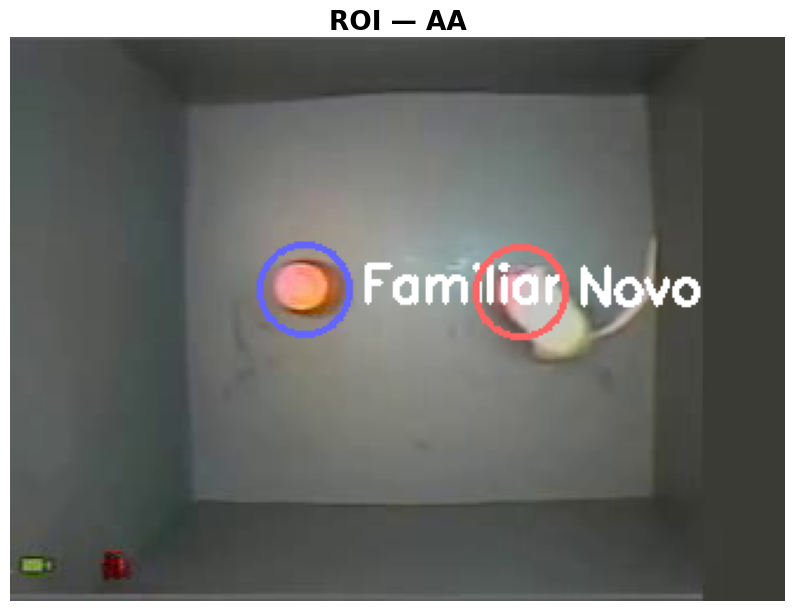

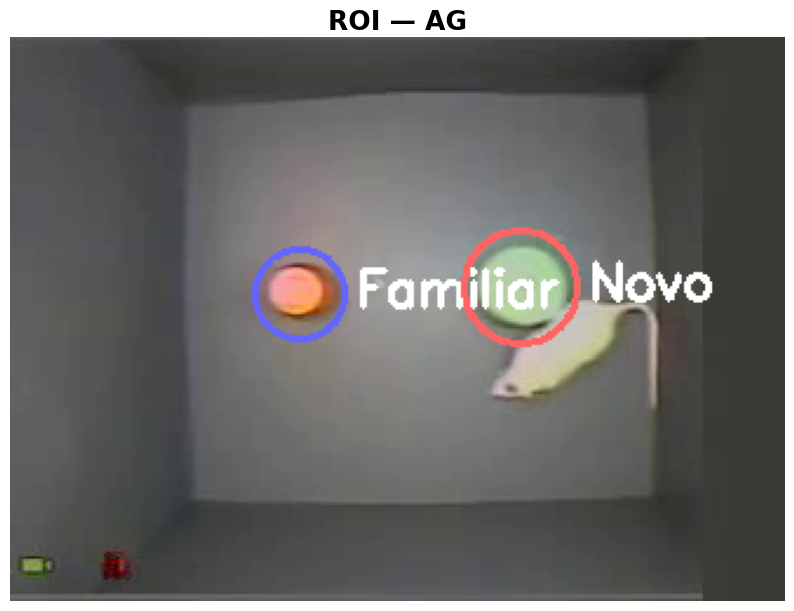

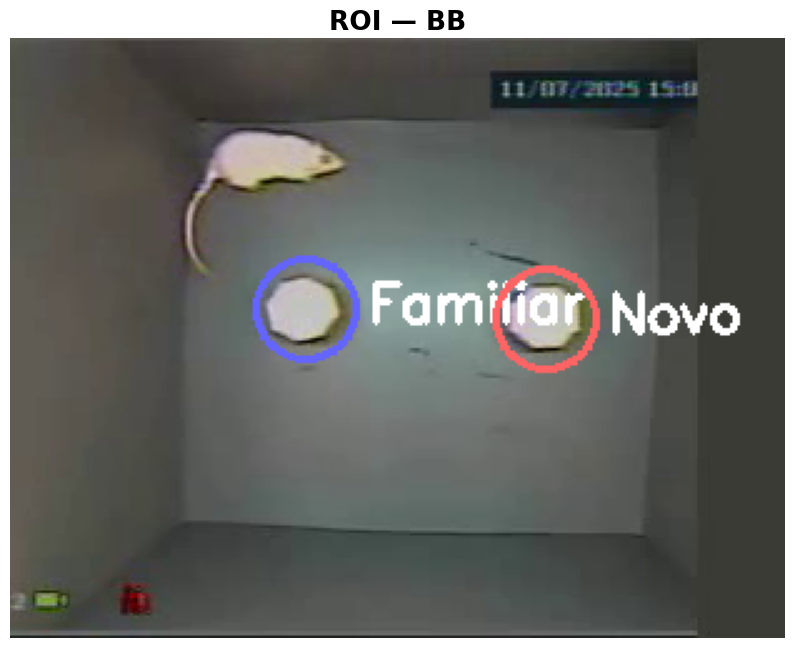

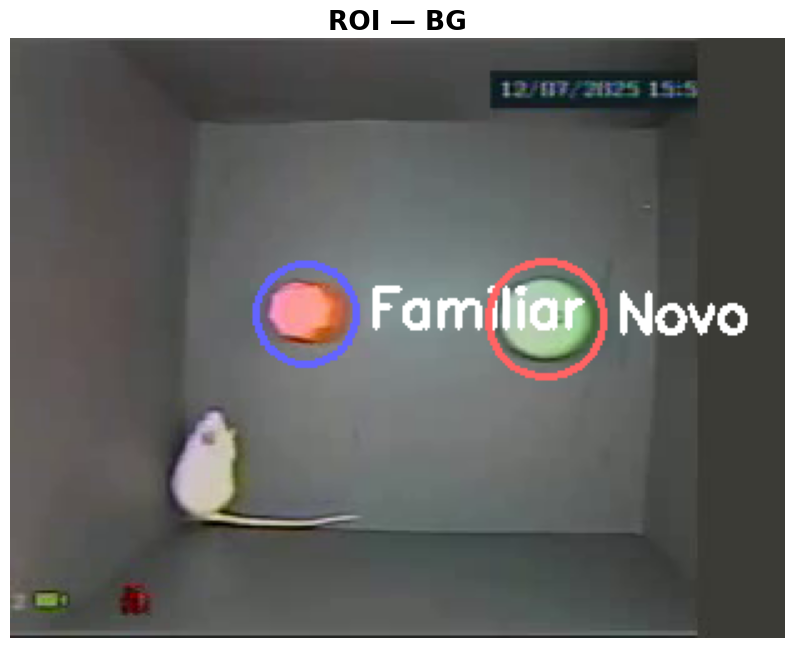

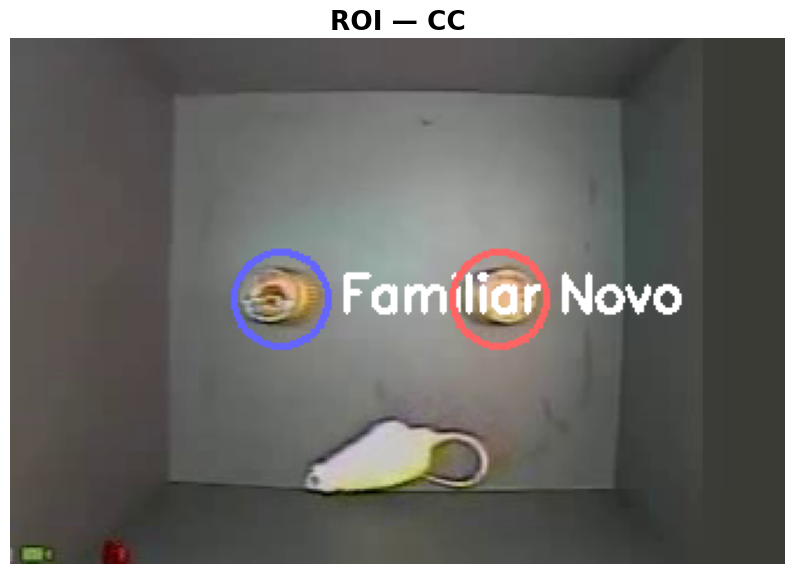

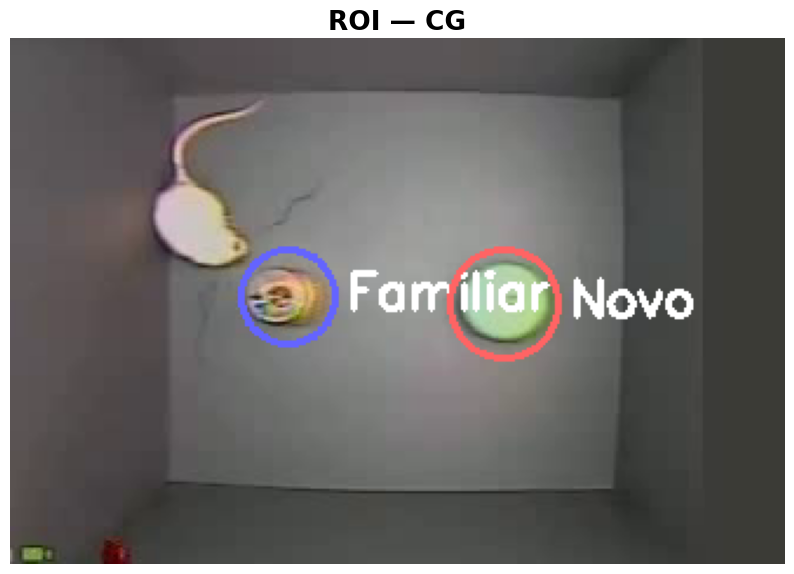

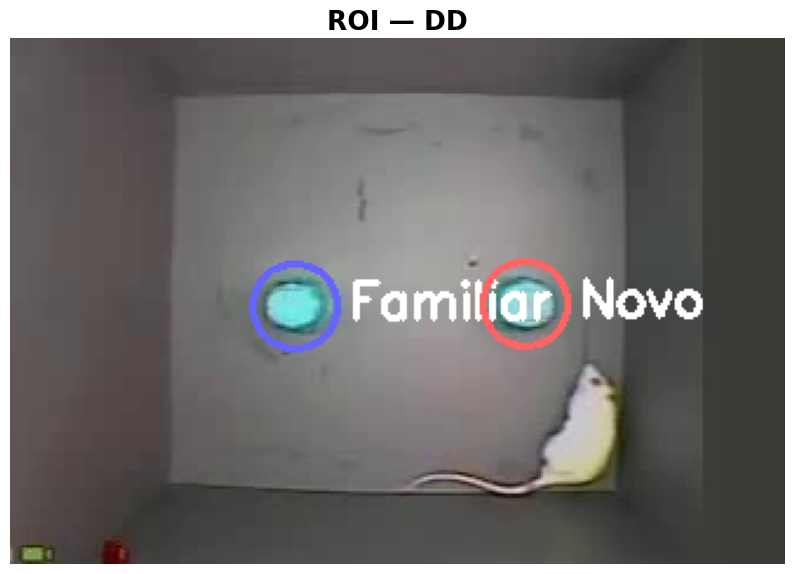

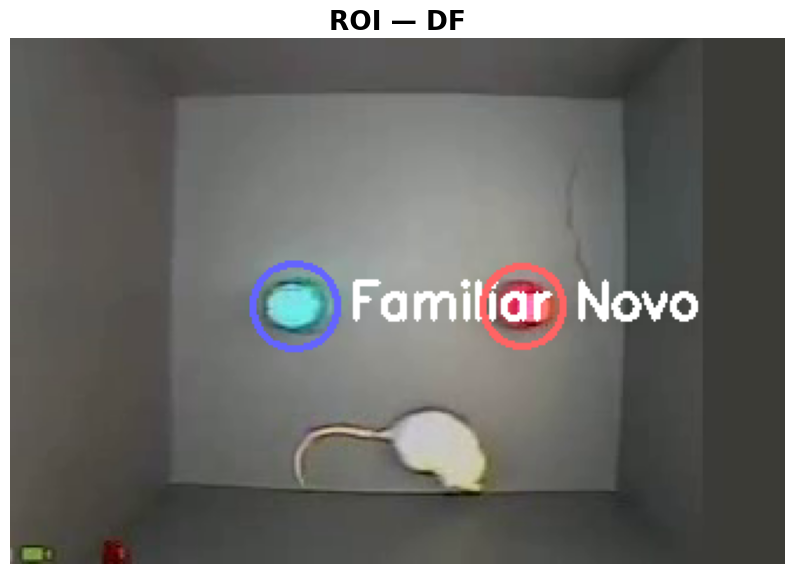

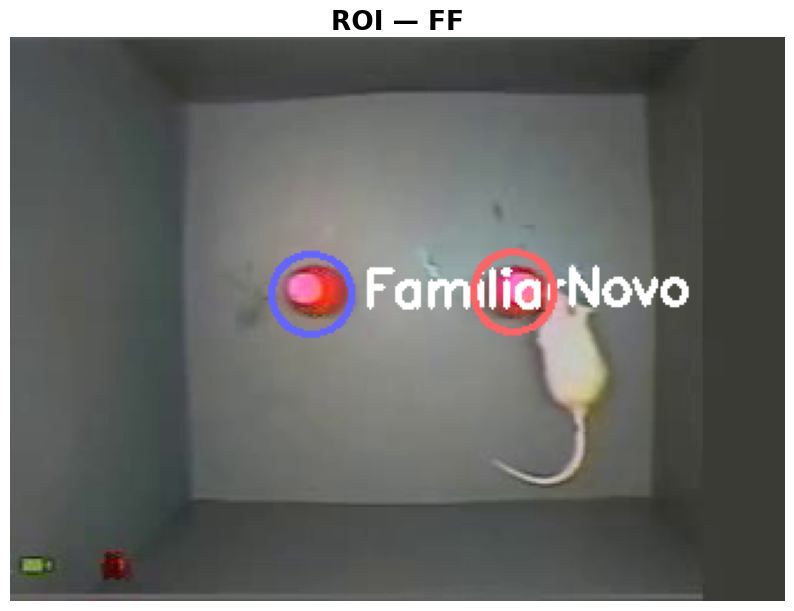

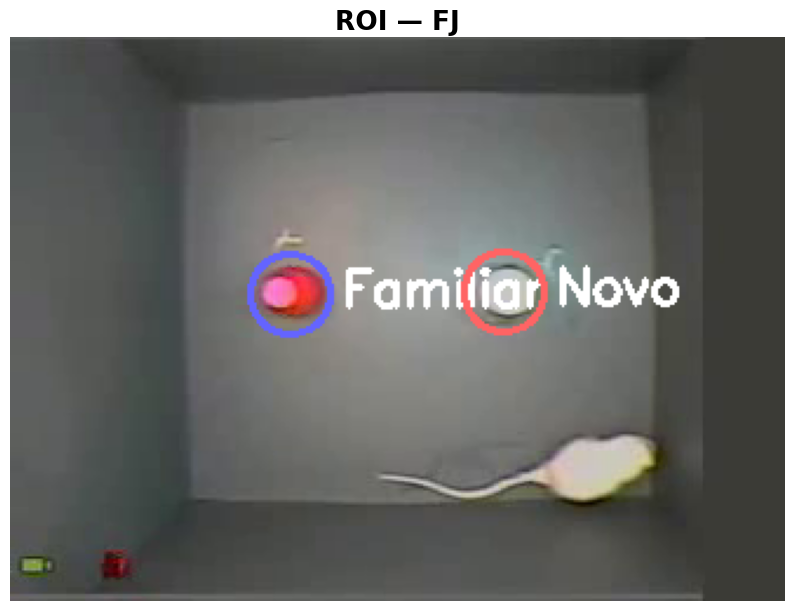

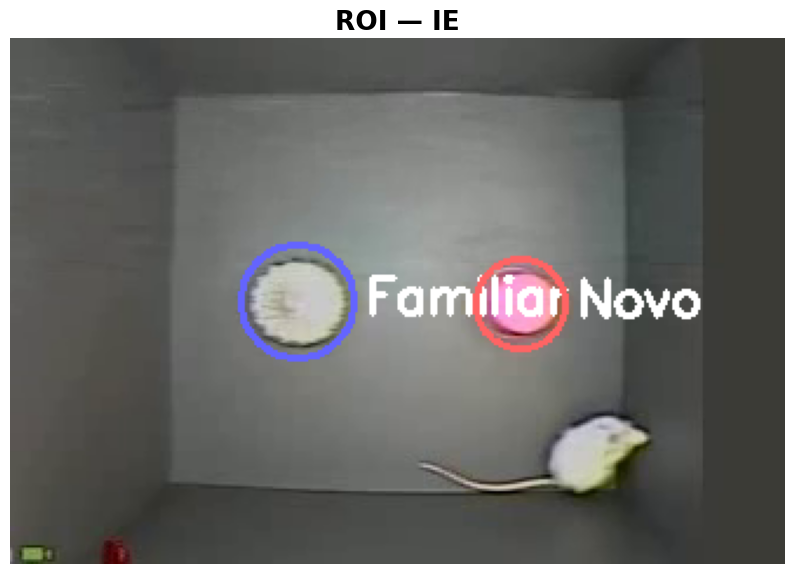

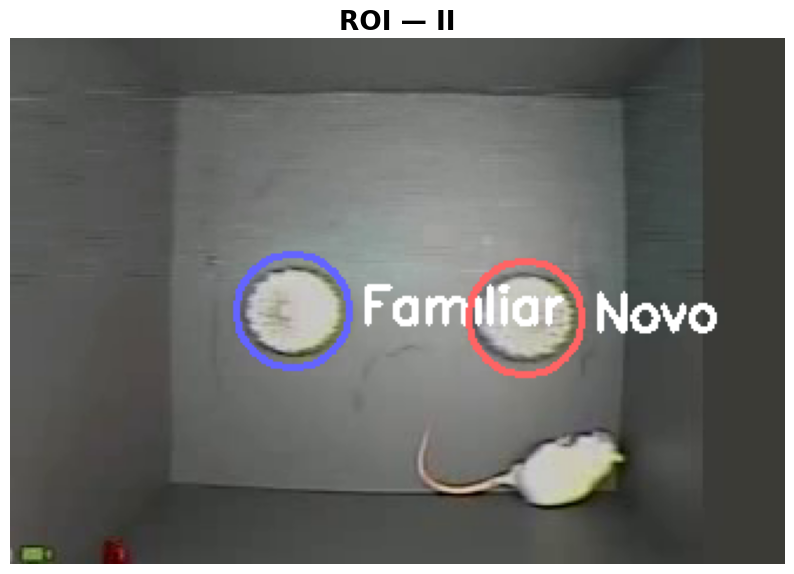

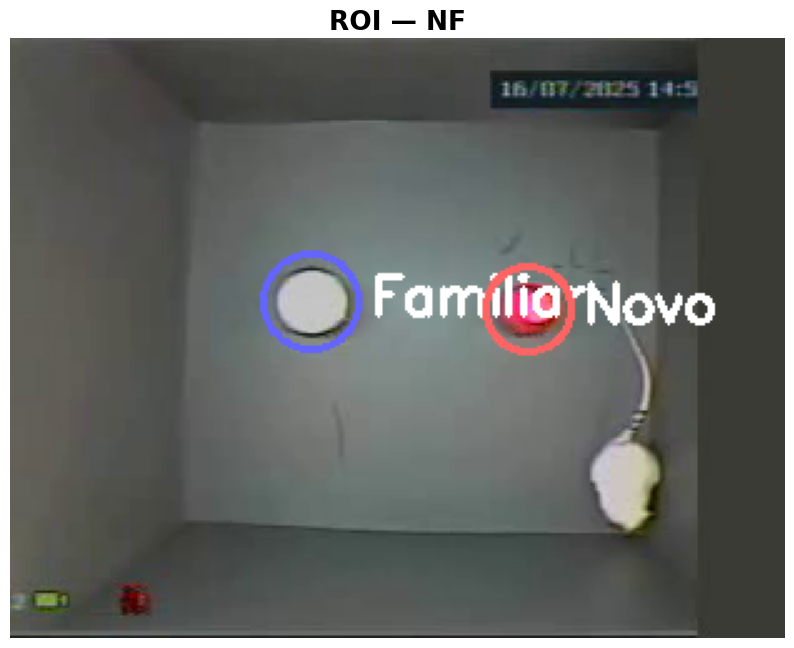

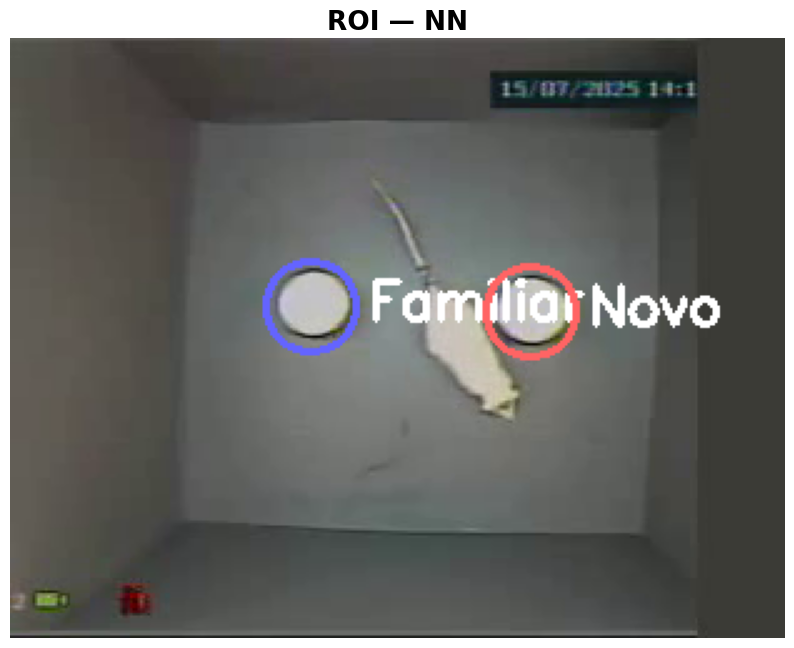

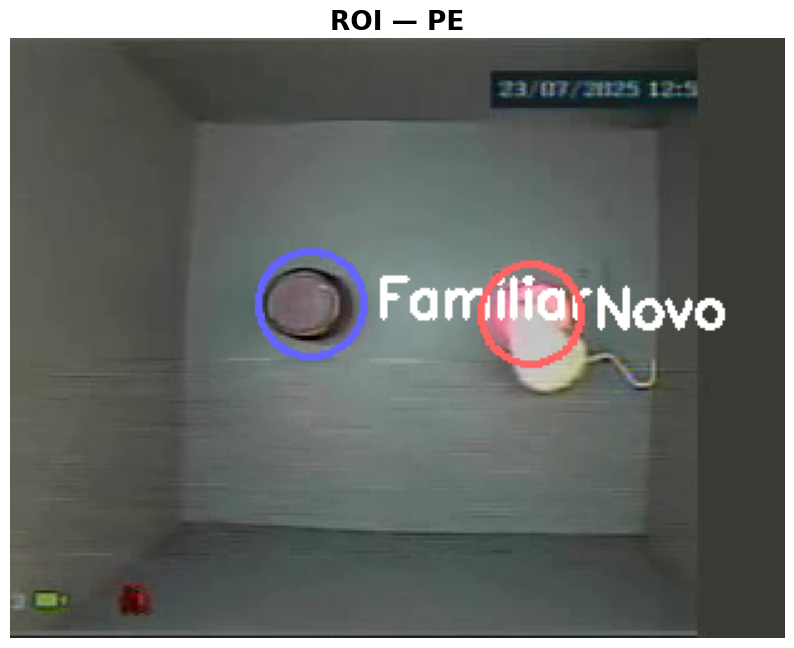

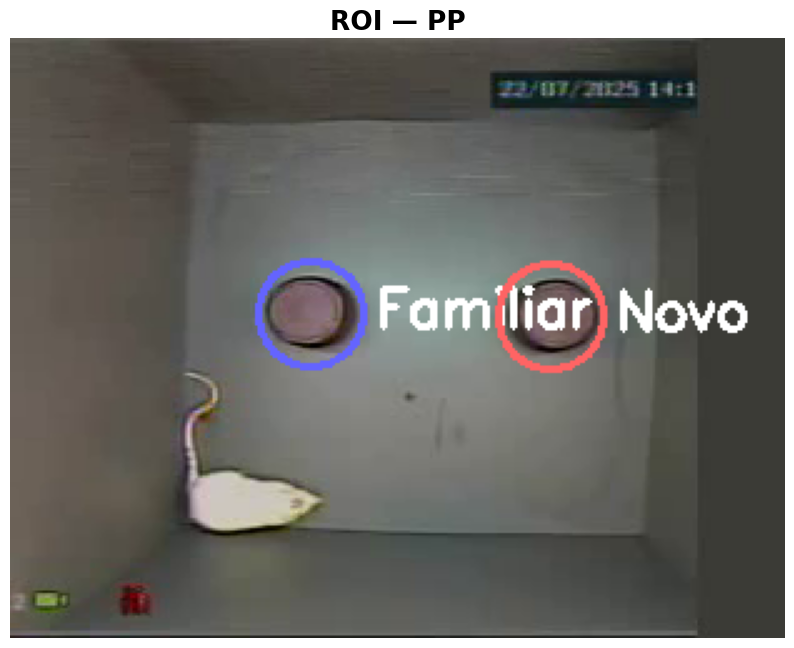

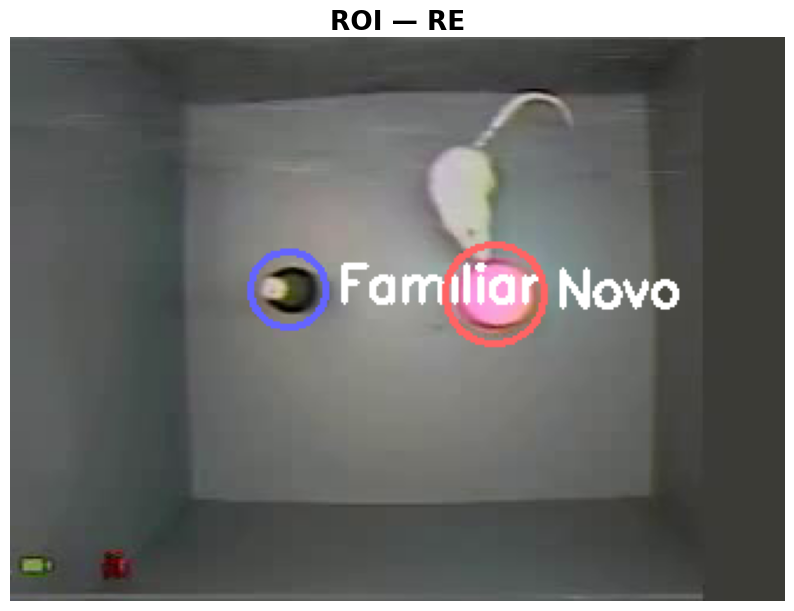

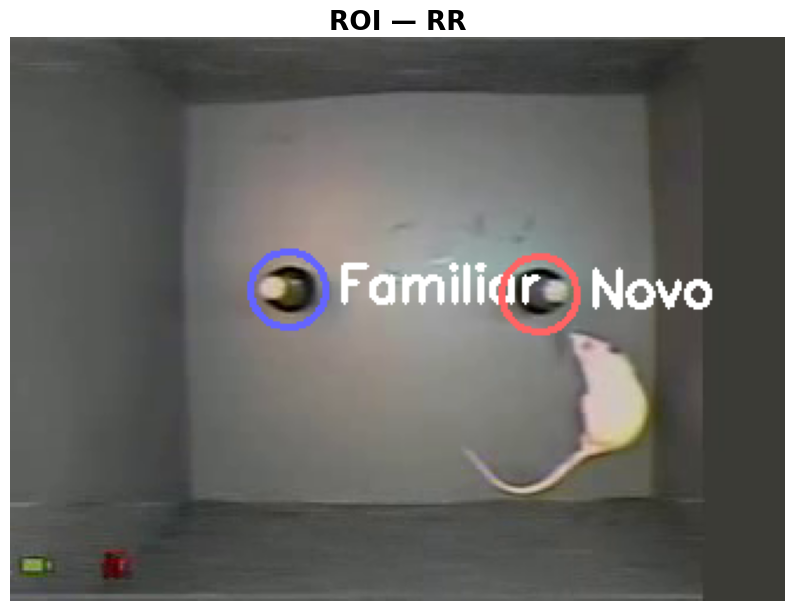

In [ ]:
# Define as ROIs por animal a partir do JSON/dicionário carregado.
rois_definidas = definir_rois(ratos_comuns, arquivos_topscan)

if VERIFICAR_ROIS_VISUALMENTE:
    verificar_rois(rois_definidas, arquivos_topscan)
else:
    print("Verificação visual das ROIs desativada (VERIFICAR_ROIS_VISUALMENTE=False).")

## Bloco 2.2 — Classificação comportamental frame a frame

In [ ]:
def _gerar_periodos(df_exp):
    if df_exp.empty:
        return []
    periodos = []
    start, ultimo = None, None
    df_exp = df_exp.sort_values('time').dropna(subset=['time'])
    for _, row in df_exp.iterrows():
        t, tipo = row['time'], row['exploration_type']
        if tipo != ultimo:
            if ultimo is not None and start is not None:
                dur = max(0, t - start - 1 / FPS_VIDEO)
                if dur > 1e-9:
                    periodos.append((start, dur, ultimo))
            start, ultimo = t, tipo
    if ultimo is not None and start is not None and not df_exp.empty:
        dur = max(0, df_exp['time'].max() - start - 1 / FPS_VIDEO)
        if dur > 1e-9:
            periodos.append((start, dur, ultimo))
    return periodos


def calcular_exploracao_comportamental(ratos_comuns, arquivos_topscan, arquivos_dlc, rois_definidas):
    tempos_salvos = {}
    cores = {'objeto_Familiar': '#cc5500', 'objeto_Novo': '#5472cc', 'chao': '#E0E0E0'}

    for rato_id in ratos_comuns:
        info_ts  = arquivos_topscan.get(rato_id)
        info_dlc = arquivos_dlc.get(BODYPART_LEGENDA, {}).get(rato_id)
        rois     = rois_definidas.get(rato_id)
        if not all([info_ts, info_dlc, rois]):
            continue

        # --- TopScan ---
        df_ts = carregar_dados_topscan_txt(os.path.join(DIRETORIO_TOPSCAN_TXT, info_ts['arquivo_txt']))
        if df_ts is None or 'Areas' not in df_ts.columns:
            continue
        df_ts = adicionar_coluna_tempo(df_ts, 'FrameNum', FPS_VIDEO)
        mapa_areas = _montar_mapa_areas_topscan(df_ts)
        df_ts['exploration_type'] = df_ts['Areas'].apply(lambda a: _classificar_area_topscan(a, mapa_areas))

        # --- DLC ---
        df_dlc = carregar_dados_dlc_txt(os.path.join(DIRETORIO_DLC_TXT, info_dlc))
        if df_dlc is None:
            continue
        df_dlc = adicionar_coluna_tempo(df_dlc, 'Frame', FPS_VIDEO)
        df_dlc['exploration_type'] = df_dlc.apply(
            determinar_exploracao_dlc, axis=1, definicoes=rois, col_x='X', col_y='Y')

        periodos_ts  = _gerar_periodos(df_ts)
        periodos_dlc = _gerar_periodos(df_dlc)

        # Calcular tempos
        tempos = {s: {'objeto_Familiar': 0, 'objeto_Novo': 0}
                  for s in ['topscan', 'dlc']}
        for sistema, periodos in [('topscan', periodos_ts), ('dlc', periodos_dlc)]:
            for _, dur, tipo in periodos:
                if tipo in tempos[sistema]:
                    tempos[sistema][tipo] += dur

        tempos_salvos[rato_id] = {
            "topscan_novo": tempos['topscan']['objeto_Novo'],
            "topscan_familiar": tempos['topscan']['objeto_Familiar'],
            "dlc_novo": tempos['dlc']['objeto_Novo'],
            "dlc_familiar": tempos['dlc']['objeto_Familiar'],
        }

        # --- Broken Bar ---
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5), sharex=True, constrained_layout=True)
        for ax, periodos in [(ax1, periodos_ts), (ax2, periodos_dlc)]:
            for start, dur, tipo in periodos:
                ax.broken_barh([(start, dur)], (0, 1), facecolors=cores.get(tipo, '#808080'))

        max_time = max(df_ts['time'].max() if not df_ts.empty else 0,
                       df_dlc['time'].max() if not df_dlc.empty else 0)
        for ax, nome in [(ax1, 'TopScan'), (ax2, 'DeepLabCut')]:
            ax.set_ylim(0, 1); ax.set_yticks([0.5]); ax.set_yticklabels([nome], fontsize=15)
            ax.grid(True, axis='x', linestyle='--', alpha=0.7)
            ax.set_xlim(0, max_time if max_time > 0 else 300)

        ax1.set_title(f' ')
        ax2.set_xlabel('Tempo (segundos)', fontsize=15)
        patches = [mpatches.Patch(color=cores[k], label=k.replace('objeto_', 'Objeto ').capitalize())
                   for k in cores]
        fig.legend(handles=patches, loc='upper right', ncol=len(patches))
        plt.suptitle(f"Exploração Comportamental — {rato_id}", fontsize=16)
        plt.show()

    return tempos_salvos


tempos_salvos = calcular_exploracao_comportamental(
    ratos_comuns, arquivos_topscan, arquivos_dlc, rois_definidas)

## Bloco 3 — Estatística, tabelas e interpretação executável

### 3.1 Métricas de similaridade de trajetória

In [ ]:
def executar_estatistica(ratos_comuns, resultados_cm, arquivos_dlc, rois_definidas, tempos_salvos):
    print("\n=== 4.1 Métricas de Similaridade: ESSA PARTE É DEMORADA ===")
    resultados_metricas = []

    diagonal_arena = np.sqrt(60**2 + 60**2)

    for rato_id in sorted(ratos_comuns):
        df_an = _sincronizar_dados_cm(rato_id, resultados_cm)
        if df_an is None:
            continue

        traj_ts = df_an[['x_cm_topscan', 'y_cm_topscan']].values
        traj_dlc = df_an[['x_cm_dlc', 'y_cm_dlc']].values

        df_an['distancia_cm'] = np.sqrt(
            (df_an['x_cm_dlc'] - df_an['x_cm_topscan'])**2 +
            (df_an['y_cm_dlc'] - df_an['y_cm_topscan'])**2
        )

        rmse = np.sqrt(np.mean(df_an['distancia_cm']**2))
        mae = df_an['distancia_cm'].mean()
        std_err = df_an['distancia_cm'].std()

        frechet = similaritymeasures.frechet_dist(traj_dlc, traj_ts)

        dtw, _ = similaritymeasures.dtw(traj_dlc, traj_ts)

        # DTW normalizado
        dtw_medio = dtw / len(traj_dlc)
        dtw_norm = dtw_medio / diagonal_arena
        dtw_norm = min(dtw_norm, 1)

        # Similaridade baseada no DTW
        dtw_similaridade = 1 - dtw_norm

        corr_x, _ = pearsonr(df_an['x_cm_dlc'], df_an['x_cm_topscan'])
        corr_y, _ = pearsonr(df_an['y_cm_dlc'], df_an['y_cm_topscan'])

        qc_flag = 'ok'
        try:
            serie_qc = resultados_cm[rato_id][BODYPART_REFERENCIA]['topscan'].get('qc_flag')
            if isinstance(serie_qc, pd.Series) and not serie_qc.empty:
                qc_flag = str(serie_qc.iloc[0])
        except Exception:
            pass

        resultados_metricas.append({
            "ID Animal": rato_id,
            "RMSE (cm)": rmse,
            "MAE (cm)": mae,
            "Std Erro (cm)": std_err,
            "Fréchet (cm)": frechet,
            "DTW bruto": dtw,
            "DTW médio (cm/frame)": dtw_medio,
            "DTW norm. (0-1)": dtw_norm,
            "Similaridade DTW (0-1)": dtw_similaridade,
            "Corr X": corr_x,
            "Corr Y": corr_y,
            "QC": qc_flag,
        })

    if resultados_metricas:
        df_met = pd.DataFrame(resultados_metricas)
        pd.set_option('display.float_format', '{:.3f}'.format)
        print(df_met.to_string(index=False))
        return df_met

    return pd.DataFrame()

df_metricas = executar_estatistica(
    ratos_comuns,
    resultados_cm,
    arquivos_dlc,
    rois_definidas,
    tempos_salvos
)

### 3.2 Mapa de calor do erro

In [ ]:
print("\n=== 4.2 Mapas de Calor do Erro ===")
NUM_BINS = 50
for rato_id in ratos_comuns:
    df_an = _sincronizar_dados_cm(rato_id, resultados_cm)
    if df_an is None:
        continue

    df_an['distancia_cm'] = np.sqrt(
        (df_an['x_cm_dlc'] - df_an['x_cm_topscan'])**2 +
        (df_an['y_cm_dlc'] - df_an['y_cm_topscan'])**2
    )

    df_plot = df_an.copy()
    if NORMALIZAR_VISUAL_60X60:
        x_all = pd.concat([df_plot['x_cm_topscan'], df_plot['x_cm_dlc']]).astype(float)
        y_all = pd.concat([df_plot['y_cm_topscan'], df_plot['y_cm_dlc']]).astype(float)
        x_min, x_max = np.nanmin(x_all.values), np.nanmax(x_all.values)
        y_min, y_max = np.nanmin(y_all.values), np.nanmax(y_all.values)
        dx, dy = x_max - x_min, y_max - y_min
        if dx > 0 and dy > 0:
            df_plot['x_cm_topscan'] = (df_plot['x_cm_topscan'] - x_min) * (ARENA_LARGURA_CM / dx)
            df_plot['y_cm_topscan'] = (df_plot['y_cm_topscan'] - y_min) * (ARENA_ALTURA_CM / dy)
            df_plot['x_cm_dlc'] = (df_plot['x_cm_dlc'] - x_min) * (ARENA_LARGURA_CM / dx)
            df_plot['y_cm_dlc'] = (df_plot['y_cm_dlc'] - y_min) * (ARENA_ALTURA_CM / dy)

    bins_x = np.linspace(0, ARENA_LARGURA_CM, NUM_BINS + 1)
    bins_y = np.linspace(0, ARENA_ALTURA_CM,  NUM_BINS + 1)

    hm_sum, _, _ = np.histogram2d(df_plot['x_cm_dlc'], df_plot['y_cm_dlc'],
                                    bins=[bins_x, bins_y], weights=df_an['distancia_cm'])
    hm_cnt, _, _ = np.histogram2d(df_plot['x_cm_dlc'], df_plot['y_cm_dlc'], bins=[bins_x, bins_y])
    hm_avg = np.divide(hm_sum, hm_cnt, out=np.zeros_like(hm_sum), where=hm_cnt != 0)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(hm_avg.T, origin='lower', cmap='jet',
                    extent=[0, ARENA_LARGURA_CM, 0, ARENA_ALTURA_CM])
    ax.plot(df_plot['x_cm_dlc'], df_plot['y_cm_dlc'], color='white', alpha=0.3, linewidth=1)
    cbar = fig.colorbar(im, ax=ax); cbar.set_label('Erro Médio (cm)')
    ax.set_title(f'Mapa de Calor do Erro — {rato_id}')
    ax.set_xlabel('X (cm)'); ax.set_ylabel('Y (cm)')
    ax.set_xlim(0, ARENA_LARGURA_CM); ax.set_ylim(0, ARENA_ALTURA_CM)
    ax.set_aspect('equal', adjustable='box')
    plt.show()

### 3.3 Erro por estado comportamental

In [ ]:
print("\n=== 4.3 Erro por Estado Comportamental ===")
dados_anova = []
for rato_id in ratos_comuns:
    df_an = _sincronizar_dados_cm(rato_id, resultados_cm)
    if df_an is None:
        continue
    df_an['distancia_cm'] = np.sqrt(
        (df_an['x_cm_dlc'] - df_an['x_cm_topscan'])**2 +
        (df_an['y_cm_dlc'] - df_an['y_cm_topscan'])**2
    )
    info_dlc = arquivos_dlc.get(BODYPART_LEGENDA, {}).get(rato_id)
    rois     = rois_definidas.get(rato_id)
    if not info_dlc or not rois:
        continue
    df_comp = preparar_dados_dlc_para_video(
        os.path.join(DIRETORIO_DLC_TXT, info_dlc), FPS_VIDEO, definicoes_objetos=rois)
    if df_comp is None:
        continue
    df_final = pd.merge(df_an, df_comp[['FrameNum', 'exploration_type']], on='FrameNum')
    if df_final.empty:
        continue

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_final, x='exploration_type', y='distancia_cm',
                palette=['#E0E0E0', '#9E9E9E', '#616161'], showfliers=False)
    plt.title(f'Erro por Estado Comportamental — {rato_id}')
    plt.xlabel('Estado (DLC)'); plt.ylabel('Erro (cm)')
    plt.tight_layout(); plt.show()

    for cond, err in df_final.groupby('exploration_type')['distancia_cm'].mean().items():
        dados_anova.append({'sujeito': rato_id, 'condicao': cond, 'erro_medio_cm': err})

if dados_anova:
    df_av = pd.DataFrame(dados_anova)
    print("\n--- ANOVA de Medidas Repetidas ---")
    try:
        aov = pg.rm_anova(data=df_av, dv='erro_medio_cm', within='condicao', subject='sujeito', detailed=True)
        print(aov.round(4))
        p_val = aov.loc[0, 'p-GG-corr'] if aov.loc[0, 'p-spher'] < 0.05 else aov.loc[0, 'p-unc']
        if p_val < 0.05:
            posthoc = pg.pairwise_tests(data=df_av, dv='erro_medio_cm',
                                          within='condicao', subject='sujeito', padjust='bonf')
            print("\nPost-hoc (Bonferroni):")
            print(posthoc.round(4))
    except Exception as e:
        print(f"ANOVA falhou: {e}")

    mapa_pt = {'chao': 'Chão', 'objeto_Familiar': 'Objeto Familiar', 'objeto_Novo': 'Objeto Novo'}
    df_av['condicao_pt'] = df_av['condicao'].map(mapa_pt)
    ordem = [v for v in ['Chão', 'Objeto Familiar', 'Objeto Novo'] if v in df_av['condicao_pt'].values]
    plt.figure(figsize=(10, 7))
    sns.barplot(data=df_av, x='condicao_pt', y='erro_medio_cm', order=ordem,
                palette=['#E0E0E0', '#9E9E9E', '#616161'], errorbar='se',
                capsize=0.1, edgecolor='.1', linewidth=1.5)
    plt.xlabel('Estado Comportamental', fontweight='bold')
    plt.ylabel('Erro Médio de Distância (cm)', fontweight='bold')
    plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# FIGURA 6 — Broken bar + Erro posicional por estado comportamental
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches


def _serie_para_periodos(df, col_estado, col_tempo='time'):
    """
    Converte uma coluna categórica frame a frame em períodos contínuos.
    Retorna dicionário:
    {
        'objeto_Familiar': [(inicio, duração), ...],
        'objeto_Novo': [(inicio, duração), ...],
        'chao': [(inicio, duração), ...]
    }
    """
    df = df[[col_tempo, col_estado]].dropna().copy()
    df = df.sort_values(col_tempo)

    periodos = {
        'objeto_Familiar': [],
        'objeto_Novo': [],
        'chao': []
    }

    if df.empty:
        return periodos

    estado_atual = df[col_estado].iloc[0]
    inicio = df[col_tempo].iloc[0]
    tempo_anterior = inicio

    for _, row in df.iloc[1:].iterrows():
        estado = row[col_estado]
        tempo = row[col_tempo]

        if estado != estado_atual:
            duracao = tempo_anterior - inicio
            if estado_atual in periodos and duracao > 0:
                periodos[estado_atual].append((inicio, duracao))

            estado_atual = estado
            inicio = tempo

        tempo_anterior = tempo

    duracao = tempo_anterior - inicio
    if estado_atual in periodos and duracao > 0:
        periodos[estado_atual].append((inicio, duracao))

    return periodos


def _classificar_topscan_por_area(df_topscan):
    """
    Classifica os estados do TopScan a partir da coluna Areas.
    Ajuste os nomes se seus arquivos tiverem nomenclatura diferente.
    """
    df = df_topscan.copy()

    if 'Areas' not in df.columns:
        df['estado_topscan'] = 'chao'
        return df

    def classificar(area):
        area_str = str(area).lower()

        if any(x.lower() in area_str for x in NOMES_OBJETOS_FAMILIARES):
            return 'objeto_Familiar'

        if any(x.lower() in area_str for x in NOMES_OBJETOS_NOVOS):
            return 'objeto_Novo'

        return 'chao'

    df['estado_topscan'] = df['Areas'].apply(classificar)

    return df


def gerar_figura_brokenbar_erro_estado(
    rato_exemplo,
    resultados_cm,
    arquivos_topscan,
    arquivos_dlc,
    rois_definidas,
    salvar=False,
    caminho_saida="/content/figura6_brokenbar_erro_estado.png"
):
    """
    Gera uma figura composta:
    A) Etograma/broken bar TopScan vs DeepLabCut para um registro representativo.
    B) Erro posicional médio por estado comportamental usando todos os registros.
    """

    # ------------------------------------------------------------
    # PAINEL A — Broken bar do animal representativo
    # ------------------------------------------------------------
    df_an = _sincronizar_dados_cm(rato_exemplo, resultados_cm)

    if df_an is None or df_an.empty:
        raise ValueError(f"Não foi possível sincronizar dados para {rato_exemplo}.")

    df_an = df_an.copy()

    df_an['distancia_cm'] = np.sqrt(
        (df_an['x_cm_dlc'] - df_an['x_cm_topscan'])**2 +
        (df_an['y_cm_dlc'] - df_an['y_cm_topscan'])**2
    )

    # Recupera dados brutos e usa a mesma classificacao do broken bar original.
    info_ts = arquivos_topscan.get(rato_exemplo)
    info_dlc = arquivos_dlc.get(BODYPART_LEGENDA, {}).get(rato_exemplo)
    rois = rois_definidas.get(rato_exemplo)

    if not info_ts:
        raise ValueError(f"Arquivo TopScan nao encontrado para {rato_exemplo}.")
    if not info_dlc:
        raise ValueError(f"Arquivo DLC nao encontrado para {rato_exemplo}.")
    if not rois:
        raise ValueError(f"ROIs nao definidas para {rato_exemplo}.")

    df_ts_estado = carregar_dados_topscan_txt(
        os.path.join(DIRETORIO_TOPSCAN_TXT, info_ts['arquivo_txt'])
    )
    if df_ts_estado is None or 'Areas' not in df_ts_estado.columns:
        raise ValueError(f"Dados TopScan/Areas nao encontrados para {rato_exemplo}.")

    df_ts_estado = adicionar_coluna_tempo(df_ts_estado, 'FrameNum', FPS_VIDEO)
    mapa_areas = _montar_mapa_areas_topscan(df_ts_estado)
    df_ts_estado['exploration_type'] = df_ts_estado['Areas'].apply(
        lambda a: _classificar_area_topscan(a, mapa_areas)
    )

    df_dlc_estado = carregar_dados_dlc_txt(os.path.join(DIRETORIO_DLC_TXT, info_dlc))
    if df_dlc_estado is None or df_dlc_estado.empty:
        raise ValueError(f"Nao foi possivel preparar dados DLC para {rato_exemplo}.")

    df_dlc_estado = adicionar_coluna_tempo(df_dlc_estado, 'Frame', FPS_VIDEO)
    df_dlc_estado['exploration_type'] = df_dlc_estado.apply(
        determinar_exploracao_dlc,
        axis=1,
        definicoes=rois,
        col_x='X',
        col_y='Y'
    )

    # Garante mesmo intervalo de frames usado na analise
    df_ts_estado = df_ts_estado[df_ts_estado['FrameNum'].isin(df_an['FrameNum'])]
    df_dlc_estado = df_dlc_estado[df_dlc_estado['Frame'].isin(df_an['FrameNum'])]

    periodos_topscan = _gerar_periodos(df_ts_estado)
    periodos_dlc = _gerar_periodos(df_dlc_estado)

    # ------------------------------------------------------------
    # PAINEL B — Erro por estado comportamental em todos os registros
    # ------------------------------------------------------------
    dados_estado = []

    for rato_id in sorted(resultados_cm.keys()):
        df_tmp = _sincronizar_dados_cm(rato_id, resultados_cm)

        if df_tmp is None or df_tmp.empty:
            continue

        df_tmp = df_tmp.copy()

        df_tmp['distancia_cm'] = np.sqrt(
            (df_tmp['x_cm_dlc'] - df_tmp['x_cm_topscan'])**2 +
            (df_tmp['y_cm_dlc'] - df_tmp['y_cm_topscan'])**2
        )

        info_dlc_tmp = arquivos_dlc.get(BODYPART_LEGENDA, {}).get(rato_id)
        rois_tmp = rois_definidas.get(rato_id)

        if not info_dlc_tmp or not rois_tmp:
            continue

        df_estado_tmp = preparar_dados_dlc_para_video(
            os.path.join(DIRETORIO_DLC_TXT, info_dlc_tmp),
            FPS_VIDEO,
            definicoes_objetos=rois_tmp
        )

        if df_estado_tmp is None or df_estado_tmp.empty:
            continue

        df_estado_tmp = df_estado_tmp[['FrameNum', 'exploration_type']].copy()

        df_final = pd.merge(
            df_tmp[['FrameNum', 'distancia_cm']],
            df_estado_tmp,
            on='FrameNum',
            how='inner'
        )

        if df_final.empty:
            continue

        # Média de erro por registro e por estado comportamental
        for estado, sub in df_final.groupby('exploration_type'):
            if estado in ['chao', 'objeto_Familiar', 'objeto_Novo']:
                dados_estado.append({
                    'ID': rato_id,
                    'Estado': estado,
                    'Erro médio (cm)': sub['distancia_cm'].mean()
                })

    df_estado_grupo = pd.DataFrame(dados_estado)

    if df_estado_grupo.empty:
        raise ValueError("Nenhum dado de erro por estado comportamental foi encontrado.")

    mapa_estado = {
        'chao': 'Chão',
        'objeto_Familiar': 'Objeto familiar',
        'objeto_Novo': 'Objeto novo'
    }

    ordem_estado = ['Chão', 'Objeto familiar', 'Objeto novo']
    df_estado_grupo['Estado'] = df_estado_grupo['Estado'].map(mapa_estado)
    df_estado_grupo = df_estado_grupo.dropna(subset=['Estado'])

    # ------------------------------------------------------------
    # FIGURA COMPOSTA
    # ------------------------------------------------------------
    fig = plt.figure(figsize=(13, 8.8), constrained_layout=False)
    ax_a = fig.add_axes([0.140, 0.625, 0.845, 0.305])
    ax_b = fig.add_axes([0.250, 0.080, 0.590, 0.405])

    # ------------------------
    # Painel A — Broken bar
    # ------------------------
    cores = {
        'objeto_Familiar': '#D55E00',
        'objeto_Novo': '#4F6FD7',
        'chao': '#D9D9D9'
    }

    altura = 0.72

    for start, dur, tipo in periodos_topscan:
        ax_a.broken_barh(
            [(start, dur)],
            (1 - altura / 2, altura),
            facecolors=cores.get(tipo, '#808080'),
            edgecolors='none'
        )

    for start, dur, tipo in periodos_dlc:
        ax_a.broken_barh(
            [(start, dur)],
            (0 - altura / 2, altura),
            facecolors=cores.get(tipo, '#808080'),
            edgecolors='none'
        )

    ax_a.set_yticks([1, 0])
    ax_a.set_yticklabels(['TopScan', 'DeepLabCut'], fontsize=13)
    ax_a.set_xlabel('Tempo (segundos)', fontsize=13)
    ax_a.set_title('Exploração comportamental', fontsize=15, fontweight='bold', y=1.1)

    ax_a.set_ylim(-0.45, 1.45)
    ax_a.set_xlim(0, max(df_ts_estado['time'].max(), df_dlc_estado['time'].max()))
    ax_a.grid(True, axis='x', linestyle=':', alpha=0.4)

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=cores['objeto_Familiar']),
        plt.Rectangle((0, 0), 1, 1, color=cores['objeto_Novo']),
        plt.Rectangle((0, 0), 1, 1, color=cores['chao'])
    ]

    ax_a.legend(
        handles,
        ['Objeto familiar', 'Objeto novo', 'Chão'],
        loc='upper right',
        bbox_to_anchor=(1.0, 1.08),
        frameon=True,
        fontsize=10,
        ncol=3
    )

    # ------------------------
    # Painel B — Erro por estado comportamental
    # ------------------------
    palette = {
        'Chão': '#D9D9D9',
        'Objeto familiar': '#666666',
        'Objeto novo': '#A6A6A6'
    }

    sns.boxplot(
        data=df_estado_grupo,
        x='Estado',
        y='Erro médio (cm)',
        order=ordem_estado,
        palette=palette,
        showfliers=False,
        width=0.55,
        linewidth=1.2,
        ax=ax_b
    )

    sns.stripplot(
        data=df_estado_grupo,
        x='Estado',
        y='Erro médio (cm)',
        order=ordem_estado,
        color='black',
        alpha=0.9,
        size=5,
        jitter=0.08,
        ax=ax_b
    )

    # ---> ADIÇÃO DA BARRA DE SIGNIFICNCIA ('ns') <---
    ymax_b = df_estado_grupo['Erro médio (cm)'].max() + 0.15
    # Linha ligando os 3 grupos (do x=0 ao x=2)
    ax_b.plot([0, 0, 2, 2], [ymax_b, ymax_b+0.05, ymax_b+0.05, ymax_b], color='black', lw=1.2)
    # Texto 'ns' centralizado no x=1 (Objeto familiar)
    ax_b.text(1, ymax_b+0.07, 'ns', ha='center', va='bottom', fontsize=14, fontweight='bold', fontstyle='italic')

    ax_b.set_title('Erro Posicional Médio x Estado Comportamental', fontsize=14, fontweight='bold', pad=8)
    ax_b.set_xlabel('Estado comportamental', fontsize=13)
    ax_b.set_ylabel('Erro médio (cm)', fontsize=13)
    ax_b.grid(True, axis='y', linestyle=':', alpha=0.5)

    def _contornar_painel_fig4(fig, ax, letra, pad_left=0.065, pad_right=0.020,
                               pad_bottom=0.055, pad_top=0.060):
        pos = ax.get_position()
        x0 = pos.x0 - pad_left
        y0 = pos.y0 - pad_bottom
        x1 = pos.x1 + pad_right
        y1 = pos.y1 + pad_top
        borda = mpatches.FancyBboxPatch(
            (x0, y0), x1 - x0, y1 - y0,
            boxstyle='round,pad=0.004,rounding_size=0.004',
            transform=fig.transFigure,
            facecolor='none',
            edgecolor='black',
            alpha=0.5,
            linewidth=1.0,
            zorder=3,
            clip_on=False
        )
        fig.add_artist(borda)
        fig.text(
            x0 + 0.008, y1 - 0.012, letra,
            fontsize=22, fontweight='bold',
            ha='left', va='top',
            bbox=dict(facecolor='white', edgecolor='0.85', boxstyle='square,pad=0.18')
        )

    _contornar_painel_fig4(fig, ax_a, 'A', pad_left=0.100, pad_right=0.020,
                           pad_bottom=0.060, pad_top=0.080)
    _contornar_painel_fig4(fig, ax_b, 'B', pad_left=0.065, pad_right=0.020,
                           pad_bottom=0.065, pad_top=0.060)

    if salvar:
        fig.savefig(caminho_saida, dpi=300, bbox_inches='tight')
        print(f"Figura salva em: {caminho_saida}")

    registrar_figura_artigo('figura4', fig)
    plt.show()

    return df_estado_grupo

df_erro_estado = gerar_figura_brokenbar_erro_estado(
    rato_exemplo='AA',
    resultados_cm=resultados_cm,
    arquivos_topscan=arquivos_topscan,
    arquivos_dlc=arquivos_dlc,
    rois_definidas=rois_definidas,
    salvar=True,
    caminho_saida='/content/figura6_brokenbar_erro_estado.png'
)

### 3.4 Índice de Discriminação, normalidade e teste pareado

In [ ]:
print("\n=== 4.4 Índice de Discriminação ===")
di_ts_list, di_dlc_list, ratos_di = [], [], []
for rato_id, tempos in tempos_salvos.items():
    tt_ts  = tempos["topscan_novo"] + tempos["topscan_familiar"]
    tt_dlc = tempos["dlc_novo"]     + tempos["dlc_familiar"]
    if tt_ts > 0 and tt_dlc > 0:
        di_ts_list.append((tempos["topscan_novo"] - tempos["topscan_familiar"]) / tt_ts)
        di_dlc_list.append((tempos["dlc_novo"]    - tempos["dlc_familiar"])     / tt_dlc)
        ratos_di.append(rato_id)
        print(f"  {rato_id} | DI TopScan={di_ts_list[-1]:.4f}  DI DLC={di_dlc_list[-1]:.4f}")

if len(ratos_di) >= 3:
    diferencas = np.array(di_dlc_list) - np.array(di_ts_list)
    stat_sw, p_sw = shapiro(diferencas)
    print(f"\nShapiro-Wilk (diferenças DI): W={stat_sw:.4f}, p={p_sw:.4f}")
    t_stat, p_t = ttest_rel(di_ts_list, di_dlc_list)
    print(f"Teste t pareado: t={t_stat:.4f}, p={p_t:.4f}")

    fig, ax = plt.subplots(figsize=(9, 6), layout='constrained')
    ax.scatter(di_ts_list, di_dlc_list, c='black', s=50, alpha=0.7)
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'r--', alpha=0.75, label='Concordância Ideal (y=x)')
    ax.set_xlabel('DI TopScan', fontsize=15); ax.set_ylabel('DI DeepLabCut', fontsize=15)
    ax.legend(); ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--')
    plt.show()

### 3.5 Bland-Altman — tempo total de exploração

In [ ]:
print("\n=== 4.5 Bland-Altman ===")
t_ts_arr  = np.array([v["topscan_novo"] + v["topscan_familiar"] for v in tempos_salvos.values()])
t_dlc_arr = np.array([v["dlc_novo"]     + v["dlc_familiar"]     for v in tempos_salvos.values()])
validos   = (t_ts_arr > 0) & (t_dlc_arr > 0)
t_ts_arr, t_dlc_arr = t_ts_arr[validos], t_dlc_arr[validos]

if len(t_ts_arr) >= 2:
    media = (t_ts_arr + t_dlc_arr) / 2
    dif   = t_ts_arr - t_dlc_arr
    vies  = np.mean(dif); sd = np.std(dif, ddof=1)
    print(f"Viés: {vies:.2f} s | Limites ±1.96 SD: [{vies - 1.96*sd:.2f}, {vies + 1.96*sd:.2f}] s")

    fig, ax = plt.subplots(figsize=(9, 6), layout='constrained')
    ax.scatter(media, dif, c='black', s=50, alpha=0.7)
    ax.axhline(vies,             color='red',  linestyle='--', label=f'Viés: {vies:.2f}')
    ax.axhline(vies + 1.96 * sd, color='gray', linestyle=':',  label='±1.96 SD')
    ax.axhline(vies - 1.96 * sd, color='gray', linestyle=':')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Tempo Médio de Exploração (s)')
    ax.set_ylabel('Diferença (TopScan − DLC) (s)')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [ ]:
print("\n=== Figura: Bland-Altman + Ãndice de Discriminação ===")

# -----------------------------
# Dados do Ãndice de Discriminação
# -----------------------------
di_ts_list, di_dlc_list, ratos_di = [], [], []

for rato_id, tempos in tempos_salvos.items():
    tt_ts  = tempos["topscan_novo"] + tempos["topscan_familiar"]
    tt_dlc = tempos["dlc_novo"]     + tempos["dlc_familiar"]

    if tt_ts > 0 and tt_dlc > 0:
        di_ts = (tempos["topscan_novo"] - tempos["topscan_familiar"]) / tt_ts
        di_dlc = (tempos["dlc_novo"] - tempos["dlc_familiar"]) / tt_dlc

        di_ts_list.append(di_ts)
        di_dlc_list.append(di_dlc)
        ratos_di.append(rato_id)

# -----------------------------
# Dados Bland-Altman
# -----------------------------
t_ts_arr = np.array([
    v["topscan_novo"] + v["topscan_familiar"]
    for v in tempos_salvos.values()
])

t_dlc_arr = np.array([
    v["dlc_novo"] + v["dlc_familiar"]
    for v in tempos_salvos.values()
])

validos = (t_ts_arr > 0) & (t_dlc_arr > 0)

t_ts_arr = t_ts_arr[validos]
t_dlc_arr = t_dlc_arr[validos]

media = (t_ts_arr + t_dlc_arr) / 2
dif = t_ts_arr - t_dlc_arr

vies = np.mean(dif)
sd = np.std(dif, ddof=1)

limite_superior = vies + 1.96 * sd
limite_inferior = vies - 1.96 * sd

# -----------------------------
# Estatísticas DI
# -----------------------------
if len(ratos_di) >= 3:
    diferencas_di = np.array(di_dlc_list) - np.array(di_ts_list)

    stat_sw, p_sw = shapiro(diferencas_di)
    t_stat, p_t = ttest_rel(di_ts_list, di_dlc_list)

    print(f"Shapiro-Wilk diferenças DI: W={stat_sw:.4f}, p={p_sw:.4f}")
    print(f"Teste t pareado DI: t={t_stat:.4f}, p={p_t:.4f}")

# -----------------------------
# Figura composta
# -----------------------------
fig = plt.figure(figsize=(14, 6), constrained_layout=False)
ax1 = fig.add_axes([0.075, 0.135, 0.455, 0.755])
ax2 = fig.add_axes([0.630, 0.135, 0.330, 0.755])

# -----------------------------
# A) Bland-Altman
# -----------------------------
ax1.scatter(media, dif, c='black', s=50, alpha=0.7)

ax1.axhline(
    vies,
    color='red',
    linestyle='--',
    label=f'Viés: {vies:.2f} s'
)

ax1.axhline(
    limite_superior,
    color='gray',
    linestyle=':',
    label='±1,96 DP'
)

ax1.axhline(
    limite_inferior,
    color='gray',
    linestyle=':'
)

ax1.axhline(
    0,
    color='black',
    linewidth=0.7,
    alpha=0.7
)

ax1.set_title('Concordância do Tempo Total de Exploração', fontsize=15, fontweight='bold')
ax1.set_xlabel('Tempo médio de exploração (s)', fontsize=14)
ax1.set_ylabel('Diferença (TopScan − DLC) (s)', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.6)

# -----------------------------
# B) DI TopScan vs DLC
# -----------------------------
ax2.scatter(di_ts_list, di_dlc_list, c='black', s=50, alpha=0.7)

min_val = min(min(di_ts_list), min(di_dlc_list))
max_val = max(max(di_ts_list), max(di_dlc_list))
margem = 0.08 * (max_val - min_val)

lims = [min_val - margem, max_val + margem]

ax2.plot(
    lims,
    lims,
    'r--',
    alpha=0.75,
    label='Concordância ideal (y = x)'
)

ax2.set_xlim(lims)
ax2.set_ylim(lims)

ax2.set_title('Concordância do Índice de Discriminação', fontsize=15, fontweight='bold')
ax2.set_xlabel('DI TopScan', fontsize=14)
ax2.set_ylabel('DI DeepLabCut', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_aspect('equal', adjustable='box')

# ============================================================
# Bordas externas e letras dos painéis
# Corrige:
# 1) A e B na mesma altura
# 2) borda cobrindo título, eixos, labels e legenda
# ============================================================

def _bbox_painel_completo(fig, ax, pad=0.018):
    """
    Retorna o bounding box completo do painel em coordenadas da figura,
    incluindo título, rótulos dos eixos, ticks e legenda.
    """
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    bbox = ax.get_tightbbox(renderer).transformed(fig.transFigure.inverted())

    x0 = max(0.0, bbox.x0 - pad)
    y0 = max(0.0, bbox.y0 - pad)
    x1 = min(1.0, bbox.x1 + pad)
    y1 = min(1.0, bbox.y1 + pad)

    return x0, y0, x1, y1


def _adicionar_bordas_e_letras_fig5(fig, ax_a, ax_b):
    x0a, y0a, x1a, y1a = _bbox_painel_completo(fig, ax_a, pad=0.016)
    x0b, y0b, x1b, y1b = _bbox_painel_completo(fig, ax_b, pad=0.016)

    # Força as duas bordas a terem exatamente a mesma altura
    y_bottom = min(y0a, y0b)
    y_top = max(y1a, y1b)

    # Pequeno respiro para não cortar título/letras
    y_bottom = max(0.015, y_bottom - 0.006)
    y_top = min(0.985, y_top + 0.010)

    paineis = [
        (x0a, y_bottom, x1a, y_top, "A"),
        (x0b, y_bottom, x1b, y_top, "B"),
    ]

    for x0, y0, x1, y1, letra in paineis:
        # Borda externa do painel
        borda = mpatches.FancyBboxPatch(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            boxstyle="round,pad=0.004,rounding_size=0.003",
            transform=fig.transFigure,
            facecolor="none",
            edgecolor="0.35",
            linewidth=1.1,
            alpha=0.5,
            zorder=20,
            clip_on=False
        )
        fig.add_artist(borda)

        # Letra A/B com borda própria também opaca
        fig.text(
            x0 + 0.007,
            y1 - 0.010,
            letra,
            fontsize=22,
            fontweight="bold",
            ha="left",
            va="top",
            zorder=30,
            bbox=dict(
                facecolor=(1, 1, 1, 0.50),
                edgecolor=(0.35, 0.35, 0.35, 0.50),
                linewidth=1.1,
                boxstyle="square,pad=0.18"
            )
        )


_adicionar_bordas_e_letras_fig5(fig, ax1, ax2)

registrar_figura_artigo('figura5', fig)

plt.show()

### 3.6 Cross-correlação temporal e lag ótimo

In [ ]:
print("\n=== 4.6 Cross-Correlação Temporal ===")
JANELA = 100
lags_grupo, curvas = [], []

for rato_id in ratos_comuns:
    df_an = _sincronizar_dados_cm(rato_id, resultados_cm)
    if df_an is None or len(df_an) < 20:
        continue
    sig_dlc = (df_an['x_cm_dlc']     - df_an['x_cm_dlc'].mean()).values
    sig_ts  = (df_an['x_cm_topscan'] - df_an['x_cm_topscan'].mean()).values
    corr    = correlate(sig_dlc * hann(len(sig_dlc)), sig_ts * hann(len(sig_ts)), mode='full')
    lags    = np.arange(-len(sig_ts) + 1, len(sig_ts))
    lag_ot  = int(lags[np.argmax(corr)])
    lags_grupo.append({'Rato_ID': rato_id, 'Lag_Otimo': lag_ot})

    idx0 = np.where(lags == 0)[0][0]
    ini, fim = idx0 - JANELA, idx0 + JANELA
    if ini >= 0 and fim < len(corr):
        recorte = corr[ini:fim]
        curvas.append(recorte / np.max(np.abs(recorte)))

if lags_grupo:
    df_lags   = pd.DataFrame(lags_grupo)
    media_lag = df_lags['Lag_Otimo'].mean()
    std_lag   = df_lags['Lag_Otimo'].std()
    print(f"Lag médio do grupo: {media_lag:.2f} ± {std_lag:.2f} frames")

    if curvas:
        matriz     = np.array(curvas)
        media_curv = matriz.mean(axis=0)
        sem_curv   = matriz.std(axis=0) / np.sqrt(len(curvas))
        eixo_x     = np.arange(-JANELA, JANELA)

        plt.figure(figsize=(12, 7))
        plt.plot(eixo_x, media_curv, color='#1f77b4', linewidth=2, label='Cross-Correlação Média')
        plt.fill_between(eixo_x, media_curv - sem_curv, media_curv + sem_curv,
                          color='#1f77b4', alpha=0.2, label='EPM')
        plt.axvline(0,         color='red',   linestyle='--', linewidth=2, label='Lag Zero')
        plt.axvline(media_lag, color='green', linestyle=':',  linewidth=2,
                    label=f'Lag do Grupo ({media_lag:.1f} fr)')
        plt.xlabel('Defasagem (Frames)'); plt.ylabel('Correlação Normalizada')
        plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout(); plt.show()

    plt.figure(figsize=(7, 6))
    sns.boxplot(y=df_lags['Lag_Otimo'], color='lightgray', width=0.4, showfliers=False)
    sns.swarmplot(y=df_lags['Lag_Otimo'], color='black', size=8, alpha=0.7)
    plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Sincronização Perfeita')
    plt.ylabel('Lag Ótimo (Frames)'); plt.xticks([])
    plt.tight_layout(); plt.show()

### 3.7 Análise espacial — centro versus periferia

In [ ]:
print("\n=== 4.7 Erro Centro vs. Periferia ===")
MARGEM = 0.20
for rato_id in ratos_comuns:
    df_an = _sincronizar_dados_cm(rato_id, resultados_cm)
    if df_an is None:
        continue
    df_an['distancia_cm'] = np.sqrt(
        (df_an['x_cm_dlc'] - df_an['x_cm_topscan'])**2 +
        (df_an['y_cm_dlc'] - df_an['y_cm_topscan'])**2
    )
    centro = (
        df_an['x_cm_dlc'].between(ARENA_LARGURA_CM * MARGEM, ARENA_LARGURA_CM * (1 - MARGEM)) &
        df_an['y_cm_dlc'].between(ARENA_ALTURA_CM  * MARGEM, ARENA_ALTURA_CM  * (1 - MARGEM))
    )
    df_an['zona'] = np.where(centro, 'Centro', 'Periferia')
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_an, x='zona', y='distancia_cm',
                palette={'Centro': '#9E9E9E', 'Periferia': '#E0E0E0'}, showfliers=False)
    plt.title(f'Erro por Zona — {rato_id}')
    plt.xlabel('Zona'); plt.ylabel('Erro (cm)')
    plt.grid(True, linestyle='--', alpha=0.6, axis='y')
    plt.tight_layout(); plt.show()

### 3.8 Perfis de velocidade e teste K-S

In [ ]:
print("\n=== 4.8 Perfis de Velocidade ===")
for rato_id in ratos_comuns:
    df_an = _sincronizar_dados_cm(rato_id, resultados_cm)
    if df_an is None:
        continue
    for sis, cx, cy, ct in [('dlc', 'x_cm_dlc', 'y_cm_dlc', 'time_dlc'),
                              ('topscan', 'x_cm_topscan', 'y_cm_topscan', 'time_topscan')]:
        df_an[f'vel_{sis}'] = (np.sqrt(df_an[cx].diff()**2 + df_an[cy].diff()**2) /
                                df_an[ct].diff())
    df_an = df_an.replace([np.inf, -np.inf], np.nan).dropna(subset=['vel_dlc', 'vel_topscan'])
    if df_an.empty:
        continue
    ks, pv = ks_2samp(df_an['vel_dlc'], df_an['vel_topscan'])
    print(f"  {rato_id} | K-S D={ks:.3f}, p={pv:.3g}")

    lim_x = df_an['vel_dlc'].quantile(0.995)
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df_an['vel_dlc'],     label='DLC',     color='purple', fill=True, alpha=0.3)
    sns.kdeplot(df_an['vel_topscan'], label='TopScan', color='green',  fill=True, alpha=0.3)
    plt.xlabel('Velocidade (cm/s)'); plt.ylabel('Densidade')
    plt.xlim(0, lim_x); plt.legend(); plt.grid(True, linestyle='--')
    plt.title(f'Distribuição de Velocidade — {rato_id}')
    plt.tight_layout(); plt.show()

In [ ]:
print("\n=== 4.8.1 Perfis de Velocidade (Grupo) ===")
# ------------------------------------------------------------------
# Coleta frames e médias por animal separadamente.
# ------------------------------------------------------------------
_vel_dlc_frames  = []   # listas de frames por animal
_vel_ts_frames   = []
_vel_dlc_medias  = []   # 1 valor por animal
_vel_ts_medias   = []
_vel_ids         = []

for rato_id in ratos_comuns:
    df_an = _sincronizar_dados_cm(rato_id, resultados_cm)
    if df_an is None:
        continue

    for sis, cx, cy, ct in [('dlc',     'x_cm_dlc',     'y_cm_dlc',     'time_dlc'),
                            ('topscan', 'x_cm_topscan', 'y_cm_topscan', 'time_topscan')]:
        df_an[f'vel_{sis}'] = (
            np.sqrt(df_an[cx].diff()**2 + df_an[cy].diff()**2) / df_an[ct].diff()
        )

    df_an = df_an.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['vel_dlc', 'vel_topscan']
    )
    if df_an.empty:
        continue

    # K-S por animal (para reportar no console)
    ks_stat, ks_p = ks_2samp(df_an['vel_dlc'], df_an['vel_topscan'])
    print(f"  {rato_id:4s} | K-S D={ks_stat:.3f} p={ks_p:.3f} | "
          f"Média DLC={df_an['vel_dlc'].mean():.2f}  TS={df_an['vel_topscan'].mean():.2f} cm/s")

    _vel_dlc_frames.append(df_an['vel_dlc'])
    _vel_ts_frames.append(df_an['vel_topscan'])
    _vel_dlc_medias.append(df_an['vel_dlc'].mean())
    _vel_ts_medias.append(df_an['vel_topscan'].mean())
    _vel_ids.append(rato_id)

if _vel_dlc_frames:
    from scipy.stats import wilcoxon, spearmanr
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np

    _vel_dlc_med = np.array(_vel_dlc_medias)
    _vel_ts_med  = np.array(_vel_ts_medias)

    # Wilcoxon pareado nas médias por animal
    _w_stat, _w_p = wilcoxon(_vel_ts_med, _vel_dlc_med, alternative='greater')
    _rs, _rs_p    = spearmanr(_vel_dlc_med, _vel_ts_med)

    print(f"\n  Grupo (n={len(_vel_ids)} animais)")
    print(f"  TopScan: {_vel_ts_med.mean():.2f} ± {_vel_ts_med.std(ddof=1):.2f} cm/s")
    print(f"  DLC:     {_vel_dlc_med.mean():.2f} ± {_vel_dlc_med.std(ddof=1):.2f} cm/s")
    print(f"  Wilcoxon pareado (TS > DLC): W = {_w_stat:.0f}, p = {_w_p:.4f}")
    print(f"  Spearman rs = {_rs:.3f}, p = {_rs_p:.4f}")

    # ------------------------------------------------------------------
    # FIGURA ÚNICA — dois painéis lado a lado
    # ------------------------------------------------------------------
    fig_vel, (ax_kde, ax_box) = plt.subplots(
        1, 2, figsize=(16, 7), constrained_layout=True
    )
    fig_vel.suptitle(
        'Perfis de Velocidade — Grupo',
        fontsize=19, fontweight='bold'
    )

    # Paleta padronizada: TopScan (Vermelho) e DeepLabCut (Roxo)
    _cor_ts   = '#D32F2F'
    _cor_dlc  = '#7B1FA2'

    # --- Painel A: KDE de frames (distribuição instantânea) ----------
    _vel_dlc_all = pd.concat(_vel_dlc_frames, ignore_index=True)
    _vel_ts_all  = pd.concat(_vel_ts_frames,  ignore_index=True)
    _lim_x = max(_vel_dlc_all.quantile(0.995), _vel_ts_all.quantile(0.995))

    sns.kdeplot(_vel_dlc_all, label='DLC',     color=_cor_dlc, fill=True, alpha=0.35, ax=ax_kde)
    sns.kdeplot(_vel_ts_all,  label='TopScan', color=_cor_ts,  fill=True, alpha=0.35, ax=ax_kde)

    ax_kde.set_xlim(0, _lim_x)
    ax_kde.set_title('Distribuição de Velocidade Instantânea', fontsize=14, fontweight='bold')
    ax_kde.set_xlabel('Velocidade Instantânea (cm/s)', fontsize=13)
    ax_kde.set_ylabel('Densidade', fontsize=13)
    ax_kde.legend(fontsize=13)
    ax_kde.grid(True, linestyle='--', alpha=0.5)

    # Letra A no painel da esquerda
    ax_kde.text(-0.1, 1.05, '(A)', transform=ax_kde.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left')

    # --- Painel B: Boxplot + swarmplot das médias por animal ----------
    _df_box = pd.DataFrame({
        'Velocidade (cm/s)': np.concatenate([_vel_ts_med, _vel_dlc_med]),
        'Sistema':           ['TopScan'] * len(_vel_ts_med) + ['DLC'] * len(_vel_dlc_med),
        'Animal':            _vel_ids * 2
    })

    sns.boxplot(
        data=_df_box, x='Sistema', y='Velocidade (cm/s)',
        order=['TopScan', 'DLC'],
        palette={'TopScan': _cor_ts, 'DLC': _cor_dlc},
        width=0.45, showfliers=False, ax=ax_box,
        boxprops=dict(alpha=0.6)
    )
    sns.swarmplot(
        data=_df_box, x='Sistema', y='Velocidade (cm/s)',
        order=['TopScan', 'DLC'],
        palette={'TopScan': _cor_ts, 'DLC': _cor_dlc},
        size=8, alpha=0.85, ax=ax_box
    )

    # Linhas pareadas por animal
    for _vts, _vdlc in zip(_vel_ts_med, _vel_dlc_med):
        ax_box.plot([0, 1], [_vts, _vdlc], color='#bbb', linewidth=0.8, alpha=0.5, zorder=1)

    # Barra de significância
    _y_sig = max(_vel_ts_med.max(), _vel_dlc_med.max()) + 0.8
    ax_box.plot([0, 0, 1, 1], [_y_sig, _y_sig + 0.2, _y_sig + 0.2, _y_sig], color='black', linewidth=1.3)
    _sig_lbl = '***' if _w_p < 0.001 else ('**' if _w_p < 0.01 else ('*' if _w_p < 0.05 else 'ns'))
    ax_box.text(0.5, _y_sig + 0.35, _sig_lbl, ha='center', va='bottom', fontsize=14, fontweight='bold')

    ax_box.set_title('Velocidade Média por Animal', fontsize=14, fontweight='bold')
    ax_box.set_ylabel('Velocidade Média (cm/s)', fontsize=13)
    ax_box.set_xlabel('')
    ax_box.grid(axis='y', linestyle='--', alpha=0.5)
    ax_box.spines['top'].set_visible(False)
    ax_box.spines['right'].set_visible(False)

    # Letra B no painel da direita
    ax_box.text(-0.1, 1.05, '(B)', transform=ax_box.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left')

    # Registra a figura unificada
    if 'NOMES_FIGURAS_ARTIGO' in globals():
        NOMES_FIGURAS_ARTIGO['figura7'] = 'figura7_perfis_velocidade'

    registrar_figura_artigo('figura7', fig_vel)
    plt.show()

### 3.9 Dashboard de validação

In [ ]:
print("\n=== 4.9 Dashboard de Validação ===")
NUM_BINS_DASH = 50
for rato_id in ratos_comuns:
    df_an = _sincronizar_dados_cm(rato_id, resultados_cm)
    if df_an is None:
        continue

    df_an['distancia_cm'] = np.sqrt(
        (df_an['x_cm_dlc'] - df_an['x_cm_topscan'])**2 +
        (df_an['y_cm_dlc'] - df_an['y_cm_topscan'])**2
    )
    df_an['vel_cm_s'] = (np.sqrt(df_an['x_cm_dlc'].diff()**2 + df_an['y_cm_dlc'].diff()**2) /
                          df_an['time_dlc'].diff())
    df_an = df_an.replace([np.inf, -np.inf], np.nan).dropna(subset=['vel_cm_s', 'distancia_cm'])

    rmse          = np.sqrt(np.mean(df_an['distancia_cm']**2))
    corr_vel_e, _ = pearsonr(df_an['vel_cm_s'], df_an['distancia_cm'])

    # Criação do df visualmente normalizado
    df_plot = df_an.copy()
    if NORMALIZAR_VISUAL_60X60:
        x_all = pd.concat([df_plot['x_cm_topscan'], df_plot['x_cm_dlc']]).astype(float)
        y_all = pd.concat([df_plot['y_cm_topscan'], df_plot['y_cm_dlc']]).astype(float)
        x_min, x_max = np.nanmin(x_all.values), np.nanmax(x_all.values)
        y_min, y_max = np.nanmin(y_all.values), np.nanmax(y_all.values)
        dx, dy = x_max - x_min, y_max - y_min
        if dx > 0 and dy > 0:
            df_plot['x_cm_topscan'] = (df_plot['x_cm_topscan'] - x_min) * (ARENA_LARGURA_CM / dx)
            df_plot['y_cm_topscan'] = (df_plot['y_cm_topscan'] - y_min) * (ARENA_ALTURA_CM / dy)
            df_plot['x_cm_dlc'] = (df_plot['x_cm_dlc'] - x_min) * (ARENA_LARGURA_CM / dx)
            df_plot['y_cm_dlc'] = (df_plot['y_cm_dlc'] - y_min) * (ARENA_ALTURA_CM / dy)

    fig, axes = plt.subplots(2, 2, figsize=(18, 16), layout='constrained')
    fig.suptitle(f'Dashboard de Validação — {rato_id}\n'
                  f'RMSE={rmse:.2f} cm  |  Corr(Erro, Vel)={corr_vel_e:.2f}', fontsize=22)

    # Gráfico 1: Alinhamento de Trajetórias (Agora com Vermelho e Roxo)
    ax = axes[0, 0]
    ax.plot(df_plot['x_cm_dlc'], df_plot['y_cm_dlc'],         color='purple', alpha=0.6, label='DLC')
    ax.plot(df_plot['x_cm_topscan'], df_plot['y_cm_topscan'], color='red',    alpha=0.6, linestyle='--', label='TopScan')
    ax.set_xlim(0, ARENA_LARGURA_CM); ax.set_ylim(0, ARENA_ALTURA_CM)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title('Alinhamento de Trajetórias', fontsize=19, fontweight='bold')
    ax.set_xlabel('X (cm)', fontsize=15); ax.set_ylabel('Y (cm)', fontsize=15)
    ax.legend(fontsize=13); ax.grid(True, linestyle=':')

    # Gráfico 2: Erro Posicional x Tempo
    ax = axes[0, 1]
    ax.plot(df_an['FrameNum'], df_an['distancia_cm'], color='black', alpha=0.7)
    media_e = df_an['distancia_cm'].mean()
    ax.axhline(media_e, color='orange', linestyle='--', label=f'Média ({media_e:.2f} cm)')
    ax.set_title('Erro Posicional × Tempo', fontsize=19, fontweight='bold')
    ax.set_xlabel('Frame', fontsize=15); ax.set_ylabel('Erro (cm)', fontsize=15)
    ax.legend(fontsize=13); ax.grid(True, linestyle=':')

    # Gráfico 3: Mapa de Calor do Erro
    ax = axes[1, 0]
    bins_x = np.linspace(0, ARENA_LARGURA_CM, NUM_BINS_DASH + 1)
    bins_y = np.linspace(0, ARENA_ALTURA_CM,  NUM_BINS_DASH + 1)
    hm_s, _, _ = np.histogram2d(df_plot['x_cm_dlc'], df_plot['y_cm_dlc'],
                                  bins=[bins_x, bins_y], weights=df_an['distancia_cm'])
    hm_c, _, _ = np.histogram2d(df_plot['x_cm_dlc'], df_plot['y_cm_dlc'], bins=[bins_x, bins_y])
    hm_avg = np.divide(hm_s, hm_c, out=np.zeros_like(hm_s), where=hm_c != 0)
    im = ax.imshow(hm_avg.T, origin='lower', cmap='jet',
                    extent=[0, ARENA_LARGURA_CM, 0, ARENA_ALTURA_CM])
    ax.set_xlim(0, ARENA_LARGURA_CM); ax.set_ylim(0, ARENA_ALTURA_CM)
    ax.set_aspect('equal', adjustable='box')
    cbar = fig.colorbar(im, ax=ax); cbar.set_label('Erro Médio (cm)', fontsize=12)
    ax.set_title('Mapa de Calor do Erro', fontsize=19, fontweight='bold')
    ax.set_xlabel('X (cm)', fontsize=15); ax.set_ylabel('Y (cm)', fontsize=15)

    # Gráfico 4: Erro x Velocidade
    ax = axes[1, 1]
    ax.scatter(df_an['vel_cm_s'], df_an['distancia_cm'], c='black', alpha=0.2, s=10)
    m, b = np.polyfit(df_an['vel_cm_s'], df_an['distancia_cm'], 1)
    x_l = np.linspace(df_an['vel_cm_s'].min(), df_an['vel_cm_s'].max(), 100)
    ax.plot(x_l, m * x_l + b, color='red', linewidth=2)
    r_v, _ = pearsonr(df_an['vel_cm_s'], df_an['distancia_cm'])
    ax.text(0.05, 0.9, f'r = {r_v:.2f}', transform=ax.transAxes,
            fontweight='bold', color='red', fontsize=12)
    ax.set_title('Erro × Velocidade', fontsize=19, fontweight='bold')
    ax.set_xlabel('Velocidade (cm/s)', fontsize=15); ax.set_ylabel('Erro (cm)', fontsize=15)
    ax.grid(True, linestyle=':')

    plt.show()

In [ ]:
print("\n=== 4.9.1 Dashboard de Validação (Grupo) ===")
df_grupo_frames = []

for rato_id in ratos_comuns:
    df_an = _sincronizar_dados_cm(rato_id, resultados_cm)
    if df_an is None: continue

    df_an['distancia_cm'] = np.sqrt((df_an['x_cm_dlc'] - df_an['x_cm_topscan'])**2 +
                                    (df_an['y_cm_dlc'] - df_an['y_cm_topscan'])**2)

    df_an['vel_cm_s'] = (np.sqrt(df_an['x_cm_dlc'].diff()**2 + df_an['y_cm_dlc'].diff()**2) / df_an['time_dlc'].diff())
    df_an = df_an.replace([np.inf, -np.inf], np.nan).dropna(subset=['vel_cm_s', 'distancia_cm'])

    # Normalização visual apenas para o heatmap
    if NORMALIZAR_VISUAL_60X60:
        x_all = pd.concat([df_an['x_cm_topscan'], df_an['x_cm_dlc']]).astype(float)
        y_all = pd.concat([df_an['y_cm_topscan'], df_an['y_cm_dlc']]).astype(float)
        x_min, x_max = np.nanmin(x_all.values), np.nanmax(x_all.values)
        y_min, y_max = np.nanmin(y_all.values), np.nanmax(y_all.values)
        dx, dy = x_max - x_min, y_max - y_min
        if dx > 0 and dy > 0:
            df_an['x_cm_dlc_plot'] = (df_an['x_cm_dlc'] - x_min) * (ARENA_LARGURA_CM / dx)
            df_an['y_cm_dlc_plot'] = (df_an['y_cm_dlc'] - y_min) * (ARENA_ALTURA_CM / dy)
    else:
        df_an['x_cm_dlc_plot'] = df_an['x_cm_dlc']
        df_an['y_cm_dlc_plot'] = df_an['y_cm_dlc']

    df_grupo_frames.append(df_an)

if df_grupo_frames:
    df_all = pd.concat(df_grupo_frames, ignore_index=True)

    # Métrica geral
    rmse_grupo = np.sqrt(np.mean(df_all['distancia_cm']**2))
    corr_vel_e, _ = pearsonr(df_all['vel_cm_s'], df_all['distancia_cm'])

    fig, axes = plt.subplots(1, 3, figsize=(24, 7), layout='constrained')
    fig.suptitle(f'Dashboard de Validação (Grupo — N={len(df_grupo_frames)})\n'
                 f'RMSE Geral={rmse_grupo:.2f} cm | Corr(Erro, Vel)={corr_vel_e:.2f}', fontsize=22)

    # Gráfico 1: Erro Posicional x Tempo (Média do grupo + SEM)
    ax = axes[0]
    erro_por_frame = df_all.groupby('FrameNum')['distancia_cm'].agg(['mean', 'sem']).dropna()
    ax.plot(erro_por_frame.index, erro_por_frame['mean'], color='black', alpha=0.8, label='Média do Grupo')
    ax.fill_between(erro_por_frame.index,
                    erro_por_frame['mean'] - erro_por_frame['sem'],
                    erro_por_frame['mean'] + erro_por_frame['sem'],
                    color='gray', alpha=0.3, label='EPM')

    media_global = erro_por_frame['mean'].mean()
    ax.axhline(media_global, color='orange', linestyle='--', label=f'Média Global ({media_global:.2f} cm)')
    ax.set_title('Erro Posicional Médio × Tempo', fontsize=19, fontweight='bold')
    ax.set_xlabel('Frame', fontsize=15); ax.set_ylabel('Erro (cm)', fontsize=15)
    ax.legend(fontsize=13); ax.grid(True, linestyle=':')

    # Gráfico 2: Mapa de Calor do Erro (Grupo)
    ax = axes[1]
    bins_x = np.linspace(0, ARENA_LARGURA_CM, 50 + 1)
    bins_y = np.linspace(0, ARENA_ALTURA_CM,  50 + 1)
    hm_s, _, _ = np.histogram2d(df_all['x_cm_dlc_plot'], df_all['y_cm_dlc_plot'],
                                bins=[bins_x, bins_y], weights=df_all['distancia_cm'])
    hm_c, _, _ = np.histogram2d(df_all['x_cm_dlc_plot'], df_all['y_cm_dlc_plot'], bins=[bins_x, bins_y])
    hm_avg = np.divide(hm_s, hm_c, out=np.zeros_like(hm_s), where=hm_c != 0)

    im = ax.imshow(hm_avg.T, origin='lower', cmap='jet', extent=[0, ARENA_LARGURA_CM, 0, ARENA_ALTURA_CM])
    ax.set_xlim(0, ARENA_LARGURA_CM); ax.set_ylim(0, ARENA_ALTURA_CM)
    ax.set_aspect('equal', adjustable='box')
    cbar = fig.colorbar(im, ax=ax); cbar.set_label('Erro Médio (cm)', fontsize=12)
    ax.set_title('Mapa de Calor do Erro (Grupo)', fontsize=19, fontweight='bold')
    ax.set_xlabel('X (cm)', fontsize=15); ax.set_ylabel('Y (cm)', fontsize=15)

    # Gráfico 3: Erro x Velocidade (Grupo)
    ax = axes[2]
    # Usando alpha menor e pontos menores devido ao alto volume de dados (milhares de frames)
    ax.scatter(df_all['vel_cm_s'], df_all['distancia_cm'], c='black', alpha=0.05, s=5)
    m, b = np.polyfit(df_all['vel_cm_s'], df_all['distancia_cm'], 1)
    x_l = np.linspace(df_all['vel_cm_s'].min(), df_all['vel_cm_s'].max(), 100)
    ax.plot(x_l, m * x_l + b, color='red', linewidth=2)
    ax.text(0.05, 0.9, f'r = {corr_vel_e:.2f}', transform=ax.transAxes,
            fontweight='bold', color='red', fontsize=12)
    ax.set_title('Erro × Velocidade (Grupo)', fontsize=19, fontweight='bold')
    ax.set_xlabel('Velocidade (cm/s)', fontsize=15); ax.set_ylabel('Erro (cm)', fontsize=15)
    ax.grid(True, linestyle=':')

    plt.show()

In [ ]:
if 'df_all' in globals() and 'erro_por_frame' in globals():
    fig2, ax2_art = plt.subplots(figsize=(8, 5), layout='constrained')
    ax2_art.plot(
        erro_por_frame.index,
        erro_por_frame['mean'],
        color='black',
        linewidth=2,
        label='Média do Grupo'
    )
    ax2_art.fill_between(
        erro_por_frame.index,
        erro_por_frame['mean'] - erro_por_frame['sem'],
        erro_por_frame['mean'] + erro_por_frame['sem'],
        color='gray',
        alpha=0.3,
        label='EPM'
    )
    ax2_art.axhline(
        media_global,
        color='orange',
        linestyle='--',
        linewidth=1.5,
        label=f'Média Global ({media_global:.2f} cm)'
    )
    ax2_art.set_title('Erro Posicional Médio x Tempo', fontsize=15, fontweight='bold')
    ax2_art.set_xlabel('Frame', fontsize=13)
    ax2_art.set_ylabel('Erro Médio (cm)', fontsize=13)
    ax2_art.legend(fontsize=10, loc='best', frameon=True)
    ax2_art.grid(True, linestyle=':', alpha=0.5)
    registrar_figura_artigo('figura2', fig2)
    plt.show()

    fig3 = plt.figure(figsize=(13, 8), constrained_layout=False)
    ax3a = fig3.add_axes([0.075, 0.600, 0.340, 0.330])
    ax3b = fig3.add_axes([0.465, 0.600, 0.340, 0.330])
    ax3c = fig3.add_axes([0.285, 0.130, 0.340, 0.330])

    im3 = ax3a.imshow(hm_avg.T, origin='lower', cmap='jet', extent=[0, ARENA_LARGURA_CM, 0, ARENA_ALTURA_CM])
    ax3a.set_xlim(0, ARENA_LARGURA_CM); ax3a.set_ylim(0, ARENA_ALTURA_CM)
    ax3a.set_aspect('equal', adjustable='box')
    ax3a.set_title('Mapa de Calor do Erro Médio', fontsize=14, fontweight='bold', pad=10)
    ax3a.set_xlabel('X (cm)', fontsize=12); ax3a.set_ylabel('Y (cm)', fontsize=12)
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider3a = make_axes_locatable(ax3a)
    cax3a = divider3a.append_axes("right", size="4%", pad=0.08)
    cbar3 = fig3.colorbar(im3, cax=cax3a)
    cbar3.set_label('Erro Médio (cm)', fontsize=12, labelpad=6)
    cbar3.ax.tick_params(labelsize=10)

    if 'curvas' in globals() and curvas:
        matriz = np.array(curvas)
        media_curv = matriz.mean(axis=0)
        sem_curv = matriz.std(axis=0) / np.sqrt(len(curvas))
        eixo_x = np.arange(-JANELA, JANELA)
        ax3b.plot(eixo_x, media_curv, color='#1f77b4', linewidth=2)
        ax3b.fill_between(eixo_x, media_curv - sem_curv, media_curv + sem_curv, color='#1f77b4', alpha=0.2)
        ax3b.axvline(0, color='red', linestyle='--', linewidth=1.5)
        if 'media_lag' in globals():
            ax3b.axvline(media_lag, color='green', linestyle=':', linewidth=1.5)
    ax3b.set_title('Correlação Cruzada Média', fontsize=14, fontweight='bold', pad=10)
    ax3b.set_xlabel('Defasagem (Frames)', fontsize=12)
    ax3b.set_ylabel('Correlação Normalizada', fontsize=12)
    ax3b.grid(True, linestyle=':', alpha=0.5)

    ax3c.scatter(df_all['vel_cm_s'], df_all['distancia_cm'], c='black', alpha=0.05, s=5)
    ax3c.plot(x_l, m * x_l + b, color='red', linewidth=2)
    ax3c.text(0.05, 0.9, f'r = {corr_vel_e:.2f}', transform=ax3c.transAxes,
              fontweight='bold', color='red', fontsize=12)
    ax3c.set_title('Erro Médio x Velocidade', fontsize=14, fontweight='bold', pad=10)
    ax3c.set_xlabel('Velocidade (cm/s)', fontsize=12)
    ax3c.set_ylabel('Erro Médio (cm)', fontsize=12)
    ax3c.grid(True, linestyle=':', alpha=0.5)

    def _contornar_painel_fig3(fig, axes, letra, incluir=None, pad_left=0.050,
                               pad_right=0.020, pad_bottom=0.070, pad_top=0.075):
        itens = list(axes)
        if incluir:
            itens.extend(incluir)
        pos = [ax.get_position() for ax in itens]
        x0 = min(p.x0 for p in pos) - pad_left
        y0 = min(p.y0 for p in pos) - pad_bottom
        x1 = max(p.x1 for p in pos) + pad_right
        y1 = max(p.y1 for p in pos) + pad_top
        borda = mpatches.FancyBboxPatch(
            (x0, y0), x1 - x0, y1 - y0,
            boxstyle='round,pad=0.004,rounding_size=0.004',
            transform=fig.transFigure,
            facecolor='none',
            edgecolor='black',
            alpha=0.5,
            linewidth=1.0,
            zorder=3,
            clip_on=False
        )
        fig.add_artist(borda)
        fig.text(
            x0 + 0.010, y1 - 0.014, letra,
            fontsize=22, fontweight='bold',
            ha='left', va='top',
            bbox=dict(facecolor='white', edgecolor='0.85', boxstyle='square,pad=0.18')
        )

    _contornar_painel_fig3(fig3, [ax3a], 'A', incluir=[cax3a],
                           pad_left=0.015, pad_right=-0.020, pad_bottom=0.070, pad_top=0.055)
    _contornar_painel_fig3(fig3, [ax3b], 'B',
                           pad_left=0.055, pad_right=0.005, pad_bottom=0.070, pad_top=0.055)
    _contornar_painel_fig3(fig3, [ax3c], 'C',
                           pad_left=0.060, pad_right=0.005, pad_bottom=0.070, pad_top=0.055)

    registrar_figura_artigo('figura3', fig3)
    plt.show()

### 3.10 PCA + K-Means — concordância multivariada

Esta seção é opcional e resume, em um espaço multivariado, as métricas já calculadas anteriormente. Ela deve ser interpretada como diagnóstico complementar, não como teste principal de equivalência cognitiva.

In [ ]:
print("\n=== 4.10 Análise Multivariada — PCA + K-Means ===")

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ── 1. Montar matriz de features a partir de df_metricas (Etapa 4.1) ──────────
_FEATURES_PCA = [
    'RMSE (cm)', 'MAE (cm)', 'Std Erro (cm)', 'Fréchet (cm)',
    'DTW norm. (0-1)', 'Similaridade DTW (0-1)', 'Corr X', 'Corr Y',
]
_FEATURES_LABEL = [
    'RMSE', 'MAE', 'Std Erro', 'Fréchet',
    'DTW norm.', 'Sim. DTW', 'Pearson X', 'Pearson Y',
]

if 'df_metricas' not in dir() or not isinstance(df_metricas, pd.DataFrame) or df_metricas.empty:
    print("  ⚠ df_metricas não disponível — execute a Etapa 4.1 antes desta célula.")
else:
    _df_pca_in = df_metricas[['ID Animal'] + _FEATURES_PCA].dropna()

    if len(_df_pca_in) < 3:
        print("  ⚠ Animais insuficientes para PCA (mínimo 3). Verifique os dados.")
    else:
        _ids   = _df_pca_in['ID Animal'].tolist()
        _X_raw = _df_pca_in[_FEATURES_PCA].values

        # ── 2. Padronização Z-score ────────────────────────────────────────────
        _scaler = StandardScaler()
        _X_std  = _scaler.fit_transform(_X_raw)

        # ── 3. PCA ────────────────────────────────────────────────────────────
        _n_comp = min(len(_FEATURES_PCA), len(_df_pca_in))
        _pca    = PCA(n_components=_n_comp, random_state=42)
        _scores = _pca.fit_transform(_X_std)

        _var_exp   = _pca.explained_variance_ratio_
        _cum_var   = np.cumsum(_var_exp)
        _loadings  = _pca.components_   # shape: (n_comp, n_features)

        print(f"\n  Variância explicada por componente:")
        for i, (ve, cv) in enumerate(zip(_var_exp, _cum_var)):
            print(f"    PC{i+1}: {ve*100:.1f}%  (acumulado: {cv*100:.1f}%)")

        # ── 4. K-Means sobre PC1 e PC2 ────────────────────────────────────────
        _K = 2
        _km = KMeans(n_clusters=_K, n_init=20, random_state=42)
        _labels = _km.fit_predict(_scores[:, :2])

        # Convenção: cluster com menor RMSE médio = "Alta Concordância"
        _rmse_col = _FEATURES_PCA.index('RMSE (cm)')
        _rmse_vals = _X_raw[:, _rmse_col]
        _mean_rmse_por_cluster = {
            c: _rmse_vals[_labels == c].mean() for c in range(_K)
        }
        _cluster_alta = min(_mean_rmse_por_cluster, key=_mean_rmse_por_cluster.get)

        _qualidade = [
            'Alta Concordância' if lb == _cluster_alta else 'Baixa Concordância'
            for lb in _labels
        ]

        # ── 5. DataFrame de resultados ────────────────────────────────────────
        df_pca_result = pd.DataFrame({
            'Animal_ID':  _ids,
            'PC1':        _scores[:, 0],
            'PC2':        _scores[:, 1],
            'Cluster_KM': _labels,
            'Qualidade':  _qualidade,
        })
        # Adiciona métricas brutas para referência no CSV
        for feat, col in zip(_FEATURES_PCA, _FEATURES_LABEL):
            df_pca_result[col] = _df_pca_in[feat].values

        print("\n  Agrupamento K-Means (K=2) sobre PC1 × PC2:")
        print(df_pca_result[['Animal_ID', 'PC1', 'PC2', 'Cluster_KM', 'Qualidade']].to_string(index=False))

        # ── 6. Scree Plot ──────────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle('Etapa 4.10 — PCA + K-Means: Concordância DLC vs. TopScan',
                     fontsize=15, fontweight='bold')

        ax = axes[0]
        ax.bar(range(1, _n_comp + 1), _var_exp * 100, color='steelblue', alpha=0.8)
        ax.plot(range(1, _n_comp + 1), _cum_var * 100, 'o--', color='tomato',
                linewidth=1.5, label='Acumulado')
        ax.axhline(80, color='gray', linestyle=':', linewidth=1, label='80%')
        ax.set_xlabel('Componente Principal', fontsize=12)
        ax.set_ylabel('Variância Explicada (%)', fontsize=12)
        ax.set_title('Scree Plot', fontsize=13, fontweight='bold')
        ax.set_xticks(range(1, _n_comp + 1))
        ax.legend(fontsize=10)
        ax.grid(axis='y', linestyle=':')

        # ── 7. Biplot PC1 × PC2 ────────────────────────────────────────────────
        ax = axes[1]
        _cores_cluster = {_cluster_alta: '#2196F3', 1 - _cluster_alta: '#F44336'}
        for lb, cor, rot in [
            (_cluster_alta,     '#2196F3', 'Alta Concordância'),
            (1 - _cluster_alta, '#F44336', 'Baixa Concordância'),
        ]:
            _mask = [l == lb for l in _labels]
            ax.scatter(
                _scores[_mask, 0], _scores[_mask, 1],
                c=cor, s=120, alpha=0.85, edgecolors='white', linewidths=0.8,
                label=rot, zorder=3,
            )
        for i, animal in enumerate(_ids):
            ax.annotate(animal, (_scores[i, 0], _scores[i, 1]),
                        textcoords='offset points', xytext=(6, 4), fontsize=9)

        # Centróides
        for lb in range(_K):
            cx, cy = _km.cluster_centers_[lb]
            cor = '#2196F3' if lb == _cluster_alta else '#F44336'
            ax.scatter(cx, cy, marker='X', s=200, c=cor, edgecolors='black',
                       linewidths=1.2, zorder=5)

        ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
        ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)
        ax.set_xlabel(f'PC1 ({_var_exp[0]*100:.1f}% var.)', fontsize=12)
        ax.set_ylabel(f'PC2 ({_var_exp[1]*100:.1f}% var.)', fontsize=12)
        ax.set_title('Biplot PC1 × PC2 — K-Means (K=2)', fontsize=13, fontweight='bold')
        ax.legend(fontsize=10, loc='best')
        ax.grid(True, linestyle=':', alpha=0.5)

        # ── 8. Loadings Plot (PC1 e PC2) ──────────────────────────────────────
        ax = axes[2]
        _x_pos = np.arange(len(_FEATURES_LABEL))
        _w = 0.35
        ax.bar(_x_pos - _w / 2, _loadings[0], width=_w, label='PC1',
               color='steelblue', alpha=0.85)
        ax.bar(_x_pos + _w / 2, _loadings[1], width=_w, label='PC2',
               color='tomato', alpha=0.85)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xticks(_x_pos)
        ax.set_xticklabels(_FEATURES_LABEL, rotation=35, ha='right', fontsize=9)
        ax.set_ylabel('Loading', fontsize=12)
        ax.set_title('Loadings — PC1 e PC2', fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(axis='y', linestyle=':')

        registrar_figura_artigo('figura8', fig)
        plt.tight_layout()
        plt.show()

        # ── 9. Exporta CSV da 4.10 para ser reutilizado pela 4.11 ─────────────
        # (salvo em DIRETORIO_OUTPUT_EXPORTACAO se já estiver definido, caso contrário aguarda 4.11)
        if 'DIRETORIO_OUTPUT_EXPORTACAO' in dir() and DIRETORIO_OUTPUT_EXPORTACAO:
            os.makedirs(DIRETORIO_OUTPUT_EXPORTACAO, exist_ok=True)
            _path_pca_csv = os.path.join(DIRETORIO_OUTPUT_EXPORTACAO, 'pca_kmeans_concordancia.csv')
            df_pca_result.to_csv(_path_pca_csv, index=False, float_format='%.6f')
            print(f"\n  ✅ {'PCA + K-Means — scores, clusters e métricas brutas':55s}"
                  f"→ pca_kmeans_concordancia.csv  ({len(df_pca_result)} linhas)")
        else:
            # Será salvo novamente na Etapa 4.11 (item 9)
            print("  (CSV de PCA/K-Means será salvo ao executar a Etapa 4.11)")

        print("\n  Interpretação:")
        print(f"    • PC1 explica {_var_exp[0]*100:.1f}% da variância — eixo principal de 'qualidade geral'.")
        print(f"    • Cluster 'Alta Concordância' ({sum(lb == _cluster_alta for lb in _labels)} animais): "
              f"RMSE médio = {_mean_rmse_por_cluster[_cluster_alta]:.2f} cm")
        print(f"    • Cluster 'Baixa Concordância' ({sum(lb != _cluster_alta for lb in _labels)} animais): "
              f"RMSE médio = {_mean_rmse_por_cluster[1 - _cluster_alta]:.2f} cm")

### 3.11 Validação manual — comparação complementar

Use esta seção apenas quando houver tempos de exploração medidos manualmente. Ela compara Manual, TopScan e DeepLabCut por Índice de Discriminação e concordância visual/estatística.

In [ ]:
# ------------------------------------------------------------------
# 1. DADOS DOS OBSERVADORES
#    Estrutura: { 'ID_RATO': {'familiar': X.XX, 'novo': Y.YY}, ... }
# ------------------------------------------------------------------
EXP1_MANUAL = {
    'AA': {'familiar': 50.79, 'novo': 49.49},
    'AG': {'familiar': 29.47, 'novo': 69.36},
    'BB': {'familiar': 14.40, 'novo': 19.25},
    'BG': {'familiar':  8.29, 'novo': 38.39},
    'CC': {'familiar':  8.85, 'novo': 13.68},
    'CG': {'familiar':  6.25, 'novo': 13.35},
    'DD': {'familiar':  5.72, 'novo':  7.42},
    'DF': {'familiar':  7.49, 'novo':  9.18},
    'FF': {'familiar': 25.43, 'novo': 24.93},
    'FJ': {'familiar': 26.73, 'novo': 31.00},
    'IE': {'familiar': 42.35, 'novo': 22.02},
    'II': {'familiar':  5.34, 'novo': 12.67},
    'NF': {'familiar':  6.57, 'novo': 11.60},
    'NN': {'familiar': 13.08, 'novo': 20.16},
    'PE': {'familiar': 22.53, 'novo': 41.57},
    'PP': {'familiar':  5.50, 'novo':  3.47},
    'RE': {'familiar': 23.58, 'novo': 36.06},
    'RR': {'familiar': 12.37, 'novo': 36.55},
}

EXP2_MANUAL = {
    'AA': {'familiar': 52.31, 'novo': 47.51},
    'AG': {'familiar': 28.59, 'novo': 72.13},
    'BB': {'familiar': 15.12, 'novo': 18.86},
    'BG': {'familiar':  7.88, 'novo': 39.16},
    'CC': {'familiar':  9.20, 'novo': 13.27},
    'CG': {'familiar':  6.00, 'novo': 13.75},
    'DD': {'familiar':  5.83, 'novo':  7.05},
    'DF': {'familiar':  7.34, 'novo':  9.55},
    'FF': {'familiar': 26.70, 'novo': 23.93},
    'FJ': {'familiar': 25.93, 'novo': 31.62},
    'IE': {'familiar': 44.04, 'novo': 21.58},
    'II': {'familiar':  5.07, 'novo': 13.05},
    'NF': {'familiar':  6.70, 'novo': 11.14},
    'NN': {'familiar': 12.69, 'novo': 21.17},
    'PE': {'familiar': 23.43, 'novo': 39.49},
    'PP': {'familiar':  5.39, 'novo':  3.54},
    'RE': {'familiar': 24.76, 'novo': 34.98},
    'RR': {'familiar': 11.88, 'novo': 37.65},
}

# ------------------------------------------------------------------
# UTILITÁRIOS INTERNOS E DEFINIÇÃO DE CORES
# ------------------------------------------------------------------
from scipy.stats import ttest_1samp, ttest_rel, pearsonr, shapiro
from scipy.stats import linregress as _linregress

# --- NOVA PALETA DE CORES ---
_COR_EXP1   = '#1F77B4'   # Azul (Experimentador 1)
_COR_EXP2   = '#2CA02C'   # Verde (Experimentador 2)
_COR_MEDIA  = '#34495E'   # Cinza Chumbo (Média Manual Consolidada)
_COR_TS     = '#D32F2F'   # Vermelho (TopScan)
_COR_DLC    = '#7B1FA2'   # Roxo (DeepLabCut)

def _estrela(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def _calc_di(tempos_dict):
    """Calcula DI a partir de {'familiar': x, 'novo': y}."""
    total = tempos_dict['novo'] + tempos_dict['familiar']
    return (tempos_dict['novo'] - tempos_dict['familiar']) / total if total > 0 else np.nan

def _calc_icc_twoway_agreement(y1, y2):
    """
    ICC(2,1) two-way mixed, absolute agreement (Shrout & Fleiss, 1979).
    Retorna (icc, ic95_low, ic95_high).
    """
    import pandas as pd
    from scipy.stats import f as f_dist

    n = len(y1)
    data = np.column_stack([y1, y2])           # n × 2
    grand_mean = data.mean()

    # Somas de quadrados
    ss_total = ((data - grand_mean) ** 2).sum()
    row_means = data.mean(axis=1)
    col_means = data.mean(axis=0)
    ss_r = 2 * ((row_means - grand_mean) ** 2).sum()    # entre sujeitos
    ss_c = n * ((col_means - grand_mean) ** 2).sum()    # entre avaliadores
    ss_e = ss_total - ss_r - ss_c                       # erro residual

    ms_r = ss_r / (n - 1)
    ms_e = ss_e / ((n - 1) * (2 - 1))

    icc = (ms_r - ms_e) / (ms_r + (2 - 1) * ms_e)

    # IC 95% via distribuição F
    f_val = ms_r / ms_e
    df1, df2 = n - 1, (n - 1) * (2 - 1)
    alpha = 0.05
    fl = f_val / f_dist.ppf(1 - alpha / 2, df1, df2)
    fu = f_val * f_dist.ppf(1 - alpha / 2, df2, df1)
    ic_low  = (fl - 1) / (fl + (2 - 1))
    ic_high = (fu - 1) / (fu + (2 - 1))

    return float(icc), float(ic_low), float(ic_high)

def _bland_altman_ax(ax, y_ref, y_comp, label_ref, label_comp, cor):
    """Desenha Bland-Altman em um eixo existente."""
    media = (y_ref + y_comp) / 2
    dif   = y_ref - y_comp
    vies  = dif.mean()
    sd    = dif.std(ddof=1)
    ls, li = vies + 1.96 * sd, vies - 1.96 * sd
    _, p_vies = ttest_rel(y_ref, y_comp)

    ax.scatter(media, dif, color=cor, s=60, alpha=0.82,
               edgecolors='white', linewidth=0.6, zorder=3)
    ax.axhline(vies, color='red',  linestyle='--', linewidth=1.8,
               label=f'Viés: {vies:+.3f}  ({_estrela(p_vies)})')
    ax.axhline(ls,   color='gray', linestyle=':',  linewidth=1.4,
               label=f'+1,96 DP: {ls:+.3f}')
    ax.axhline(li,   color='gray', linestyle=':',  linewidth=1.4,
               label=f'−1,96 DP: {li:+.3f}')
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
    ax.fill_between([media.min()-0.03, media.max()+0.03], li, ls,
                    color='gray', alpha=0.08)
    ax.set_xlabel(f'Média ({label_ref} + {label_comp}) / 2', fontsize=12)
    ax.set_ylabel(f'Diferença  {label_ref} − {label_comp}', fontsize=12)
    ax.legend(fontsize=9, framealpha=0.80, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.35, linestyle=':')
    return vies, sd, ls, li

def _scatter_reg_ax(ax, x, y, label_x, label_y, cor, ids=None):
    """Scatter com regressão linear e linha y = x."""
    ax.scatter(x, y, color=cor, s=65, alpha=0.82,
               edgecolors='white', linewidth=0.6, zorder=3)
    if ids is not None:
        for xi, yi, rid in zip(x, y, ids):
            ax.annotate(rid, (xi, yi), textcoords='offset points',
                        xytext=(5, 3), fontsize=7, color='#555')
    lim_min = min(x.min(), y.min()) - 0.05
    lim_max = max(x.max(), y.max()) + 0.05
    lims = [lim_min, lim_max]
    ax.plot(lims, lims, 'k--', linewidth=1.2, alpha=0.45, label='y = x')
    slope, intercept, r, p_r, _ = _linregress(x, y)
    ax.plot(np.array(lims), slope * np.array(lims) + intercept,
            color=cor, linewidth=2.0, label=f'r = {r:.3f}  (p = {p_r:.4f})')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(label_x, fontsize=12)
    ax.set_ylabel(label_y, fontsize=12)
    ax.legend(fontsize=9, framealpha=0.75)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.35)
    return r, p_r

# ------------------------------------------------------------------
# MONTA VETORES ALINHADOS
# ------------------------------------------------------------------
print("\n=== 4.11 Concordância Interobservador e Validação Manual ===\n")

_ratos_comuns_m = sorted(
    set(EXP1_MANUAL) & set(EXP2_MANUAL) & set(tempos_salvos)
)

_ids_v, _di1, _di2, _di_media, _di_ts_v, _di_dlc_v = [], [], [], [], [], []

for rid in _ratos_comuns_m:
    t   = tempos_salvos[rid]
    e1  = EXP1_MANUAL[rid]
    e2  = EXP2_MANUAL[rid]

    tt_ts  = t['topscan_novo']  + t['topscan_familiar']
    tt_dlc = t['dlc_novo']      + t['dlc_familiar']

    if tt_ts <= 0 or tt_dlc <= 0:
        print(f"  ⚠️  {rid}: tempo zero em sistema automatizado — ignorado.")
        continue
    if (e1['novo'] + e1['familiar']) <= 0 or (e2['novo'] + e2['familiar']) <= 0:
        print(f"  ⚠️  {rid}: tempo zero em observador manual — ignorado.")
        continue

    d1   = _calc_di(e1)
    d2   = _calc_di(e2)
    dm   = (d1 + d2) / 2
    dts  = (t['topscan_novo'] - t['topscan_familiar']) / tt_ts
    ddlc = (t['dlc_novo']     - t['dlc_familiar'])     / tt_dlc

    _ids_v.append(rid); _di1.append(d1);  _di2.append(d2)
    _di_media.append(dm); _di_ts_v.append(dts); _di_dlc_v.append(ddlc)
    print(f"  {rid:4s} | EXP1={d1:+.3f}  EXP2={d2:+.3f}  Média={dm:+.3f} "
          f" TS={dts:+.3f}  DLC={ddlc:+.3f}")

_di1      = np.array(_di1);      _di2      = np.array(_di2)
_di_media = np.array(_di_media); _di_ts_v  = np.array(_di_ts_v)
_di_dlc_v = np.array(_di_dlc_v); _n_v      = len(_ids_v)

if _n_v < 3:
    print("\n  ⚠️  Menos de 3 animais alinhados — análise interrompida.")
else:
    # ==============================================================
    # BLOCO 1 — CONCORDNCIA INTEROBSERVADOR  EXP1 × EXP2
    # ==============================================================
    print(f"\n--- Bloco 1: Concordância EXP1 × EXP2  (n = {_n_v}) ---\n")

    # ICC(2,1) two-way mixed, absolute agreement
    _icc, _icc_lo, _icc_hi = _calc_icc_twoway_agreement(_di1, _di2)
    _icc_lbl = ('excelente' if _icc >= 0.90 else
                'bom'       if _icc >= 0.75 else
                'moderado'  if _icc >= 0.50 else 'fraco')
    print(f"  ICC(2,1): {_icc:.3f}  IC95% [{_icc_lo:.3f}, {_icc_hi:.3f}]  → {_icc_lbl}")

    # Pearson + t pareado
    _r12, _pr12 = pearsonr(_di1, _di2)
    _tp12, _pp12 = ttest_rel(_di1, _di2)
    print(f"  Pearson r = {_r12:.3f}  p = {_pr12:.4f}")
    print(f"  t pareado: t({_n_v-1}) = {_tp12:.3f}  p = {_pp12:.4f}  {_estrela(_pp12)}")

    # Shapiro das diferenças
    _sw12, _psw12 = shapiro(_di1 - _di2)
    print(f"  Shapiro-Wilk (dif EXP1−EXP2): W = {_sw12:.4f}  p = {_psw12:.4f}")

    # ==============================================================
    # BLOCO 2 — estatísticas Média × sistemas (console apenas)
    # ==============================================================
    print(f"\n--- Bloco 2: Média Manual × Sistemas  (n = {_n_v}) ---\n")

    _stats_sistemas = {}
    for _nome_s, _vec_s in [('TopScan', _di_ts_v), ('DLC', _di_dlc_v)]:
        _tp, _pp  = ttest_rel(_di_media, _vec_s)
        _r,  _pr  = pearsonr(_di_media, _vec_s)
        _sw, _psw = shapiro(_di_media - _vec_s)
        _stats_sistemas[_nome_s] = {'tp': _tp, 'pp': _pp, 'r': _r, 'pr': _pr}
        print(f"  Média Manual vs {_nome_s:8s}: "
              f"t({_n_v-1}) = {_tp:.3f}  p = {_pp:.4f}  {_estrela(_pp)} "
              f"| r = {_r:.3f}  p_r = {_pr:.4f}")
        print(f"    Shapiro-Wilk dif: W = {_sw:.4f}  p = {_psw:.4f}")

    # ==============================================================
    # FIGURA 9 — única, layout 3 linhas × 3 colunas (staggered/intercalado)
    #
    #   A grade real tem 6 colunas. Cada gráfico ocupa 2 colunas da grade:
    #   Linha 1: (A)[0,1]   | (B)[2,3]   | (C)[4,5]
    #   Linha 2: (D)[0,1]   | (E)[2,3]   | (F)[4,5]
    #   Linha 3:      (G)[1,2]    |    (H)[3,4]
    # ==============================================================
    import matplotlib.gridspec as _gs
    import matplotlib.pyplot as plt

    fig9 = plt.figure(figsize=(16, 14))
    fig9.suptitle(
        'Validação Manual e Concordância com Sistemas Automatizados',
        fontsize=15, fontweight='bold', y=0.98
    )

    # Grid Topo: para as duas primeiras linhas (3 colunas)
    _grid_top = _gs.GridSpec(
        3, 3,
        figure=fig9,
        hspace=0.45,
        wspace=0.35, # Espaçamento normal para a parte de cima
        left=0.06, right=0.96,
        top=0.90,  bottom=0.06
    )

    # Grid Base: para a última linha (2 colunas, centralizadas)
    _grid_bottom = _gs.GridSpec(
        3, 2,
        figure=fig9,
        hspace=0.45,
        wspace=0.60, # Espaçamento BEM MAIOR aqui para evitar a sobreposição entre G e H
        left=0.18, right=0.84, # Margens maiores para centralizar os 2 gráficos embaixo dos 3 de cima
        top=0.90,  bottom=0.06
    )

    # Linha 1 (Grid Topo)
    ax_A = fig9.add_subplot(_grid_top[0, 0])
    ax_B = fig9.add_subplot(_grid_top[0, 1])
    ax_C = fig9.add_subplot(_grid_top[0, 2])

    # Linha 2 (Grid Topo)
    ax_D = fig9.add_subplot(_grid_top[1, 0])
    ax_E = fig9.add_subplot(_grid_top[1, 1])
    ax_F = fig9.add_subplot(_grid_top[1, 2])

    # Linha 3 (Grid Base)
    ax_G = fig9.add_subplot(_grid_bottom[2, 0])
    ax_H = fig9.add_subplot(_grid_bottom[2, 1])

    _LABEL_FS  = 10
    _TITLE_FS  = 12
    _ANNOT_FS  = 6
    _STAR_FS   = 12
    _BA_VAL_FS = 8

    def _label_painel(ax, letra):
        ax.text(-0.15, 1.06, f'({letra})', transform=ax.transAxes,
                fontsize=14, fontweight='bold', va='bottom', ha='left')

    def _anotar_ba_linhas(ax, vies, ls, li):
        xlim = ax.get_xlim()
        xpos = xlim[1] + (xlim[1] - xlim[0]) * 0.02
        for val, cor in [(vies, 'red'), (ls, 'gray'), (li, 'gray')]:
            ax.text(xpos, val, f'{val:+.3f}', va='center', ha='left',
                    fontsize=_BA_VAL_FS, color=cor, clip_on=False)

    # ------------------------------------------------------------------
    # Painel A — barras EXP1 / EXP2
    # ------------------------------------------------------------------
    _pares_A = [('EXP1', _di1, _COR_EXP1), ('EXP2', _di2, _COR_EXP2)]
    _bm_A  = [v.mean() for _, v, _ in _pares_A]
    _bse_A = [v.std(ddof=1) / np.sqrt(len(v)) for _, v, _ in _pares_A]
    for i, (_, vec, cor) in enumerate(_pares_A):
        ax_A.bar(i, _bm_A[i], yerr=_bse_A[i], color=cor, alpha=0.85, width=0.5,
                 capsize=6, error_kw={'linewidth': 1.8, 'ecolor': '#333'}, zorder=3)
    for d1v, d2v in zip(_di1, _di2):
        ax_A.plot([0, 1], [d1v, d2v], color='#bbb', linewidth=0.6, alpha=0.5, zorder=2)
    ax_A.axhline(0, color='black', linewidth=0.8)
    ax_A.set_xticks([0, 1])
    ax_A.set_xticklabels(['EXP1', 'EXP2'], fontsize=_LABEL_FS)
    ax_A.set_ylabel('Índice de Discriminação\n(média ± EPM)', fontsize=_LABEL_FS)
    ax_A.set_title('ID por Observador', fontsize=_TITLE_FS, fontweight='bold')
    ax_A.spines['top'].set_visible(False); ax_A.spines['right'].set_visible(False)
    ax_A.grid(axis='y', alpha=0.3, zorder=0)

    _ymax_A = max(_bm_A[i] + _bse_A[i] for i in range(2)) + 0.04
    ax_A.plot([0, 0, 1, 1], [_ymax_A, _ymax_A+0.01, _ymax_A+0.01, _ymax_A],
              color='black', linewidth=1.1)
    ax_A.text(0.5, _ymax_A + 0.012, _estrela(_pp12),
              ha='center', va='bottom', fontsize=_STAR_FS, fontweight='bold')
    _label_painel(ax_A, 'A')

    # ------------------------------------------------------------------
    # Painel B — barras Média Manual / TopScan / DLC
    # ------------------------------------------------------------------
    _pares_B = [('Média Manual', _di_media, _COR_MEDIA),
                ('TopScan', _di_ts_v, _COR_TS),
                ('DLC', _di_dlc_v, _COR_DLC)]
    _bm_B  = [v.mean() for _, v, _ in _pares_B]
    _bse_B = [v.std(ddof=1) / np.sqrt(len(v)) for _, v, _ in _pares_B]

    for i, (_, vec, cor) in enumerate(_pares_B):
        ax_B.bar(i, _bm_B[i], yerr=_bse_B[i], color=cor, alpha=0.85, width=0.5,
                 capsize=6, error_kw={'linewidth': 1.8, 'ecolor': '#333'}, zorder=3)

    for dm, dt, ddlc in zip(_di_media, _di_ts_v, _di_dlc_v):
        ax_B.plot([0, 1, 2], [dm, dt, ddlc], color='#bbb', linewidth=0.6, alpha=0.5, zorder=2)

    ax_B.axhline(0, color='black', linewidth=0.8)
    ax_B.set_xticks([0, 1, 2])
    ax_B.set_xticklabels(['Média', 'TopScan', 'DLC'], fontsize=_LABEL_FS)
    ax_B.set_ylabel('Índice de Discriminação\n(média ± EPM)', fontsize=_LABEL_FS)
    ax_B.set_title('Média Manual vs Sistemas', fontsize=_TITLE_FS, fontweight='bold')
    ax_B.spines['top'].set_visible(False); ax_B.spines['right'].set_visible(False)
    ax_B.grid(axis='y', alpha=0.3, zorder=0)

    _ymax_B = max(_bm_B[i] + _bse_B[i] for i in range(3)) + 0.04
    ax_B.plot([0, 0, 2, 2], [_ymax_B, _ymax_B+0.01, _ymax_B+0.01, _ymax_B],
              color='black', linewidth=1.1)
    ax_B.text(1.0, _ymax_B + 0.012, 'ns',
              ha='center', va='bottom', fontsize=_STAR_FS, fontweight='bold')
    _label_painel(ax_B, 'B')

    # ------------------------------------------------------------------
    # Painel C — scatter EXP1 × EXP2
    # ------------------------------------------------------------------
    ax_C.set_title('EXP1 × EXP2', fontsize=_TITLE_FS, fontweight='bold')
    _scatter_reg_ax(ax_C, _di1, _di2, 'ID EXP1', 'ID EXP2', _COR_EXP2, ids=_ids_v)
    _label_painel(ax_C, 'C')

    # ------------------------------------------------------------------
    # Painel D — B-A EXP1 − EXP2
    # ------------------------------------------------------------------
    ax_D.set_title('Bland-Altman  EXP1 − EXP2', fontsize=_TITLE_FS, fontweight='bold')
    _vies_D, _, _ls_D, _li_D = _bland_altman_ax(
        ax_D, _di1, _di2, 'EXP1', 'EXP2', _COR_EXP2)
    for xi, yi, rid in zip((_di1+_di2)/2, _di1-_di2, _ids_v):
        ax_D.annotate(rid, (xi, yi), textcoords='offset points',
                      xytext=(3, 2), fontsize=_ANNOT_FS, color='#555')
    _anotar_ba_linhas(ax_D, _vies_D, _ls_D, _li_D)
    ax_D.legend().set_visible(False)
    _label_painel(ax_D, 'D')

    # ------------------------------------------------------------------
    # Painel E — scatter Média × TopScan
    # ------------------------------------------------------------------
    ax_E.set_title('Média × TopScan', fontsize=_TITLE_FS, fontweight='bold')
    _scatter_reg_ax(ax_E, _di_ts_v, _di_media,
                    'ID TopScan', 'ID Média Manual', _COR_TS, ids=_ids_v)
    _label_painel(ax_E, 'E')

    # ------------------------------------------------------------------
    # Painel F — scatter Média × DLC
    # ------------------------------------------------------------------
    ax_F.set_title('Média × DeepLabCut', fontsize=_TITLE_FS, fontweight='bold')
    _scatter_reg_ax(ax_F, _di_dlc_v, _di_media,
                    'ID DeepLabCut', 'ID Média Manual', _COR_DLC, ids=_ids_v)
    _label_painel(ax_F, 'F')

    # ------------------------------------------------------------------
    # Painel G — B-A Média − TopScan
    # ------------------------------------------------------------------
    ax_G.set_title('Bland-Altman  Média − TopScan', fontsize=_TITLE_FS, fontweight='bold')
    _vies_G, _, _ls_G, _li_G = _bland_altman_ax(
        ax_G, _di_media, _di_ts_v, 'Média', 'TopScan', _COR_TS)
    for xi, yi, rid in zip((_di_media+_di_ts_v)/2, _di_media-_di_ts_v, _ids_v):
        ax_G.annotate(rid, (xi, yi), textcoords='offset points',
                       xytext=(3, 2), fontsize=_ANNOT_FS, color='#555')
    _anotar_ba_linhas(ax_G, _vies_G, _ls_G, _li_G)
    ax_G.legend().set_visible(False)
    _label_painel(ax_G, 'G')

    # ------------------------------------------------------------------
    # Painel H — B-A Média − DLC
    # ------------------------------------------------------------------
    ax_H.set_title('Bland-Altman  Média − DeepLabCut', fontsize=_TITLE_FS, fontweight='bold')
    _vies_H, _, _ls_H, _li_H = _bland_altman_ax(
        ax_H, _di_media, _di_dlc_v, 'Média', 'DeepLabCut', _COR_DLC)
    for xi, yi, rid in zip((_di_media+_di_dlc_v)/2, _di_media-_di_dlc_v, _ids_v):
        ax_H.annotate(rid, (xi, yi), textcoords='offset points',
                       xytext=(3, 2), fontsize=_ANNOT_FS, color='#555')
    _anotar_ba_linhas(ax_H, _vies_H, _ls_H, _li_H)
    ax_H.legend().set_visible(False)
    _label_painel(ax_H, 'H')

    if 'NOMES_FIGURAS_ARTIGO' in globals():
        NOMES_FIGURAS_ARTIGO['figura9'] = 'figura9_validacao_manual_completa'
        registrar_figura_artigo('figura9', fig9)

    plt.show()

    # ==============================================================
    # EXPORTAÇÃO CSV
    # ==============================================================
    if 'DIRETORIO_OUTPUT_EXPORTACAO' in dir() and DIRETORIO_OUTPUT_EXPORTACAO:
        os.makedirs(DIRETORIO_OUTPUT_EXPORTACAO, exist_ok=True)

        _df_wide = pd.DataFrame({
            'Animal_ID':              _ids_v,
            'DI_EXP1':               _di1,
            'DI_EXP2':               _di2,
            'DI_Media_Manual':        _di_media,
            'DI_TopScan':             _di_ts_v,
            'DI_DLC':                 _di_dlc_v,
            'Dif_EXP1_EXP2':          _di1    - _di2,
            'Dif_Media_TopScan':       _di_media - _di_ts_v,
            'Dif_Media_DLC':           _di_media - _di_dlc_v,
            'Media_EXP1_EXP2':         (_di1    + _di2)      / 2,
            'Media_Manual_TopScan':    (_di_media + _di_ts_v)  / 2,
            'Media_Manual_DLC':        (_di_media + _di_dlc_v) / 2,
        })

        _rows_long = []
        for _aid, _d1, _d2, _dm, _dt, _dd in zip(
                _ids_v, _di1, _di2, _di_media, _di_ts_v, _di_dlc_v):
            for _sis, _val in [('EXP1', _d1), ('EXP2', _d2),
                               ('Media_Manual', _dm),
                               ('TopScan', _dt), ('DLC', _dd)]:
                _rows_long.append({'Animal_ID': _aid, 'Sistema': _sis, 'DI': _val})
        _df_long = pd.DataFrame(_rows_long)

        _df_wide.to_csv(
            os.path.join(DIRETORIO_OUTPUT_EXPORTACAO, 'validacao_manual_DI_wide.csv'),
            index=False, float_format='%.6f'
        )
        _df_long.to_csv(
            os.path.join(DIRETORIO_OUTPUT_EXPORTACAO, 'validacao_manual_DI_long.csv'),
            index=False, float_format='%.6f'
        )
        print(f"\n  ✅ validacao_manual_DI_wide.csv  ({len(_df_wide)} linhas)")
        print(f"  ✅ validacao_manual_DI_long.csv  ({len(_df_long)} linhas)")
        print(f"  📁 {DIRETORIO_OUTPUT_EXPORTACAO}")
    else:
        print("\n  ℹ️  DIRETORIO_OUTPUT_EXPORTACAO não definido — CSVs não salvos.")

### 3.12 Exportação de tabelas numéricas

Exporta as tabelas principais para GraphPad, SPSS, R, JASP ou conferência externa.

In [ ]:
# ── Configuração ──────────────────────────────────────────────────────────────
DIRETORIO_OUTPUT_EXPORTACAO = '/content/drive/MyDrive/DLC_VS_TOPSCAN_2026/RESULTADOS/EXPORTACAO_CSV/'
MARGEM_ZONA = 0.20   # mesma margem usada no 4.7

# ── Utilitários internos ──────────────────────────────────────────────────────
def _salvar_csv(df, nome_arquivo, descricao):
    """Salva df como CSV e imprime confirmação."""
    caminho = os.path.join(DIRETORIO_OUTPUT_EXPORTACAO, nome_arquivo)
    df.to_csv(caminho, index=False, float_format='%.6f')
    print(f"  ✅ {descricao:55s} → {nome_arquivo}  ({len(df)} linhas)")
    return caminho

def _long_para_wide_dois_grupos(df_long, col_sujeito, col_grupo, col_valor, grupo_a, grupo_b):
    """Converte long→wide com duas colunas (grupo_a | grupo_b), alinhadas por sujeito."""
    g = df_long.groupby([col_sujeito, col_grupo])[col_valor].mean().unstack(col_grupo)
    g = g.reset_index().rename(columns={col_sujeito: 'Animal_ID'})
    for col in [grupo_a, grupo_b]:
        if col not in g.columns:
            g[col] = np.nan
    return g[['Animal_ID', grupo_a, grupo_b]]

print("\n=== 4.11 Exportação de Dados para Análise Externa ===")
os.makedirs(DIRETORIO_OUTPUT_EXPORTACAO, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# 1. MÉTRICAS DE SIMILARIDADE  (espelha exatamente as colunas da Etapa 4.1)
# ─────────────────────────────────────────────────────────────────────────────
print("\n── 1. Métricas de similaridade ──")

# Reutiliza df_metricas calculado na Etapa 4.1 para garantir consistência total.
# Caso 4.1 não tenha sido executado (pipeline parcial), recalcula como fallback.
if 'df_metricas' in dir() and isinstance(df_metricas, pd.DataFrame) and not df_metricas.empty:
    # Renomeia colunas para o padrão snake_case do CSV, preservando todas as métricas do 4.1
    _col_map = {
        'ID Animal':              'Animal_ID',
        'RMSE (cm)':              'RMSE_cm',
        'MAE (cm)':               'MAE_cm',
        'Std Erro (cm)':          'Std_Erro_cm',
        'Fréchet (cm)':           'Frechet_cm',
        'DTW bruto':              'DTW_bruto',
        'DTW médio (cm/frame)':   'DTW_medio_cm_frame',
        'DTW norm. (0-1)':        'DTW_norm',
        'Similaridade DTW (0-1)': 'Similaridade_DTW',
        'Corr X':                 'Pearson_X',
        'Corr Y':                 'Pearson_Y',
        'QC':                     'QC',
    }
    df_met_exp = df_metricas.rename(columns=_col_map)
    # Garante apenas as colunas mapeadas (ignora eventuais extras)
    df_met_exp = df_met_exp[[c for c in _col_map.values() if c in df_met_exp.columns]]
    print("  (usando df_metricas da Etapa 4.1 — sem recálculo)")
else:
    # ── Fallback: recalcula do zero mantendo todas as colunas do 4.1 ──
    print("  (df_metricas não encontrado — recalculando...)")
    diagonal_arena = np.sqrt(60**2 + 60**2)
    rows_met = []
    for rato_id in sorted(ratos_comuns):
        df_an = _sincronizar_dados_cm(rato_id, resultados_cm)
        if df_an is None:
            continue
        df_an['distancia_cm'] = np.sqrt(
            (df_an['x_cm_dlc'] - df_an['x_cm_topscan'])**2 +
            (df_an['y_cm_dlc'] - df_an['y_cm_topscan'])**2
        )
        traj_ts  = df_an[['x_cm_topscan', 'y_cm_topscan']].values
        traj_dlc = df_an[['x_cm_dlc',     'y_cm_dlc']].values
        try:
            frechet_v = similaritymeasures.frechet_dist(traj_dlc, traj_ts)
            dtw_v, _  = similaritymeasures.dtw(traj_dlc, traj_ts)
        except Exception:
            frechet_v = dtw_v = np.nan
        dtw_medio = dtw_v / len(traj_dlc) if not np.isnan(dtw_v) else np.nan
        dtw_norm  = min(dtw_medio / diagonal_arena, 1) if not np.isnan(dtw_medio) else np.nan
        corr_x, _ = pearsonr(df_an['x_cm_dlc'], df_an['x_cm_topscan'])
        corr_y, _ = pearsonr(df_an['y_cm_dlc'], df_an['y_cm_topscan'])
        qc_flag = 'ok'
        try:
            serie_qc = resultados_cm[rato_id][BODYPART_REFERENCIA]['topscan'].get('qc_flag')
            if isinstance(serie_qc, pd.Series) and not serie_qc.empty:
                qc_flag = str(serie_qc.iloc[0])
        except Exception:
            pass
        rows_met.append({
            'Animal_ID':            rato_id,
            'RMSE_cm':              np.sqrt(np.mean(df_an['distancia_cm']**2)),
            'MAE_cm':               df_an['distancia_cm'].mean(),
            'Std_Erro_cm':          df_an['distancia_cm'].std(),
            'Frechet_cm':           frechet_v,
            'DTW_bruto':            dtw_v,
            'DTW_medio_cm_frame':   dtw_medio,
            'DTW_norm':             dtw_norm,
            'Similaridade_DTW':     1 - dtw_norm if not np.isnan(dtw_norm) else np.nan,
            'Pearson_X':            corr_x,
            'Pearson_Y':            corr_y,
            'QC':                   qc_flag,
        })
    df_met_exp = pd.DataFrame(rows_met)

if not df_met_exp.empty:
    _salvar_csv(df_met_exp, 'metricas_similaridade.csv', 'Métricas de similaridade (completo — igual 4.1)')

# ============================================================
# CSV EXTRA — Concordância posicional usando BODY
# ============================================================

def exportar_concordancia_body_csv(
    ratos_comuns,
    resultados_cm,
    diretorio_saida,
    bodypart='body'
):
    """
    Exporta métricas de concordância frame a frame usando o body.
    O body é usado para concordância cinemática, enquanto o nose fica reservado
    para a classificação da exploração dos objetos.
    """

    os.makedirs(diretorio_saida, exist_ok=True)

    linhas_por_animal = []
    linhas_frame = []

    for rato_id in sorted(ratos_comuns):
        df_an = _sincronizar_dados_cm(
            rato_id,
            resultados_cm,
            bodypart=bodypart
        )

        if df_an is None or df_an.empty:
            continue

        df_an = df_an.copy()

        # Garante coluna de tempo
        if 'time' not in df_an.columns:
            if 'time_topscan' in df_an.columns:
                df_an['time'] = df_an['time_topscan']
            elif 'time_dlc' in df_an.columns:
                df_an['time'] = df_an['time_dlc']
            else:
                df_an['time'] = df_an['FrameNum'] / FPS_VIDEO

        df_an['erro_body_cm'] = np.sqrt(
            (df_an['x_cm_dlc'] - df_an['x_cm_topscan'])**2 +
            (df_an['y_cm_dlc'] - df_an['y_cm_topscan'])**2
        )

        erro = df_an['erro_body_cm'].dropna()

        if erro.empty:
            continue

        linhas_por_animal.append({
            'ID': rato_id,
            'Bodypart': bodypart,
            'N_frames': int(erro.shape[0]),
            'Erro_medio_body_cm': erro.mean(),
            'Erro_mediano_body_cm': erro.median(),
            'Erro_DP_body_cm': erro.std(),
            'Erro_min_body_cm': erro.min(),
            'Erro_p75_body_cm': erro.quantile(0.75),
            'Erro_p90_body_cm': erro.quantile(0.90),
            'Erro_p95_body_cm': erro.quantile(0.95),
            'Erro_p99_body_cm': erro.quantile(0.99),
            'Erro_max_body_cm': erro.max(),
            'Frames_erro_ate_2cm_pct': (erro <= 2).mean() * 100,
            'Frames_erro_ate_5cm_pct': (erro <= 5).mean() * 100,
            'Frames_erro_acima_10cm_pct': (erro > 10).mean() * 100,
        })

        colunas_frame = [
            'FrameNum',
            'time',
            'x_cm_topscan',
            'y_cm_topscan',
            'x_cm_dlc',
            'y_cm_dlc',
            'erro_body_cm'
        ]

        colunas_existentes = [c for c in colunas_frame if c in df_an.columns]

        df_frame = df_an[colunas_existentes].copy()
        df_frame.insert(0, 'ID', rato_id)
        df_frame.insert(1, 'Bodypart', bodypart)

        linhas_frame.append(df_frame)

    df_body_animal = pd.DataFrame(linhas_por_animal)

    if linhas_frame:
        df_body_frame = pd.concat(linhas_frame, ignore_index=True)
    else:
        df_body_frame = pd.DataFrame()

    if not df_body_animal.empty:
        resumo_grupo = pd.DataFrame([{
            'Bodypart': bodypart,
            'N_animais': df_body_animal['ID'].nunique(),
            'Erro_medio_grupo_cm': df_body_animal['Erro_medio_body_cm'].mean(),
            'Erro_medio_grupo_DP_cm': df_body_animal['Erro_medio_body_cm'].std(),
            'Erro_mediano_grupo_cm': df_body_animal['Erro_mediano_body_cm'].median(),
            'Erro_p95_grupo_cm': df_body_animal['Erro_p95_body_cm'].mean(),
            'Frames_erro_ate_2cm_pct_media': df_body_animal['Frames_erro_ate_2cm_pct'].mean(),
            'Frames_erro_ate_5cm_pct_media': df_body_animal['Frames_erro_ate_5cm_pct'].mean(),
            'Frames_erro_acima_10cm_pct_media': df_body_animal['Frames_erro_acima_10cm_pct'].mean(),
        }])
    else:
        resumo_grupo = pd.DataFrame()

    path_animal = os.path.join(diretorio_saida, 'concordancia_body_por_animal.csv')
    path_frame = os.path.join(diretorio_saida, 'concordancia_body_frame_a_frame.csv')
    path_resumo = os.path.join(diretorio_saida, 'concordancia_body_resumo_grupo.csv')

    df_body_animal.to_csv(path_animal, index=False, float_format='%.6f')
    df_body_frame.to_csv(path_frame, index=False, float_format='%.6f')
    resumo_grupo.to_csv(path_resumo, index=False, float_format='%.6f')

    print(f"✅ Concordância BODY por animal → {path_animal}")
    print(f"✅ Concordância BODY frame a frame → {path_frame}")
    print(f"✅ Concordância BODY resumo do grupo → {path_resumo}")

    return df_body_animal, df_body_frame, resumo_grupo


df_concordancia_body, df_concordancia_body_frames, df_concordancia_body_resumo = exportar_concordancia_body_csv(
    ratos_comuns=ratos_comuns,
    resultados_cm=resultados_cm,
    diretorio_saida=DIRETORIO_OUTPUT_EXPORTACAO,
    bodypart='body'
)

# ─────────────────────────────────────────────────────────────────────────────
# 2. ÍNDICE DE DISCRIMINAÇÃO — wide e long
# ─────────────────────────────────────────────────────────────────────────────
print("\n── 2. Índice de Discriminação ──")
if ratos_di:
    # Wide (formato Prism: duas colunas pareadas)
    df_di_wide = pd.DataFrame({
        'Animal_ID':     ratos_di,
        'DI_TopScan':    di_ts_list,
        'DI_DLC':        di_dlc_list,
        'Delta_DI':      np.array(di_dlc_list) - np.array(di_ts_list),
    })
    _salvar_csv(df_di_wide, 'indice_discriminacao_wide.csv',
                'DI wide (TopScan | DLC | Delta)')

    # Long (para R/JASP/SPSS)
    df_di_long = pd.melt(df_di_wide[['Animal_ID', 'DI_TopScan', 'DI_DLC']],
                          id_vars='Animal_ID', var_name='Sistema', value_name='DI')
    df_di_long['Sistema'] = df_di_long['Sistema'].str.replace('DI_', '', regex=False)
    _salvar_csv(df_di_long, 'indice_discriminacao_long.csv',
                'DI long (Animal | Sistema | DI)')

# ─────────────────────────────────────────────────────────────────────────────
# 3. TEMPO DE EXPLORAÇÃO — wide e long
# ─────────────────────────────────────────────────────────────────────────────
print("\n── 3. Tempo de exploração ──")
rows_exp = []
for rato_id, t in tempos_salvos.items():
    rows_exp.append({
        'Animal_ID':            rato_id,
        'TS_Familiar_s':        t.get('topscan_familiar', np.nan),
        'TS_Novo_s':            t.get('topscan_novo',     np.nan),
        'TS_Total_s':           t.get('topscan_familiar', 0) + t.get('topscan_novo', 0),
        'DLC_Familiar_s':       t.get('dlc_familiar',     np.nan),
        'DLC_Novo_s':           t.get('dlc_novo',         np.nan),
        'DLC_Total_s':          t.get('dlc_familiar', 0)     + t.get('dlc_novo', 0),
    })

if rows_exp:
    df_exp_wide = pd.DataFrame(rows_exp)
    _salvar_csv(df_exp_wide, 'tempo_exploracao_wide.csv',
                'Tempo exploração wide (TS | DLC | Familiar | Novo)')

    # Long: uma linha por (animal, sistema, objeto)
    long_rows = []
    for _, r in df_exp_wide.iterrows():
        for sis, fam_col, nov_col in [('TopScan', 'TS_Familiar_s', 'TS_Novo_s'),
                                       ('DLC',     'DLC_Familiar_s', 'DLC_Novo_s')]:
            long_rows.append({'Animal_ID': r['Animal_ID'], 'Sistema': sis,
                               'Objeto': 'Familiar', 'Tempo_s': r[fam_col]})
            long_rows.append({'Animal_ID': r['Animal_ID'], 'Sistema': sis,
                               'Objeto': 'Novo',     'Tempo_s': r[nov_col]})
    df_exp_long = pd.DataFrame(long_rows)
    _salvar_csv(df_exp_long, 'tempo_exploracao_long.csv',
                'Tempo exploração long (Animal | Sistema | Objeto | Tempo)')

# ─────────────────────────────────────────────────────────────────────────────
# 4. ERRO POR ZONA — wide e long
# ─────────────────────────────────────────────────────────────────────────────
print("\n── 4. Erro por zona (Centro vs Periferia) ──")
rows_zona = []
for rato_id in ratos_comuns:
    df_an = _sincronizar_dados_cm(rato_id, resultados_cm)
    if df_an is None:
        continue
    df_an['distancia_cm'] = np.sqrt(
        (df_an['x_cm_dlc'] - df_an['x_cm_topscan'])**2 +
        (df_an['y_cm_dlc'] - df_an['y_cm_topscan'])**2
    )
    centro = (
        df_an['x_cm_dlc'].between(ARENA_LARGURA_CM * MARGEM_ZONA,
                                   ARENA_LARGURA_CM * (1 - MARGEM_ZONA)) &
        df_an['y_cm_dlc'].between(ARENA_ALTURA_CM  * MARGEM_ZONA,
                                   ARENA_ALTURA_CM  * (1 - MARGEM_ZONA))
    )
    df_an['zona'] = np.where(centro, 'Centro', 'Periferia')
    grp = df_an.groupby('zona')['distancia_cm']
    rows_zona.append({
        'Animal_ID':            rato_id,
        'Erro_Medio_Centro_cm': grp.mean().get('Centro',    np.nan),
        'Erro_Medio_Periferia_cm': grp.mean().get('Periferia', np.nan),
        'Erro_Mediana_Centro_cm':  grp.median().get('Centro',    np.nan),
        'Erro_Mediana_Periferia_cm': grp.median().get('Periferia', np.nan),
        'N_Frames_Centro':      grp.count().get('Centro',    0),
        'N_Frames_Periferia':   grp.count().get('Periferia', 0),
    })

if rows_zona:
    df_zona_wide = pd.DataFrame(rows_zona)
    _salvar_csv(df_zona_wide, 'erro_por_zona_wide.csv',
                'Erro por zona wide (Centro | Periferia)')

    df_zona_long = pd.melt(
        df_zona_wide[['Animal_ID', 'Erro_Medio_Centro_cm', 'Erro_Medio_Periferia_cm']],
        id_vars='Animal_ID', var_name='Zona', value_name='Erro_Medio_cm')
    df_zona_long['Zona'] = df_zona_long['Zona'].str.extract(r'Erro_Medio_(.+)_cm')
    _salvar_csv(df_zona_long, 'erro_por_zona_long.csv',
                'Erro por zona long (Animal | Zona | Erro)')

# ─────────────────────────────────────────────────────────────────────────────
# 5. ERRO POR ESTADO COMPORTAMENTAL — wide
# ─────────────────────────────────────────────────────────────────────────────
print("\n── 5. Erro por estado comportamental ──")
rows_comp = []
for rato_id in ratos_comuns:
    df_an = _sincronizar_dados_cm(rato_id, resultados_cm)
    if df_an is None:
        continue
    df_an['distancia_cm'] = np.sqrt(
        (df_an['x_cm_dlc'] - df_an['x_cm_topscan'])**2 +
        (df_an['y_cm_dlc'] - df_an['y_cm_topscan'])**2
    )
    info_dlc = arquivos_dlc.get(BODYPART_LEGENDA, {}).get(rato_id)
    rois     = rois_definidas.get(rato_id)
    if not info_dlc or not rois:
        continue
    df_comp = preparar_dados_dlc_para_video(
        os.path.join(DIRETORIO_DLC_TXT, info_dlc), FPS_VIDEO, definicoes_objetos=rois)
    if df_comp is None:
        continue
    df_merged = pd.merge(df_an, df_comp[['FrameNum', 'exploration_type']], on='FrameNum')
    if df_merged.empty:
        continue
    grp = df_merged.groupby('exploration_type')['distancia_cm']
    rows_comp.append({
        'Animal_ID':                  rato_id,
        'Erro_Medio_Chao_cm':         grp.mean().get('chao',            np.nan),
        'Erro_Medio_Familiar_cm':     grp.mean().get('objeto_Familiar', np.nan),
        'Erro_Medio_Novo_cm':         grp.mean().get('objeto_Novo',     np.nan),
        'Erro_Mediana_Chao_cm':       grp.median().get('chao',            np.nan),
        'Erro_Mediana_Familiar_cm':   grp.median().get('objeto_Familiar', np.nan),
        'Erro_Mediana_Novo_cm':       grp.median().get('objeto_Novo',     np.nan),
        'N_Frames_Chao':              grp.count().get('chao',            0),
        'N_Frames_Familiar':          grp.count().get('objeto_Familiar', 0),
        'N_Frames_Novo':              grp.count().get('objeto_Novo',     0),
    })

if rows_comp:
    df_comp_wide = pd.DataFrame(rows_comp)
    _salvar_csv(df_comp_wide, 'erro_por_estado_comportamental.csv',
                'Erro por estado (Chão | Familiar | Novo)')

    # Long também, útil para ANOVA de medidas repetidas no SPSS/R
    df_comp_long = pd.melt(
        df_comp_wide[['Animal_ID',
                       'Erro_Medio_Chao_cm',
                       'Erro_Medio_Familiar_cm',
                       'Erro_Medio_Novo_cm']],
        id_vars='Animal_ID', var_name='Estado', value_name='Erro_Medio_cm')
    df_comp_long['Estado'] = (df_comp_long['Estado']
                               .str.replace('Erro_Medio_', '', regex=False)
                               .str.replace('_cm', '', regex=False))
    _salvar_csv(df_comp_long, 'erro_por_estado_comportamental_long.csv',
                'Erro por estado long (Animal | Estado | Erro)')

# ─────────────────────────────────────────────────────────────────────────────
# 6. VELOCIDADE MÉDIA — wide e long
# ─────────────────────────────────────────────────────────────────────────────
print("\n── 6. Velocidade média TopScan vs DLC ──")
rows_vel = []
for rato_id in ratos_comuns:
    df_an = _sincronizar_dados_cm(rato_id, resultados_cm)
    if df_an is None:
        continue
    for sis, cx, cy, ct in [('dlc',     'x_cm_dlc',     'y_cm_dlc',     'time_dlc'),
                              ('topscan', 'x_cm_topscan', 'y_cm_topscan', 'time_topscan')]:
        df_an[f'vel_{sis}'] = (np.sqrt(df_an[cx].diff()**2 + df_an[cy].diff()**2) /
                                df_an[ct].diff())
    df_an = df_an.replace([np.inf, -np.inf], np.nan)
    rows_vel.append({
        'Animal_ID':              rato_id,
        'Vel_Media_TopScan_cms':  df_an['vel_topscan'].mean(skipna=True),
        'Vel_Media_DLC_cms':      df_an['vel_dlc'].mean(skipna=True),
        'Vel_Mediana_TopScan_cms':df_an['vel_topscan'].median(skipna=True),
        'Vel_Mediana_DLC_cms':    df_an['vel_dlc'].median(skipna=True),
        'Vel_DP_TopScan_cms':     df_an['vel_topscan'].std(skipna=True),
        'Vel_DP_DLC_cms':         df_an['vel_dlc'].std(skipna=True),
    })

if rows_vel:
    df_vel_wide = pd.DataFrame(rows_vel)
    _salvar_csv(df_vel_wide, 'velocidade_media_wide.csv',
                'Velocidade wide (TopScan | DLC | média | mediana | DP)')

    df_vel_long = pd.melt(
        df_vel_wide[['Animal_ID', 'Vel_Media_TopScan_cms', 'Vel_Media_DLC_cms']],
        id_vars='Animal_ID', var_name='Sistema', value_name='Vel_Media_cms')
    df_vel_long['Sistema'] = df_vel_long['Sistema'].str.extract(r'Vel_Media_(.+)_cms')
    _salvar_csv(df_vel_long, 'velocidade_media_long.csv',
                'Velocidade long (Animal | Sistema | Velocidade)')

# ─────────────────────────────────────────────────────────────────────────────
# 7. LAG DE CROSS-CORRELAÇÃO — por animal
# ─────────────────────────────────────────────────────────────────────────────
print("\n── 7. Lag de cross-correlação ──")
if lags_grupo:
    df_lag_exp = pd.DataFrame(lags_grupo).rename(
        columns={'Rato_ID': 'Animal_ID', 'Lag_Otimo': 'Lag_Otimo_frames'})
    df_lag_exp['Lag_Otimo_s'] = df_lag_exp['Lag_Otimo_frames'] / FPS_VIDEO
    _salvar_csv(df_lag_exp, 'lag_cross_correlacao.csv',
                'Lag ótimo cross-correlação por animal')

# ─────────────────────────────────────────────────────────────────────────────
# 8. ERRO POSICIONAL FRAME A FRAME — tabela long completa
#    (útil para curvas de erro ao longo do tempo ou análises de séries temporais)
# ─────────────────────────────────────────────────────────────────────────────
print("\n── 8. Erro posicional frame a frame (todos os animais) ──")
frames_todos = []
for rato_id in sorted(ratos_comuns):
    df_an = _sincronizar_dados_cm(rato_id, resultados_cm)
    if df_an is None:
        continue
    df_an['distancia_cm'] = np.sqrt(
        (df_an['x_cm_dlc'] - df_an['x_cm_topscan'])**2 +
        (df_an['y_cm_dlc'] - df_an['y_cm_topscan'])**2
    )
    sub = df_an[['FrameNum', 'distancia_cm']].copy()
    sub.insert(0, 'Animal_ID', rato_id)
    # Adiciona tempo se disponível
    if 'time_dlc' in df_an.columns:
        sub['Tempo_s'] = df_an['time_dlc'].values
    frames_todos.append(sub)

if frames_todos:
    df_frames_long = pd.concat(frames_todos, ignore_index=True)
    _salvar_csv(df_frames_long, 'erro_posicional_todos_os_animais.csv',
                'Erro frame a frame — todos os animais (long)')

# ─────────────────────────────────────────────────────────────────────────────
# 9. PCA + K-MEANS — scores e clusters da Etapa 4.10
# ─────────────────────────────────────────────────────────────────────────────
print("\n── 9. PCA + K-Means (scores e clusters da Etapa 4.10) ──")
if 'df_pca_result' in dir() and isinstance(df_pca_result, pd.DataFrame) and not df_pca_result.empty:
    _path_pca = os.path.join(DIRETORIO_OUTPUT_EXPORTACAO, 'pca_kmeans_concordancia.csv')
    if not os.path.exists(_path_pca):
        # Só salva se a 4.10 ainda não gravou (evita duplicação)
        _salvar_csv(df_pca_result, 'pca_kmeans_concordancia.csv',
                    'PCA + K-Means — scores, clusters e métricas brutas')
    else:
        print(f"  ✅ {'PCA + K-Means (já salvo pela Etapa 4.10)':55s}"
              f"→ pca_kmeans_concordancia.csv  ({len(df_pca_result)} linhas)")
else:
    print("  ⚠ df_pca_result não encontrado — execute a Etapa 4.10 antes desta célula.")

# ─────────────────────────────────────────────────────────────────────────────
# Resumo final
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'─'*65}")
print(f"  Exportação concluída. Arquivos salvos em:")
print(f"  {DIRETORIO_OUTPUT_EXPORTACAO}")
print(f"{'─'*65}")
print("\nDica para GraphPad Prism:")
print("  • Arquivos *_wide.csv  → importe como 'Grouped' ou 'Column' table")
print("  • Arquivos *_long.csv  → importe como 'Nested' ou use como fonte para ANOVA")
print("  • metricas_similaridade.csv    → 'Column' table (cada métrica = coluna)")
print("  • pca_kmeans_concordancia.csv  → 'Column' table (PC1, PC2, Cluster, métricas brutas)")

## Bloco 4.1 — Figuras auxiliares e registro centralizado

In [ ]:
# Registro/geração opcional de figuras básicas que antes ficavam espalhadas no notebook.
# Execute as linhas abaixo somente quando quiser visualizar esses painéis adicionais.

# plotar_trajetorias_comparativas(resultados_cm)
# plotar_trajetorias_brutas(ratos_comuns, arquivos_topscan, arquivos_dlc)
# gerar_figura1_artigo()

print(f"Figuras atualmente registradas: {sorted(FIGURAS_ARTIGO.keys())}")

In [ ]:
# ============================================================
# INSPEÇÃƒO DOS FRAMES COM MAIOR ERRO POSICIONAL
# Usa coordenadas de plotagem coerentes com as métricas
# ============================================================

RATO_PARA_INSPECIONAR = "AA"
N_FRAMES_INSPECAO = 4

# IMPORTANTE:
# Use 'body' para comparar trajetória TopScan vs DLC de forma mais coerente.
# Use 'nose' apenas se você realmente quiser inspecionar o focinho.
BODYPART_INSPECAO = "body"   # recomendado para erro posicional
# BODYPART_INSPECAO = "nose" # use apenas para checar focinho/exploração

def _pegar_xy_plot(row_df):
    """
    Retorna as coordenadas para desenhar no vídeo.
    Prioridade:
    1) x_px_plot/y_px_plot: coordenadas reconstruídas a partir das coordenadas em cm usadas nas métricas
    2) x_px/y_px: coordenadas intermediárias antigas
    """
    if row_df is None or row_df.empty:
        return None

    row = row_df.iloc[0]

    if 'x_px_plot' in row_df.columns and 'y_px_plot' in row_df.columns:
        return float(row['x_px_plot']), float(row['y_px_plot'])

    if 'x_px' in row_df.columns and 'y_px' in row_df.columns:
        return float(row['x_px']), float(row['y_px'])

    return None


df_syn_insp = _sincronizar_dados_cm(
    RATO_PARA_INSPECIONAR,
    resultados_cm,
    bodypart=BODYPART_INSPECAO
)

if df_syn_insp is not None:
    df_syn_insp = df_syn_insp.copy()

    df_syn_insp['distancia_cm'] = np.sqrt(
        (df_syn_insp['x_cm_dlc'] - df_syn_insp['x_cm_topscan'])**2 +
        (df_syn_insp['y_cm_dlc'] - df_syn_insp['y_cm_topscan'])**2
    )

    # Seleciona frames com maiores erros, evitando frames muito próximos entre si
    frames_insp = []

    for _, row in df_syn_insp.sort_values('distancia_cm', ascending=False).iterrows():
        fn = int(row['FrameNum'])

        if all(abs(fn - f_) > 30 for f_ in frames_insp):
            frames_insp.append(fn)

        if len(frames_insp) == N_FRAMES_INSPECAO:
            break

    vid_insp = os.path.join(
        DIRETORIO_VIDEOS,
        arquivos_topscan[RATO_PARA_INSPECIONAR]['video_cortado_nome']
    )

    cap_insp = cv2.VideoCapture(vid_insp) if os.path.exists(vid_insp) else None

    df_px_ts_insp = resultados_cm[RATO_PARA_INSPECIONAR][BODYPART_INSPECAO]['topscan']
    df_px_dlc_insp = resultados_cm[RATO_PARA_INSPECIONAR][BODYPART_INSPECAO]['dlc']

    ncols_i = min(2, N_FRAMES_INSPECAO)
    nrows_i = int(np.ceil(N_FRAMES_INSPECAO / ncols_i))

    fig_i, axes_i = plt.subplots(
        nrows_i,
        ncols_i,
        figsize=(6 * ncols_i, 5 * nrows_i),
        constrained_layout=True
    )

    axes_i = np.array(axes_i).reshape(-1)

    for ii, fn in enumerate(frames_insp):
        ax_i = axes_i[ii]

        # Mostrar frame do vídeo
        if cap_insp is not None and cap_insp.isOpened():
            cap_insp.set(cv2.CAP_PROP_POS_FRAMES, fn)
            ret_i, frame_i = cap_insp.read()

            if ret_i:
                ax_i.imshow(cv2.cvtColor(frame_i, cv2.COLOR_BGR2RGB))

        row_ts_i = df_px_ts_insp[df_px_ts_insp['FrameNum'] == fn]
        row_dlc_i = df_px_dlc_insp[df_px_dlc_insp['FrameNum'] == fn]

        xy_ts = _pegar_xy_plot(row_ts_i)
        xy_dlc = _pegar_xy_plot(row_dlc_i)

        if xy_ts is not None:
            ax_i.scatter(
                xy_ts[0],
                xy_ts[1],
                s=150,
                color='#C0392B',
                zorder=5,
                label='TopScan',
                edgecolors='white',
                linewidths=0.8
            )

        if xy_dlc is not None:
            ax_i.scatter(
                xy_dlc[0],
                xy_dlc[1],
                s=150,
                color='#2471A3',
                zorder=5,
                label='DeepLabCut',
                marker='s',
                edgecolors='white',
                linewidths=0.8
            )

        if xy_ts is not None and xy_dlc is not None:
            ax_i.plot(
                [xy_ts[0], xy_dlc[0]],
                [xy_ts[1], xy_dlc[1]],
                color='yellow',
                linewidth=1.5,
                zorder=4
            )

        err_i = df_syn_insp.loc[df_syn_insp['FrameNum'] == fn, 'distancia_cm']

        titulo = f'Frame {fn}'
        if not err_i.empty:
            titulo += f' — erro: {err_i.values[0]:.2f} cm'

        ax_i.set_title(titulo, fontsize=9)
        ax_i.axis('off')

        if ii == 0:
            ax_i.legend(
                loc='lower right',
                fontsize=8,
                frameon=True,
                framealpha=0.7
            )

        # Diagnóstico impresso no console
        if xy_ts is not None and xy_dlc is not None and not err_i.empty:
            dist_px = np.sqrt(
                (xy_dlc[0] - xy_ts[0])**2 +
                (xy_dlc[1] - xy_ts[1])**2
            )

            print(
                f"{RATO_PARA_INSPECIONAR} | {BODYPART_INSPECAO} | "
                f"Frame {fn} | erro_cm={err_i.values[0]:.2f} | "
                f"dist_visual_px={dist_px:.2f}"
            )

    for j in range(len(frames_insp), len(axes_i)):
        axes_i[j].set_visible(False)

    if cap_insp is not None:
        cap_insp.release()

    fig_i.suptitle(
        f'Frames Com Maior Erro Posicional',
        fontsize=15,
        fontweight='bold'
    )

    registrar_figura_artigo('figura6', fig_i)
    plt.show()

else:
    print(f"Não foi possível sincronizar dados para {RATO_PARA_INSPECIONAR} usando {BODYPART_INSPECAO}.")

## Bloco 4 — Exportação centralizada das figuras do artigo

As figuras registradas em `FIGURAS_ARTIGO` são exportadas em alta resolução e formatos editáveis. Execute este bloco depois dos blocos estatísticos/figuras, quando todas as figuras de interesse já tiverem sido registradas.

In [ ]:
# Pasta de saída
DIRETORIO_FIG_ARTIGO = '/content/drive/MyDrive/DLC_VS_TOPSCAN_2026/RESULTADOS/FIGURAS_ARTIGO/'
os.makedirs(DIRETORIO_FIG_ARTIGO, exist_ok=True)

# Mantém textos editáveis no Illustrator; não transforma fonte em curvas.
# Se preferir converter textos em paths, troque 'none' por 'path'.
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

DPI_ARTIGO = 300
FORMATOS_EXPORTACAO = ('svg', 'pdf', 'png')

# Registro global das figuras já produzidas pelo código anterior.
# A chave deve ser: figura1, figura2, ..., figura8.
FIGURAS_ARTIGO = globals().setdefault('FIGURAS_ARTIGO', {})

NOMES_FIGURAS_ARTIGO = {
    'figura1': 'figura1_trajetoria_normalizada_bruta_alinhamento',
    'figura2': 'figura2_erro_posicional_medio_tempo',
    'figura3': 'figura3_heatmap_crosscorrelacao_erro_velocidade',
    'figura4': 'figura4_exploracao_comportamental_erro_estado',
    'figura5': 'figura5_concordancia_tempo_total_DI',
    'figura6': 'figura6_mosaico_momentos_maior_erro',
    'figura7': 'figura7_distribuicao_velocidade_media',
    'figura8': 'figura8_pca_scree_biplot_loadings',
    'figura9': 'figura9_validacao_manual_completa',
}

ORDEM_FIGURAS_ARTIGO = [
    'figura1', 'figura2', 'figura3', 'figura4',
    'figura5', 'figura6', 'figura7', 'figura8', 'figura9'
]


def registrar_figura_artigo(chave, fig=None):
    """
    Registra uma figura já gerada pelo código anterior.

    Exemplo de uso nas células anteriores:
        registrar_figura_artigo('figura1', fig)
        plt.show()

    Isso evita que a 4.12 precise recriar/recalcular a figura.
    """
    chave = str(chave).strip().lower()
    if chave not in NOMES_FIGURAS_ARTIGO:
        raise ValueError(
            f"Chave inválida: {chave}. Use uma destas: {list(NOMES_FIGURAS_ARTIGO)}"
        )

    if fig is None:
        fig = plt.gcf()

    FIGURAS_ARTIGO[chave] = fig
    print(f"✅ {chave} registrada para exportação: {NOMES_FIGURAS_ARTIGO[chave]}")
    return fig


def _rasterizar_artistas_pesados_apenas_figuras_especificas(chave, fig):
    """
    Rasteriza apenas elementos densos das figuras pesadas.
    Mantém textos, títulos, eixos e legendas editáveis.

    Aplicado somente em:
    - figura1: trajetórias / alinhamento
    - figura3: heatmap / cross-correlação / erro × velocidade
    """
    if chave not in ['figura1', 'figura3']:
        return fig

    for ax in fig.axes:
        # Scatter, heatmaps, contourf, collections em geral
        for artista in ax.collections:
            artista.set_rasterized(True)

        # Imagens tipo imshow/heatmap
        for artista in ax.images:
            artista.set_rasterized(True)

        # Linhas muito densas, como trajetórias frame a frame
        for linha in ax.lines:
            linha.set_rasterized(True)

    return fig


def _exportar_figura_registrada(chave, fig, formatos=FORMATOS_EXPORTACAO):
    """
    Salva a mesma figura matplotlib em SVG/PDF/PNG.
    Rasteriza apenas figura1 e figura3 para deixar o SVG mais leve no Illustrator.
    """
    nome_base = NOMES_FIGURAS_ARTIGO[chave]
    caminhos = []

    # Rasteriza somente as figuras problemáticas
    _rasterizar_artistas_pesados_apenas_figuras_especificas(chave, fig)

    for ext in formatos:
        caminho = os.path.join(DIRETORIO_FIG_ARTIGO, f'{nome_base}.{ext}')

        kwargs = dict(
            bbox_inches='tight',
            facecolor='white'
        )

        if ext.lower() == 'png':
            kwargs['dpi'] = DPI_ARTIGO

        elif ext.lower() in ['svg', 'pdf']:
            # DPI só afeta as partes rasterizadas dentro do SVG/PDF
            if chave in ['figura1', 'figura3']:
                kwargs['dpi'] = 300

        fig.savefig(caminho, **kwargs)
        caminhos.append(caminho)

    print(f"✅ {chave} exportada:")
    for c in caminhos:
        print(f"   - {c}")

    return caminhos


def exportar_figuras_artigo_registradas(figuras=None, exigir_todas=False):
    """
    Exporta somente figuras já registradas.
    Não chama nenhuma função de análise e não recalcula gráficos.
    """
    if figuras is None:
        figuras = ORDEM_FIGURAS_ARTIGO

    faltando = [ch for ch in figuras if ch not in FIGURAS_ARTIGO]
    if faltando:
        msg = (
            "⚠️ Estas figuras ainda não estão registradas: " + ', '.join(faltando) +
            "\nRode as células que geram essas figuras com "
            "registrar_figura_artigo('figuraX', fig) antes do plt.show()."
        )
        if exigir_todas:
            raise RuntimeError(msg)
        print(msg)

    exportadas = {}
    for chave in figuras:
        fig = FIGURAS_ARTIGO.get(chave)
        if fig is None:
            continue
        exportadas[chave] = _exportar_figura_registrada(chave, fig)

    print(f"\n📁 Pasta final: {DIRETORIO_FIG_ARTIGO}")
    return exportadas


def registrar_figuras_abertas_por_ordem(figuras=ORDEM_FIGURAS_ARTIGO):
    """
    Plano B: tenta registrar as figuras ainda abertas no matplotlib.
    Use logo após gerar as figuras, antes de fechar/reiniciar o runtime.

    Atenção: se o backend do Colab já fechou as figuras após plt.show(),
    não há como recuperar vetor verdadeiro a partir da imagem exibida.
    """
    nums = plt.get_fignums()
    if not nums:
        print(
            "⚠️ Nenhuma figura aberta foi encontrada. "
            "Para exportar SVG vetorial verdadeiro, registre a figura no momento em que ela é criada."
        )
        return FIGURAS_ARTIGO

    figs_abertas = [plt.figure(n) for n in nums]
    n = min(len(figs_abertas), len(figuras))

    for chave, fig in zip(figuras[:n], figs_abertas[:n]):
        registrar_figura_artigo(chave, fig)

    if len(figs_abertas) != len(figuras):
        print(
            f"⚠️ Foram encontradas {len(figs_abertas)} figuras abertas, "
            f"mas a lista esperada tem {len(figuras)} figuras. Confira se a ordem está correta."
        )

    return FIGURAS_ARTIGO


def mostrar_figura6_na_secao_2_1():
    """
    Use esta função na seção 2.1 para exibir o mosaico dos maiores erros
    já exportado em SVG, sem recalcular os frames.
    """
    caminho_svg = os.path.join(
        DIRETORIO_FIG_ARTIGO,
        f"{NOMES_FIGURAS_ARTIGO['figura6']}.svg"
    )

    if not os.path.exists(caminho_svg):
        print(
            "⚠️ SVG da Figura 6 ainda não encontrado. "
            "Primeiro registre/exporte a figura6 com exportar_figuras_artigo_registradas()."
        )
        return

    display(SVG(filename=caminho_svg))

exportadas = exportar_figuras_artigo_registradas()

## Bloco 5 — Vídeos anotados e orquestrador final

In [ ]:
# Exportação isolada de vídeos anotados (demorada).
# Deixe GERAR_VIDEOS_ANOTADOS=True apenas quando quiser renderizar os arquivos .mp4.
if GERAR_VIDEOS_ANOTADOS:
    gerar_videos(ratos_comuns, arquivos_topscan, arquivos_dlc, resultados_cm, rois_definidas)
else:
    print("Exportação de vídeos anotados pulada. Para gerar, defina GERAR_VIDEOS_ANOTADOS=True e reexecute esta célula.")

In [ ]:
def executar_pipeline_completo(gerar_videos_anotados=False, verificar_rois=True):
    """
    Orquestrador linear recomendado.
    Por padrão, NÃO gera vídeos, pois essa é a etapa mais demorada.
    """
    global ratos_comuns, arquivos_topscan, arquivos_dlc
    global resultados_cm, df_qc_resumo, rois_definidas, tempos_salvos, df_metricas

    print("\n[BLOCO 1] Carregamento e sincronização em centímetros")
    ratos_comuns, arquivos_topscan, arquivos_dlc = carregar_dados()
    resultados_cm = processar_trajetorias(ratos_comuns, arquivos_topscan, arquivos_dlc)
    df_qc_resumo = resumir_controle_qualidade(resultados_cm, bodypart=BODYPART_REFERENCIA)

    print("\n[BLOCO 2] ROIs e classificação comportamental")
    rois_definidas = definir_rois(ratos_comuns, arquivos_topscan)
    if verificar_rois:
        verificar_rois(rois_definidas, arquivos_topscan)
    tempos_salvos = calcular_exploracao_comportamental(
        ratos_comuns, arquivos_topscan, arquivos_dlc, rois_definidas
    )

    print("\n[BLOCO 3] Estatísticas principais")
    df_metricas = executar_estatistica(
        ratos_comuns, resultados_cm, arquivos_dlc, rois_definidas, tempos_salvos
    )

    print("\n[BLOCO 4] Figuras registradas/exportáveis")
    if 'exportar_figuras_artigo_registradas' in globals():
        exportar_figuras_artigo_registradas()
    else:
        print("Função de exportação ainda não carregada. Execute o Bloco 4 no notebook.")

    print("\n[BLOCO 5] Vídeos anotados")
    if gerar_videos_anotados:
        gerar_videos(ratos_comuns, arquivos_topscan, arquivos_dlc, resultados_cm, rois_definidas)
    else:
        print("Vídeos não gerados. Use gerar_videos=True quando quiser exportá-los.")

    return {
        'ratos_comuns': ratos_comuns,
        'resultados_cm': resultados_cm,
        'df_qc_resumo': df_qc_resumo,
        'rois_definidas': rois_definidas,
        'tempos_salvos': tempos_salvos,
        'df_metricas': df_metricas,
    }


# Execução manual recomendada:
# saidas_pipeline = executar_pipeline_completo(gerar_videos_anotados=False, verificar_rois=True)
# Para gerar vídeos no final:
# saidas_pipeline = executar_pipeline_completo(gerar_videos_anotados=True, verificar_rois=True)